[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T04_C_business_cycle_accounting.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Module 4 — Business cycle accounting: the wedges, one at a time

**Supplementary course · puremacro**

Deck A4 derives the prototype economy, names its **four** wedges —efficiency, labour, investment and government— and describes an experiment: feed the prototype **one wedge at a time**, leaving the other three at their balanced-growth value, and measure how much of the recession each one reproduces. That experiment is already run in the course, and it is worth saying where: lesson **04b** (`04b_contabilidad_ciclo_es`, weeks 7–8) measures the four wedges in six countries, **log-linearises** the prototype, closes expectations with a VAR(1) for the wedges estimated by least squares, and solves it with `puremacro.dsge.klein_solve`. This notebook runs the same experiment by the other route and on the whole panel: the **non-linear prototype under perfect foresight**, solved by Newton over the sequences, in the 33 economies of the research file.

Both routes are defensible and they do not buy the same thing. Closing expectations with a VAR(1) is what Chari, Kehoe and McGrattan do, so on that point **04b is closer to the paper than this notebook is**; the price is the linear approximation, whose error does not go away: with the four wedges together the replication of the data is good and not exact. The perfect foresight used here is a poorer theory of expectations —§4 says why it is defensible in this panel, how much the investment wedge would change without it, and what is lost— and in exchange it returns the data **to the bit**, which is what turns the run with the four wedges together into a unit test of the solver. On top of that, this notebook adds four things 04b does not carry: the labour wedge measured over the **labour force** instead of over workers, the Kehoe and Prescott filter over the 2010s, the productivity cost of a sovereign *default*, and Mexico.

It is worth saying early and without ornament what all this is for, because it is easy to read backwards. **A wedge is not a friction.** The friction→wedge map is many to one: a labour tax, a union, a matching cost, an employment-protection reform and a misclassification of hours all show up inside the same labour wedge, and none of those theories is told apart from the others by looking at it. A wedge that moves **names a family** of models; it does not choose within it. What business cycle accounting buys — the only thing it buys — is the power to **discard** entire families: if the wedge that stands for financial frictions moves output neither in the United States, nor in Spain, nor in Germany, then that family cannot be the main story of 2008–09 *in the sense the prototype knows how to read*.

And a warning that is the deck's line and also this notebook's: by construction the four wedges together reproduce the data **exactly**. That the prototype "fits" is not evidence in favour of anything. Here we check it to the bit — the solver starts from the path *without* wedges and returns to the data with a maximum error of $1\cdot10^{-13}$ over the six runs, $4\cdot10^{-15}$ in the best one — precisely so that we can say the content is in the **split** and never in the fit. That exactness belongs to the **non-linear** solver: a log-linearised version of the same experiment reproduces the data well and cannot reproduce it to the bit, because the approximation error is still there. 04b should be quoted in its own terms, which are harder on itself than this paragraph is: it names **three** culprits for its gap —it smooths the wedges over four quarters, it linearises the model, and its $\tau_x$ is not CKM's filtered wedge— and only the second is structural.

### Learning Objectives
By the end of this lesson you will be able to:
1. **Measure the four wedges** of the 33-economy OECD panel and verify to the bit what each one is: the labour wedge is $\log(C/Y)+3\log(H/E)$ and **does not contain employment**; the efficiency wedge is a raw Solow residual; the investment wedge is consumption growth multiplied by a gain of between 9 and 56; the government wedge is a **level**, not a share, and in this panel it is the external balance.
2. **Take a recession apart into wedges** country by country, and know which of the three orders the cross section and which orders nothing — telling apart the part of that result that is a finding from the part that is an accounting identity.
3. **Derive the labour wedge identity** and use it to read a cross section that misleads: why the wedge correlates with employment without containing it, what happens to Spain when the denominator goes from workers to the labour force, and how much of the lost hours the wedge "owes" in 2008–13 against 2020.
4. **Solve the non-linear prototype** with perfect foresight by Newton —no Dynare and no linearisation, which is the other route, 04b's— and run the "one wedge at a time" experiment in three countries, with the unit test and the five robustness checks that decide whether the split comes from the data or from the solver.
5. **Apply the Kehoe–Prescott filter** to the 2010s and separate what in it is data from what is convention (the slope, the anchor and the denominator), and put the productivity cost of a sovereign *default* next to the distribution of TFP losses without *default*.
6. **Say precisely why Mexico is not in the panel**, how many of the four wedges it admits and with what error bar each one, and what three concrete things it would cost to put it in.

Everything runs in pure Python on `data_curso/`, with no network. It leans on T01_A §5 (the three margins of the same recession), on T01_B (the accounts and the Gollin adjustment) and on T01_C (what quarterly frequency hides); none of the three is repeated here.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from puremacro.regress import ols, add_constant

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # A sandboxed filesystem (iOS) raises PermissionError from .exists()
    # instead of returning False; treat unreadable as absent.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

# The wedge panel and the four national accounts blocks frozen by T01_B §6.
# Nothing here touches the network.
from _datos import DATOS, gasto, mercado_laboral, renta, volumen

cols = _nbstyle.palette(5)                  # most prominent first
# One look per wedge in every figure, never a hue.  As a line: efficiency S1 (solid ink),
# labour S2 (dashed), investment S3 (dash-dot), government S4 (dotted).  As a bar or an
# area: _nbstyle.BARRA_COLORES[0], [1], [2] and [3], in the same order.
HASTA = "2019-12-31"    # 2020 is not a business cycle; see T01_A §1.1

# The calibration the panel was measured with; §1 verifies it column by column.
DELTA, NU, SIGMA = 0.015, 2.0, 1.0     # quarterly depreciation, 1/Frisch, risk aversion
EU_AGGREGATES = ("EA20", "EU27", "EU27_2020")
BASE = slice("2006-01-01", "2006-12-31")   # the comparison base of every figure

# ONE SINGLE DATING FOR THE WHOLE NOTEBOOK, that of T01_A §5 on the panel's output:
# peak = maximum of log Y up to 2008Q4, trough = later minimum, inside the window.
# The window runs to 2013Q4 because in the periphery the true trough is the 2012-13 one;
# shortening it to 2011Q4 moves six dates and §2 prints which.
WINDOW = ("2007-01-01", "2013-12-31", "2008-12-31")

## 1. The four wedges measured, and what each one really is

The Chari, Kehoe and McGrattan prototype has **four** wedges, and the government one —the wedge that closes the resource constraint— turns out to be the quietest of the four: between 2019 and the second quarter of 2020 the median country moved it **2.3 points of output** while output fell 9.7, and Spain moved it 2.7 while its labour wedge collapsed 29 points and its investment wedge jumped 65 — the last two with a centred four-quarter moving average, the figure's convention; unsmoothed, the labour one falls 79. That disproportion is this section's result, and it is the reason the §4 experiment —feeding the prototype one wedge at a time— has something to split.

The definition, because the rest of the notebook uses it as it stands: $g_t \equiv Y_t - C_t - I_t$, a **level** in the same units as $Y_t$, not a share of GDP. The deck's distinction is not pedantry: in 2020Q2 Luxembourg moved the *level* of its government wedge by 0.18 points and its *share* by 2.41, and the whole difference is that the denominator fell 6.6%. Across countries, the correlation of that gap with the size of $g/Y$ in the base is $+0.82$. The share moves on its own.

### A note on the data, because here it decides all four answers

The panel's wedges are not the blackboard's: they are residuals from specific equilibrium conditions, measured with specific data, and four decisions fix in advance what each one can say. None of them is asserted here; the next three cells **verify them to the bit**.

1. The labour wedge is *exactly* $\log(C/Y) + 3\log(H/E) + \text{const}$. **Employment does not enter.**
2. Seven countries have no hours: the panel imposes $H = 480\cdot E$ on them, so their labour wedge is literally $\log(C/Y)$ — and it *rises* in recessions. Two of the seven carry, in the same file, the hours it would take to repair it. The American repair changes its sign under **any** dating; the British one only under its own, and the cell runs it over lesson 04b's fixed window too so that this is visible.
3. The investment wedge is realised consumption growth multiplied by $\kappa = 1/(1-\beta(1-\delta))$, between 8.8 and 55.8 depending on the country; and it does not exist when consumption falls far enough: it is missing in 25 of 33 countries in 2020Q2.
4. $A$ is the raw Solow residual —no utilisation and no labour quality— and the normalisation of $\tau_{\text{stat}}$ and $\tau_{\text{dyn}}$ is a country-specific constant: only the **differences** are identified, never the levels across countries.

Orientation, the one in `figuras_curso.py`: $\text{wedge}A=\log A$, $\text{wedge}L=-\log S$, $\text{wedge}X=+\log D$, and all three fall when they hold the economy back. The government one enters additively in $y=c+x+g$, so it shares the orientation by arithmetic.

And a drawing convention, declared here because the first paragraph's numbers come out of it: the figure's three wedges go with a **centred four-quarter moving average** (ma4), because the Euler is nearly pure noise. The raw version is in §2.1 and is much larger: the Spanish labour wedge from 2019Q4 to 2020Q2 falls 29 points with ma4 and **79 unsmoothed**. Under that same convention the Spanish investment wedge sinks 22 points in 2008-09 and jumps 65 in 2020: the two extremes of the figure. The figure's cell prints both, and from §2 onwards the smoothing is declared in every table.

In [3]:
WEDGES = pd.read_csv(DATOS / "wedges_panel_BGP_clean_nu2.csv")
WEDGES = WEDGES[~WEDGES["code"].isin(EU_AGGREGATES)].copy()
WEDGES["date"] = pd.to_datetime(WEDGES["qdate"], format="%d-%b-%Y")
WEDGES = WEDGES.sort_values(["code", "date"]).reset_index(drop=True)
WEDGES["wedgeA"] = 100.0 * WEDGES["logA"]             # efficiency, log A
WEDGES["wedgeL"] = -100.0 * WEDGES["logS"]            # labour,     log(1 − tau_l)
WEDGES["wedgeX"] = 100.0 * WEDGES["logD"]             # investment, −log(1 + tau_x)
WEDGES["g"] = WEDGES["Y"] - WEDGES["C"] - WEDGES["I"]  # government: a LEVEL, not a share
WEDGES["nx"] = WEDGES["RX"] - WEDGES["RM"]
CODES = sorted(WEDGES["code"].unique())
NO_HOURS = sorted(WEDGES.loc[WEDGES["use_hours"] == 0, "code"].unique())


def _frame(g):
    """One country: levels, logs and the three wedges, indexed by quarter."""
    g = g.set_index("date")
    f = pd.DataFrame({"y": 100 * np.log(g["Y"]),        # Y = RGDP in the panel, to the bit
                      "A": g["wedgeA"], "L": g["wedgeL"], "X": g["wedgeX"],
                      "k": 100 * np.log(g["K"]), "h": 100 * np.log(g["H"]),
                      "e": 100 * np.log(g["EMP"]), "hpe": 100 * np.log(g["H"] / g["EMP"]),
                      "cy": 100 * np.log(g["C"] / g["Y"]),
                      "alpha": g["alpha_c"], "uh": g["use_hours"].astype(int),
                      "logS": g["logS"], "C": g["C"], "K": g["K"], "H": g["H"],
                      "E": g["EMP"], "Yn": g["Y"], "gn": g["g"], "HOUR": g["HOUR"]},
                     index=g.index)
    f["ky"] = f["k"] - f["y"]
    f["A13"] = f["y"] - f["k"] / 3 - 2 * f["h"] / 3    # the same residual with alpha = 1/3
    return f


CTRY = {c: _frame(g) for c, g in WEDGES.groupby("code")}


def peak_trough(ly, lo=WINDOW[0], hi=WINDOW[1], peak_by=WINDOW[2]):
    """Own dating, that of T01_A §5: peak = maximum of log Y up to `peak_by`,
    trough = later minimum, all inside the window [lo, hi]."""
    s = ly.loc[lo:hi].dropna()
    pk = s.loc[:peak_by].idxmax()
    return pk, s.loc[pk:].idxmin()


def dcol(code, col, a, b):
    """Difference of a column between two quarters, in log points."""
    return float(CTRY[code][col].loc[b] - CTRY[code][col].loc[a])


REC = {c: peak_trough(CTRY[c]["y"]) for c in CODES}
DY = pd.Series({c: dcol(c, "y", *REC[c]) for c in CODES})

_q = WEDGES["date"].dt.to_period("Q")
print(f"Panel: {len(CODES)} economies, {WEDGES['date'].nunique()} quarters, "
      f"{_q.min()}–{_q.max()}.\n"
      f"Y = C + I + g closes by construction (maximum residual "
      f"{np.abs(WEDGES.Y - WEDGES.C - WEDGES.I - WEDGES.g).max():.0e}) and g does not depend\n"
      f"on how the durables are split, because C + I = RCON + RGCF "
      f"(maximum {np.abs(WEDGES.C + WEDGES.I - WEDGES.RCON - WEDGES.RGCF).max():.0e}).")

# What is inside g? Two candidate identities from the resource constraint.
r_wo = 100 * (WEDGES.Y - WEDGES.RCON - WEDGES.RGCF - WEDGES.nx) / WEDGES.Y
r_wi = 100 * (WEDGES.Y - WEDGES.RCON - WEDGES.RGOV - WEDGES.RGCF - WEDGES.nx) / WEDGES.Y
gy, rest = 100 * WEDGES.g / WEDGES.Y, 100 * (WEDGES.g - WEDGES.nx) / WEDGES.Y
print(f"\nY − RCON − RGCF − XN        -> median {r_wo.median():+.3f}% of GDP"
      f"\nY − RCON − RGOV − RGCF − XN -> median {r_wi.median():+.2f}% of GDP\n"
      "RCON is TOTAL final consumption, households PLUS government: public consumption is\n"
      "inside C and not inside g. This panel's government wedge is net exports plus the\n"
      "chain-linking residual, and nothing else. Median of g/Y across\n"
      f"countries {gy.groupby(WEDGES.code).mean().median():+.1f}% "
      f"(GRC {gy[WEDGES.code == 'GRC'].mean():+.1f}, LUX {gy[WEDGES.code == 'LUX'].mean():+.1f}); "
      f"median |rest/Y| {rest.groupby(WEDGES.code).mean().abs().median():.2f}%.")


def episode_g(base, t0, t1):
    """Δ of the LEVEL of g (points of base output) against Δ of its share."""
    f = []
    for c in CODES:
        x = CTRY[c]
        yb, gb = x.Yn.loc[base].mean(), x.gn.loc[base].mean()
        yt, gt = x.Yn.loc[t0:t1].mean(), x.gn.loc[t0:t1].mean()
        f.append({"code": c, "level": 100 * (gt - gb) / yb, "gY": 100 * gb / yb,
                  "share": 100 * (gt / yt - gb / yb), "d_y": 100 * np.log(yt / yb)})
    return pd.DataFrame(f).set_index("code")


gr_g = episode_g("2006", "2008-10-01", "2009-06-30")
cv_g = episode_g("2019", "2020-04-01", "2020-06-30")
print(f"\nSize of the government wedge, in points of base output:"
      f"\n  2008Q4–2009Q2 vs 2006: median |Δg| {gr_g.level.abs().median():.2f}, "
      f"USA {gr_g.loc['USA', 'level']:+.1f}, ESP {gr_g.loc['ESP', 'level']:+.1f}, "
      f"largest LVA {gr_g.loc['LVA', 'level']:+.1f}"
      f"\n  2020Q2 vs 2019:        median |Δg| {cv_g.level.abs().median():.2f}, "
      f"USA {cv_g.loc['USA', 'level']:+.1f}, ESP {cv_g.loc['ESP', 'level']:+.1f}, "
      f"largest IRL {cv_g.loc['IRL', 'level']:+.1f}; median Δlog Y {cv_g.d_y.median():.1f}"
      f"\n  Level against share in 2020Q2: LUX {cv_g.loc['LUX', 'level']:+.2f} and "
      f"{cv_g.loc['LUX', 'share']:+.2f} with Δlog Y {cv_g.loc['LUX', 'd_y']:.1f}; GRC "
      f"{cv_g.loc['GRC', 'level']:+.1f} and {cv_g.loc['GRC', 'share']:+.1f}; "
      f"corr(g/Y in the base, share − level) = "
      f"{np.corrcoef(cv_g.gY, cv_g.share - cv_g.level)[0, 1]:+.2f}")

assert len(CODES) == 33 and WEDGES["date"].nunique() == 102
assert np.abs(WEDGES.Y - WEDGES.C - WEDGES.I - WEDGES.g).max() < 1e-6
assert abs(r_wo.median()) < 0.05 and r_wi.median() < -15.0   # government is inside C
assert abs(cv_g.level.abs().median() - 2.26) < 0.05
assert abs(cv_g.loc["LUX", "level"] - 0.18) < 0.05 and cv_g.loc["LUX", "share"] > 2.0
assert abs(np.corrcoef(cv_g.gY, cv_g.share - cv_g.level)[0, 1] - 0.82) < 0.02

Panel: 33 economies, 102 quarters, 2000Q1–2025Q2.
Y = C + I + g closes by construction (maximum residual 0e+00) and g does not depend
on how the durables are split, because C + I = RCON + RGCF (maximum 1e-08).

Y − RCON − RGCF − XN        -> median +0.014% of GDP
Y − RCON − RGOV − RGCF − XN -> median -19.96% of GDP
RCON is TOTAL final consumption, households PLUS government: public consumption is
inside C and not inside g. This panel's government wedge is net exports plus the
chain-linking residual, and nothing else. Median of g/Y across
countries +2.0% (GRC -6.4, LUX +33.4); median |rest/Y| 0.21%.

Size of the government wedge, in points of base output:
  2008Q4–2009Q2 vs 2006: median |Δg| 1.20, USA +2.0, ESP +2.8, largest LVA +9.8
  2020Q2 vs 2019:        median |Δg| 2.26, USA +0.3, ESP -2.7, largest IRL +38.4; median Δlog Y -9.7
  Level against share in 2020Q2: LUX +0.18 and +2.41 with Δlog Y -6.6; GRC -6.2 and -7.5; corr(g/Y in the base, share − level) = +0.82


In [4]:
ident = WEDGES.wedgeL - 100.0 * (np.log(WEDGES.C / WEDGES.Y) + 3.0 * np.log(WEDGES.H / WEDGES.EMP))
rng = ident.groupby(WEDGES.code).agg(lambda s: s.max() - s.min())
sh = WEDGES.use_hours == 0
hpe = WEDGES.loc[sh, "H"] / WEDGES.loc[sh, "EMP"]
priv = WEDGES.use_privH == 1
e_priv = np.nanmax(np.abs(WEDGES.loc[priv, "H"] - (WEDGES.loc[priv, "HOUR"]
                                                   - WEDGES.loc[priv, "HOURG"]))
                   / WEDGES.loc[priv, "H"])
print(f"Note 1.  log(1−tau_l) = log(C/Y) + 3 log(H/E) + const, country by country: range of\n"
      f"  the residual within each country, maximum over the 33: {rng.max():.0e}. Employment\n"
      f"  cancels between consumption per worker and output per worker; the derivative of\n"
      f"  the labour wedge with respect to log E is exactly zero."
      f"\n\nNote 2.  The {int(sh.groupby(WEDGES.code).max().sum())} countries with no hours "
      f"({', '.join(NO_HOURS)}) carry an imposed\n"
      f"  H = 480 x EMP: H/EMP between {hpe.min():.9f} and {hpe.max():.9f}, so their labour\n"
      f"  wedge is log(C/Y). The other 26 use PRIVATE hours, H = HOUR − HOURG "
      f"(error {e_priv:.0e}).")

rep = []
for c in CODES:
    pk, tr = REC[c]
    a, b = WEDGES[WEDGES.code == c].set_index("date").loc[pk], \
        WEDGES[WEDGES.code == c].set_index("date").loc[tr]
    d = {"code": c, "no_hours": int(a.use_hours == 0), "peak": str(pk.to_period("Q")),
         "trough": str(tr.to_period("Q")), "d_y": dcol(c, "y", pk, tr),
         "d_A": dcol(c, "A", pk, tr), "d_L": dcol(c, "L", pk, tr),
         "d_E": dcol(c, "e", pk, tr), "d_hpe": dcol(c, "hpe", pk, tr)}
    for tag, r in (("tot", b.HOUR / a.HOUR),
                   ("priv", (b.HOUR - b.HOURG) / (a.HOUR - a.HOURG))):
        dh = 100 * np.log(r * a.EMP / b.EMP) - d["d_hpe"]   # the missing hours per worker
        d[f"d_A_{tag}"] = d["d_A"] - (1 - a.alpha_c) * dh
        d[f"d_L_{tag}"] = d["d_L"] + 3 * dh
    rep.append(d)
rep = pd.DataFrame(rep).set_index("code")
nh, ch = rep[rep.no_hours == 1], rep[rep.no_hours == 0]
print(f"\n  From own peak to own trough, unsmoothed: the labour wedge ROSE in "
      f"{(nh.d_L > 0).sum()} of {len(nh)} countries with\n  no hours (median "
      f"{nh.d_L.median():+.1f}) and FELL in {(ch.d_L < 0).sum()} of {len(ch)} with hours "
      f"(median {ch.d_L.median():+.1f}). USA {rep.loc['USA', 'peak']}→{rep.loc['USA', 'trough']}:\n"
      f"  employment fell {rep.loc['USA', 'd_E']:.1f} and the labour wedge ROSE "
      f"{rep.loc['USA', 'd_L']:+.1f}. That is note 1 in one country.\n"
      f"\n  The repair, with the HOUR column the same file carries (USA "
      f"{CTRY['USA']['HOUR'].notna().mean():.0%}, GBR {CTRY['GBR']['HOUR'].notna().mean():.0%}):"
      f"\n    country   logA -> total hours / private      wedge L -> total / private")
for c in ("USA", "GBR"):
    r = rep.loc[c]
    print(f"    {c}    {r.d_A:6.2f} -> {r.d_A_tot:6.2f} / {r.d_A_priv:6.2f}"
          f"                {r.d_L:+6.2f} -> {r.d_L_tot:+6.2f} / {r.d_L_priv:+6.2f}")
_nohrs = [c for c in NO_HOURS if c not in ("USA", "GBR")]
_none = [c for c in _nohrs if CTRY[c]["HOUR"].notna().sum() == 0]
_late = [(c, str(CTRY[c]["HOUR"].dropna().index.min().to_period("Q"))) for c in _nohrs
         if c not in _none]
print(f"  The two versions change the SIGN of the labour wedge. The other "
      f"{len(_nohrs)} cannot be\n  repaired with this file: "
      f"{', '.join(_none)} carry no HOUR in any quarter, and "
      + ", ".join(f"{c}'s starts in {t}" for c, t in _late) + ".")

# The same repair over a FIXED, common window —2007Q4→2009Q2, which is lesson 04b's
# dating— instead of each country's own peak and trough. The question is not rhetorical:
# the "3" in the identity multiplies hours per worker, and hours per worker fall by a
# different amount in each window, so the sign flip may belong to the repair or to the dating.
FIXED = (pd.Timestamp("2007-10-01"), pd.Timestamp("2009-04-01"))
fix = []
for c in ("USA", "GBR"):
    g = WEDGES[WEDGES.code == c].set_index("date")
    a, b = g.loc[FIXED[0]], g.loc[FIXED[1]]
    d = {"code": c, "d_L": float(b.wedgeL - a.wedgeL),
         "d_hpe": 100 * np.log((b.H / b.EMP) / (a.H / a.EMP))}
    for tag, r in (("tot", b.HOUR / a.HOUR),
                   ("priv", (b.HOUR - b.HOURG) / (a.HOUR - a.HOURG))):
        dh = 100 * np.log(r * a.EMP / b.EMP) - d["d_hpe"]
        d[f"d_L_{tag}"] = d["d_L"] + 3 * dh
        d[f"dj_{tag}"] = dh
    fix.append(d)
fix = pd.DataFrame(fix).set_index("code")
print(f"\n  With 04b's FIXED window ({FIXED[0].to_period('Q')}→{FIXED[1].to_period('Q')}) "
      f"instead of own peak and trough:\n"
      f"    country   wedge L -> total / private      missing hours per worker (tot / priv)")
for c in ("USA", "GBR"):
    r = fix.loc[c]
    print(f"    {c}    {r.d_L:+6.2f} -> {r.d_L_tot:+6.2f} / {r.d_L_priv:+6.2f}"
          f"            {r.dj_tot:+5.2f} / {r.dj_priv:+5.2f}")
_flips = {c: [t for t in ("tot", "priv") if fix.loc[c, f"d_L_{t}"] < 0] for c in ("USA", "GBR")}
print(f"  The USA flips sign under both windows and both variants. The UK flips under its "
      f"own and,\n  under 04b's, only with {'private' if _flips['GBR'] == ['priv'] else '/'.join(_flips['GBR']) or 'neither'} "
      f"hours: the hours per worker it is missing go from\n  "
      f"{rep.loc['GBR', 'd_L_tot'] - rep.loc['GBR', 'd_L']:+.2f} points under its own dating to "
      f"{3 * fix.loc['GBR', 'dj_tot']:+.2f} under 04b's, and that no longer cancels the\n  "
      f"{fix.loc['GBR', 'd_L']:+.2f} it starts from. The British flip is a conclusion about the "
      f"dating as much as about\n  the column; the American one is not.")

assert rng.max() < 1e-10
assert abs(hpe.min() - 480) < 1e-9 and abs(hpe.max() - 480) < 1e-9
assert int((nh.d_L > 0).sum()) == 7
assert abs(rep.loc["USA", "d_A"] + 2.40) < 0.02 and abs(rep.loc["USA", "d_A_tot"] + 0.97) < 0.02
assert rep.loc["USA", "d_L"] > 0 > rep.loc["USA", "d_L_tot"] and rep.loc["USA", "d_L_priv"] < 0
assert fix.loc["USA", "d_L"] > 0 > fix.loc["USA", "d_L_tot"] and fix.loc["USA", "d_L_priv"] < 0
assert fix.loc["GBR", "d_L_tot"] > 0 > fix.loc["GBR", "d_L_priv"], "the British flip depends on the window"
assert abs(fix.loc["GBR", "d_L_tot"] - 0.79) < 0.05 and abs(fix.loc["USA", "d_L_tot"] + 4.48) < 0.05

Note 1.  log(1−tau_l) = log(C/Y) + 3 log(H/E) + const, country by country: range of
  the residual within each country, maximum over the 33: 3e-12. Employment
  cancels between consumption per worker and output per worker; the derivative of
  the labour wedge with respect to log E is exactly zero.

Note 2.  The 7 countries with no hours (AUS, CHE, GBR, JPN, KOR, NZL, USA) carry an imposed
  H = 480 x EMP: H/EMP between 480.000000000 and 480.000000000, so their labour
  wedge is log(C/Y). The other 26 use PRIVATE hours, H = HOUR − HOURG (error 3e-16).

  From own peak to own trough, unsmoothed: the labour wedge ROSE in 7 of 7 countries with
  no hours (median +2.9) and FELL in 17 of 26 with hours (median -2.6). USA 2008Q2→2009Q2:
  employment fell -4.1 and the labour wedge ROSE +3.0. That is note 1 in one country.

  The repair, with the HOUR column the same file carries (USA 97%, GBR 99%):
    country   logA -> total hours / private      wedge L -> total / private
    USA     -2.40 -> 

In [5]:
Ahat = WEDGES.Y / (WEDGES.K ** WEDGES.alpha_c * WEDGES.H ** (1 - WEDGES.alpha_c))
num = (1.0 / WEDGES.beta_c) * (WEDGES.C / WEDGES.groupby("code").C.shift(1)) - (1.0 - DELTA)
raw = 100.0 * (np.log(num.where(num > 0)) - np.log(WEDGES.alpha_c * WEDGES.Y / WEDGES.K))
rg_D = (WEDGES.wedgeX - raw).groupby(WEDGES.code).agg(lambda s: s.max() - s.min())
dD = (WEDGES.set_index(["code", "date"]).wedgeX.unstack(0).diff()
      - WEDGES.assign(z=raw).set_index(["code", "date"]).z.unstack(0).diff())
print(f"Note 4.  A = Y / (K^alpha_c · H^(1−alpha_c)) reproduces logA with a maximum error of "
      f"{np.abs(WEDGES.logA - np.log(Ahat)).max():.0e}:\n"
      f"  a raw Solow residual, with no capital utilisation and no labour quality,\n"
      f"  so 'efficiency wedge' includes both of those and labour hoarding as well.\n"
      f"\n  And the normalisation to mean 1 in 2000–2006 is a CONSTANT per country: the range\n"
      f"  within each country of wedgeX minus the raw Euler is {rg_D.max():.0e}, and that of\n"
      f"  wedgeL minus log(C/Y)+3log(H/E) is {rng.max():.0e}. So every time difference is\n"
      f"  identical with and without normalising: maximum {np.nanmax(np.abs(dD)):.0e}. Operating\n"
      f"  corollary: LEVELS are not comparable across countries, only differences.")

beta = WEDGES.groupby("code").beta_c.first()
kappa = 1.0 / (1 - beta * (1 - DELTA))
thresh = 100.0 * np.log((1 / beta) / (1 - DELTA))
n_nan = int(WEDGES.loc[WEDGES.date == pd.Timestamp("2020-04-01"), "logD"].isna().sum())
print(f"\nNote 3.  The investment wedge is consumption growth times kappa = "
      f"1/(1−beta(1−delta)):\n  kappa from {kappa.min():.1f} ({kappa.idxmin()}) to "
      f"{kappa.max():.1f} ({kappa.idxmax()}), median {kappa.median():.1f} — one point of\n"
      f"  quarterly consumption growth moves it between 9 and 56 log points. And if\n"
      f"  consumption falls by more than {thresh.min():.1f}% ({thresh.idxmin()}) to "
      f"{thresh.max():.1f}% ({thresh.idxmax()}) in one quarter, the numerator is\n"
      f"  negative and the wedge does not exist: missing in {n_nan} of {len(CODES)} in 2020Q2.")

assert np.abs(WEDGES.logA - np.log(Ahat)).max() < 1e-12
assert rg_D.max() < 1e-10 and np.nanmax(np.abs(dD)) < 1e-9
assert n_nan == 25 and abs(kappa.min() - 8.8) < 0.1 and abs(kappa.max() - 55.8) < 0.1

Note 4.  A = Y / (K^alpha_c · H^(1−alpha_c)) reproduces logA with a maximum error of 9e-15:
  a raw Solow residual, with no capital utilisation and no labour quality,
  so 'efficiency wedge' includes both of those and labour hoarding as well.

  And the normalisation to mean 1 in 2000–2006 is a CONSTANT per country: the range
  within each country of wedgeX minus the raw Euler is 2e-11, and that of
  wedgeL minus log(C/Y)+3log(H/E) is 3e-12. So every time difference is
  identical with and without normalising: maximum 2e-11. Operating
  corollary: LEVELS are not comparable across countries, only differences.

Note 3.  The investment wedge is consumption growth times kappa = 1/(1−beta(1−delta)):
  kappa from 8.8 (LTU) to 55.8 (PRT), median 20.7 — one point of
  quarterly consumption growth moves it between 9 and 56 log points. And if
  consumption falls by more than 1.8% (PRT) to 12.0% (LTU) in one quarter, the numerator is
  negative and the wedge does not exist: missing in 25 of 33 in

  [info] USA Great Recession: A [-1.7, +2.8], L [-0.1, +3.1], X [-14.1, +2.4], G [-0.1, +2.4]
  [info] USA COVID-19: A [-1.0, +3.8], L [-0.0, +1.5], X [-10.5, +42.8], G [-1.9, +0.3]


  [info] ESP Great Recession: A [-4.0, +0.0], L [-8.5, +0.7], X [-22.0, +1.1], G [-0.8, +6.1]


  [info] ESP COVID-19: A [-5.6, +0.3], L [-28.6, +2.3], X [-25.4, +65.1], G [-2.5, +0.4]
  [info] ESP COVID-19 UNSMOOTHED, 2019Q4→2020Q2: A -7.9, L -79.0  — the figure goes with a four-quarter moving average; §2.1 has the raw table


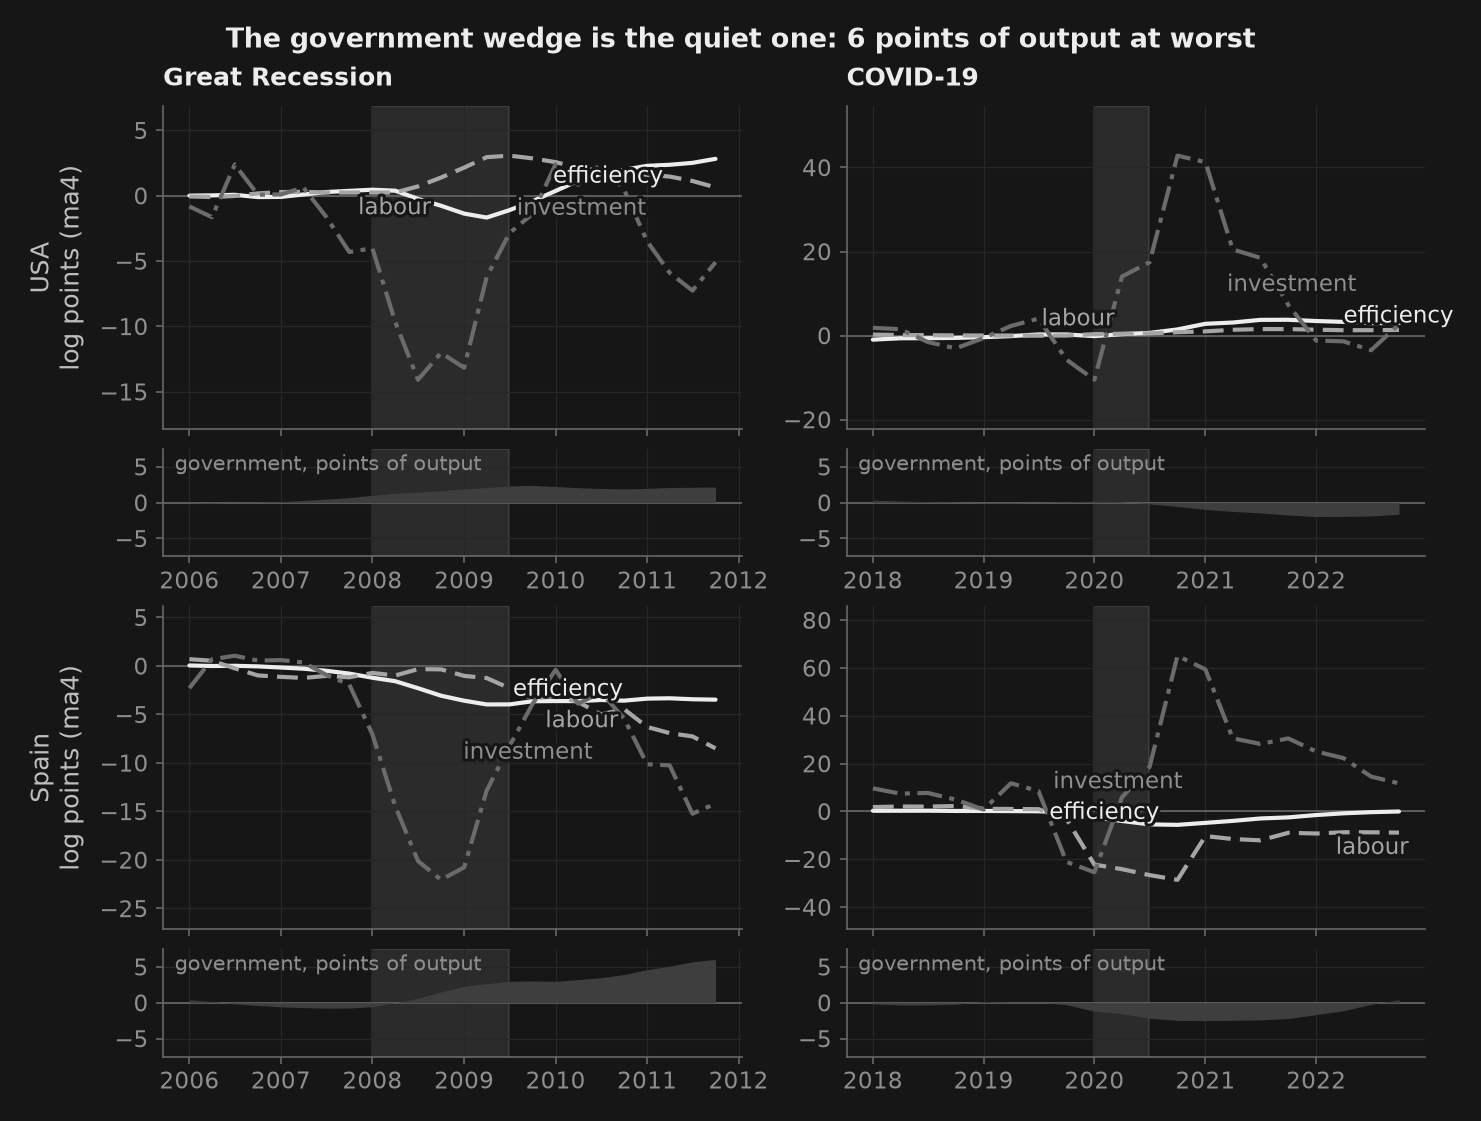

In [6]:
FIG_COUNTRIES = (("USA", "USA"), ("ESP", "Spain"))
EPISODES = (("Great Recession", "2006", "2011", "2006", "2008-01-01", "2009-06-30"),
            ("COVID-19", "2018", "2022", "2019", "2020-01-01", "2020-06-30"))
SERIES = (("A", "efficiency", _nbstyle.S1),
          ("L", "labour", _nbstyle.S2),
          ("X", "investment", _nbstyle.S3))

# Four blocks (country x episode), each with its government strip underneath: four rows
# at the height of a 2x2 figure, the strip a third of the panel it reads.  The episode
# titles the column and the country labels the row, so neither is repeated across four
# titles.  On a slide the slot is half as tall as the notebook, so the figure is drawn at
# that size from the start -- never shrunk afterwards, which is what throws the labels off
# -- and there the axis label, the years and the strip's ticks go in their short version.
LAM = _nbstyle.PERFIL == "lamina"
fig, AX = _nbstyle.figura(4, 2, figsize=plt.rcParams["figure.figsize"] if LAM else "2x2",
                          height_ratios=[3.0, 1.35, 3.0, 1.35] if LAM else [3.0, 1.0, 3.0, 1.0],
                          sharex="col")
for i, (code, name) in enumerate(FIG_COUNTRIES):
    x = CTRY[code]
    for j, (title, start, end, base, s0, s1) in enumerate(EPISODES):
        ax, axg = AX[2 * i, j], AX[2 * i + 1, j]
        w = x[["A", "L", "X"]].copy()
        w["G"] = 100.0 * (x.gn - x.gn.loc[base].mean()) / x.Yn.loc[base].mean()
        s = w.rolling(4, center=True, min_periods=2).mean()   # the Euler is nearly pure noise
        s = s.loc[start:end] - s.loc[base].mean()
        for a in (ax, axg):
            a.axvspan(pd.Timestamp(s0), pd.Timestamp(s1), color=_nbstyle.RECESION, zorder=0)
            a.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, zorder=2)
        for col, lbl, sty in SERIES:
            ax.plot(s.index, s[col], **sty, zorder=3, label=lbl)
        axg.fill_between(s.index, 0.0, s.G, color=_nbstyle.BARRA_COLORES[3], lw=0, zorder=3)
        axg.set_ylim(-7.5, 7.5); axg.set_yticks([-5, 5] if LAM else [-5, 0, 5])
        axg.xaxis.set_major_locator(mdates.YearLocator(2 if LAM else 1))
        if i == 0:
            ax.set_title(title)
        axg.tick_params(axis="x", labelbottom=True)
        axg.annotate("government, points of output", (0.02, 0.95), xycoords="axes fraction",
                     va="top", fontsize="small", color=_nbstyle.NOTA)
        if j == 0:
            ax.set_ylabel(f"{name}\nlog points" + ("" if LAM else " (ma4)"))
        ax.margins(y=0.22)                    # room above and below for the labels
        _nbstyle.etiquetar(ax, sep=1.4)
        print(f"  [info] {code} {title}: " + ", ".join(
            f"{c} [{s[c].min():+.1f}, {s[c].max():+.1f}]" for c in ("A", "L", "X", "G")))
_cr = CTRY["ESP"]
print("  [info] ESP COVID-19 UNSMOOTHED, 2019Q4→2020Q2: " + ", ".join(
    f"{c} {_cr[c].loc['2020-04-01'] - _cr[c].loc['2019-10-01']:+.1f}" for c in ("A", "L"))
      + "  — the figure goes with a four-quarter moving average; §2.1 has the raw table")
fig.suptitle("The government wedge is the quiet one: 6 points of output at worst")
plt.show()


## 2. The anatomy of a recession in wedges

Across 32 OECD economies, the Great Recession is ordered by **one** wedge. The cross-country correlation of the peak-to-trough fall in output with the fall in the efficiency wedge is $+0.89$, and it is the same smoothed or not; with the labour wedge, $+0.50$ (and $+0.42$ raw); with the investment wedge, $-0.04$. The efficiency wedge fell in 31 of 32 countries, the labour wedge in 19 and the investment wedge in 24 — but it fell *in disorder*, unrelated to the size of the recession, and its median, $-7.1$, is larger in absolute value than the efficiency one's, $-5.7$: it is not that it does not move, it is that it does not order. That is the split Chari, Kehoe and McGrattan (2007) obtain for 1929–33 and for 1982 in a single country, reproduced here in a cross section they did not have.

Five countries put a face on the split. The efficiency and labour figures use a three-quarter moving average, and the code prints the raw ones beside them. **Germany** lost 7.3 points with the three wedges in equal parts ($-3.8$, $-4.2$, $-4.4$). **Spain** lost 9.3 and its labour wedge fell 16.5 with the efficiency one nearly still ($-1.8$). **Latvia** lost 26.6 with both wedges sunk at once ($-26.5$ and $-27.6$). **The United States** lost 4.1 and its labour wedge **rose** 3.0. And **Greece** lost 33.1 —the largest fall in the panel— with $\Delta\log A = -33.9$ and a labour wedge that *rises* ($+1.1$ with a moving average, $+5.2$ without one). Five countries, five different diagnoses: that is what the accounting buys.

**A note on the data, because it is the reason this is a section and not a footnote.** The $+0.89$ is almost a tautology, and it is worth saying so before celebrating it. The panel's efficiency wedge is a raw Solow residual, $A = Y/(K^{\alpha}H^{1-\alpha})$, with no correction for utilisation or for labour quality. That turns the decomposition

$$ \Delta\log Y \;=\; \Delta\log A \;+\; \alpha\,\Delta\log K \;+\; (1-\alpha)\,\Delta\log H $$

into an **identity**, true to the last bit. Capital is a stock and kept growing through the recession in 30 of the 32 countries; hours fell less than output; and whatever is left is absorbed by $A$ by construction. The median country lost 101 % of its recession "through TFP". Capital utilisation, labour hoarding, measurement error and reallocation across firms: all of that lives inside that $A$, and none of the four is technology. It is *almost* a tautology — and exercise 3 asks you for the part that is not.

The split across the three terms, moreover, leans on $\alpha$, which here is one minus the compensation of employees **without adjusting for self-employment**: it runs from 0.44 to 0.67 (Greece). A country with a lot of self-employment gets an inflated $\alpha$, and with it an inflated capital term and a hypersensitive TFP. §5 turns that sensitivity into a number.

**The bridge to T01_A §5.** There labour productivity *rose* during the recession in several countries —Spain first among them— and we called it a composition effect. From the production function it is another identity: $\Delta\log(Y/H) = \Delta\log A + \alpha\,\Delta\log(K/H)$. With the periphery's true trough, $Y/H$ rose in 9 of 32 recessions and $\log A$ rose in **one**: Portugal, $+4.7$. The difference is capital deepening, median $+4.6$ points, and in Spain $+15.3 = -1.6 + 16.9$. The Spanish productivity boom is a capital stock that fires nobody when firms do. The Spanish efficiency wedge never rose.

Three more conventions, declared at once because each of them moves numbers. **Dating:** the only one in the notebook, own peak up to 2008Q4 and later trough inside 2007Q1–2013Q4; shortening the trough to 2011Q4 moves exactly six dates —ESP, GRC, HRV, ITA, PRT and SVN—, which are precisely the countries whose recession did not end in 2011, and exercise 2 measures what that does to the three correlations. **Smoothing:** the labour wedge's cross section is 0.42 raw and 0.50 with a three-quarter moving average; both are reported, always, and the efficiency one does not move. **The investment wedge is not measured at two dates:** it is realised consumption growth times a large gain, so by the trough it has already rebounded; the defensible statistic is its mean during the recession minus its mean over the four preceding quarters. For the same reason we draw no simplex of the three wedges here: in their own units the investment one would take half the triangle, and what we would be comparing is units, not mechanisms.

In [7]:
def change(code, pk, tr, ma=1):
    """Δ peak→trough of output and of the wedges, in log points.
    ma=k smooths A, L and X with a centred mean of 2k+1 quarters (ma=0: raw).
    X_rec: mean of the investment wedge during the recession minus its mean over the
    four quarters up to the peak — a flow is not measured at two dates."""
    d = CTRY[code]
    out = {"code": code, "peak": str(pk.to_period("Q")), "trough": str(tr.to_period("Q")),
           "qtrs": int(round((tr - pk).days / 91.31))}
    for v in ("y", "A", "L", "X", "k", "h", "hpe", "e", "cy"):
        s = d[v]
        if ma and v in ("A", "L", "X"):
            s = s.rolling(2 * ma + 1, center=True, min_periods=1).mean()
        out["d_" + v] = s.loc[tr] - s.loc[pk]
    i_pk, i_tr = d.index.get_loc(pk), d.index.get_loc(tr)
    pre, rec_ = d.iloc[max(i_pk - 3, 0):i_pk + 1], d.iloc[i_pk + 1:i_tr + 1]
    out["X_rec"] = rec_["X"].mean() - pre["X"].mean()
    out["X_nan"] = int(rec_["X"].isna().sum())
    out["alpha"] = d["alpha"].iloc[0]
    out["uh"] = int(d["uh"].iloc[0])
    return out


def episode(lo, hi, peak_by, min_fall=0.0, ma=1):
    """Every country whose peak-to-trough fall in the window reaches `min_fall`."""
    rows = []
    for c in CODES:
        s = CTRY[c]["y"].loc[lo:hi].dropna()
        pk, tr = peak_trough(CTRY[c]["y"], lo, hi, peak_by)
        if len(s) < 6 or tr == pk or (s[pk] - s[tr]) < min_fall:
            continue
        rows.append(change(c, pk, tr, ma=ma))
    return pd.DataFrame(rows).set_index("code")


GR = episode(*WINDOW, ma=1).sort_values("d_y")
GRc = episode(*WINDOW, ma=0).loc[GR.index]                       # unsmoothed
GR11 = episode(WINDOW[0], "2011-12-31", WINDOW[2], ma=0)         # short window

print(f"Wedge panel: {len(CODES)} economies, {_q.min()}–{_q.max()}, "
      f"{len(WEDGES) // len(CODES)} quarters each.")
print(f"With no hours of their own ({len(NO_HOURS)}, where H = 480·EMP by construction): "
      f"{', '.join(NO_HOURS)}\n")
print("The Great Recession peak to trough, window 2007Q1–2013Q4, in log points:\n")
# .round() on period columns warns in pandas 3; we format only the floats.
print(GR[["peak", "trough", "qtrs", "d_y", "d_A", "d_L", "X_rec"]]
      .to_string(float_format=lambda v: f"{v:.1f}"))

moved = [c for c in GR.index
         if c in GR11.index and GR11.loc[c, "trough"] != GR.loc[c, "trough"]]
print(f"\nn = {len(GR)} of {len(CODES)}: Poland's output does not fall inside the window.")
print(f"Shortening the trough to 2011Q4 moves exactly {len(moved)} dates: "
      + ", ".join(f"{c} {GR.loc[c, 'trough']}→{GR11.loc[c, 'trough']}" for c in moved))

for v, lbl in (("d_A", "efficiency  Δlog A  (ma3)"),
               ("d_L", "labour      Δlog(1−τ_ℓ)  (ma3)"),
               ("X_rec", "investment  −log(1+τ_x), recession − pre-peak")):
    print(f"  {lbl:44s} fell in {(GR[v] < 0).sum():2d} of {len(GR)}; "
          f"median {GR[v].median():+5.1f}; corr(Δy, ·) = {GR['d_y'].corr(GR[v]):+.2f}")
print(f"  {'labour      Δlog(1−τ_ℓ)  UNSMOOTHED':44s} fell in {(GRc.d_L < 0).sum():2d} of "
      f"{len(GRc)}; median {GRc.d_L.median():+5.1f}; corr(Δy, ·) = {GRc.d_y.corr(GRc.d_L):+.2f}")
print(f"  {'efficiency  Δlog A  UNSMOOTHED':44s}{'':21s}"
      f"corr(Δy, ·) = {GRc.d_y.corr(GRc.d_A):+.2f}   ← the order does not depend on smoothing")

print("\nFive countries, five diagnoses (ΔA and ΔL with ma3; in brackets, unsmoothed):")
for c in ("DEU", "ESP", "LVA", "USA", "GRC"):
    r, rc = GR.loc[c], GRc.loc[c]
    print(f"  {c} {r.peak}→{r.trough}: Δy {r.d_y:+5.1f} | ΔA {r.d_A:+5.1f} ({rc.d_A:+5.1f}) "
          f"ΔL {r.d_L:+5.1f} ({rc.d_L:+5.1f}) | X_rec {r.X_rec:+6.1f}")

assert len(GR) == 32 and (GR.d_A < 0).sum() == 31 and (GR.d_L < 0).sum() == 19
assert (GR.X_rec < 0).sum() == 24
assert abs(GR.d_y.corr(GR.d_A) - 0.89) < 0.01 and abs(GRc.d_y.corr(GRc.d_A) - 0.89) < 0.02
assert abs(GR.d_y.corr(GR.d_L) - 0.50) < 0.01 and abs(GRc.d_y.corr(GRc.d_L) - 0.42) < 0.01
assert abs(GR.d_y.corr(GR.X_rec) + 0.04) < 0.01
assert sorted(moved) == ["ESP", "GRC", "HRV", "ITA", "PRT", "SVN"]
assert GR.loc["GRC", "peak"] == "2007Q2" and GR.loc["GRC", "trough"] == "2013Q1"

Wedge panel: 33 economies, 2000Q1–2025Q2, 102 quarters each.
With no hours of their own (7, where H = 480·EMP by construction): AUS, CHE, GBR, JPN, KOR, NZL, USA

The Great Recession peak to trough, window 2007Q1–2013Q4, in log points:

        peak  trough  qtrs   d_y   d_A   d_L  X_rec
code                                               
GRC   2007Q2  2013Q1    23 -33.1 -33.9   1.1   -9.3
LVA   2007Q3  2010Q3    12 -26.6 -26.5 -27.6    2.5
EST   2007Q3  2009Q3     8 -22.4 -20.0 -28.3  -13.2
LTU   2008Q2  2009Q4     6 -18.2 -16.6 -20.0  -21.1
HRV   2008Q2  2012Q4    18 -12.6 -15.6   5.8    3.6
IRL   2007Q4  2009Q4     8 -12.3  -5.7 -19.1   -8.1
SVN   2008Q2  2012Q4    18 -12.0 -10.8   0.4  -14.4
ITA   2008Q1  2013Q2    21 -10.4  -7.7 -15.9    0.5
SVK   2008Q4  2009Q1     1 -10.2  -2.9  -0.5  -37.9
PRT   2007Q4  2012Q4    20 -10.2   5.8 -23.1  -69.8
FIN   2007Q4  2009Q2     6  -9.9 -10.0   0.1   -7.1
ESP   2008Q2  2013Q3    21  -9.3  -1.8 -16.5   -6.1
JPN   2008Q1  2009Q1     4  -9.3  -

In [8]:
# The decomposition that DOES add up (and therefore discovers nothing): production.
GR["id_A"] = GRc["d_A"]                       # unsmoothed: the identity is exact or it is not
GR["id_k"] = GR.alpha * GR.d_k
GR["id_h"] = (1 - GR.alpha) * GR.d_h
resid = (GR.id_A + GR.id_k + GR.id_h - GR.d_y).abs().max()
share = GR[["id_A", "id_k", "id_h"]].div(GR.d_y, axis=0).median()
print(f"Identity Δlog Y = Δlog A + α Δlog K + (1−α) Δlog H: "
      f"maximum residual {resid:.1e} log points.")
print("  Median country: TFP {:.0%} of the recession, hours {:.0%}, capital {:.0%}."
      .format(share.id_A, share.id_h, share.id_k))
print(f"  Capital ROSE during the recession in {(GR.d_k > 0).sum()} of {len(GR)} countries: "
      f"it is a stock and the median recession lasts {int(GR.qtrs.median())} quarters.")
print(f"  α runs from {GR.alpha.min():.2f} to {GR.alpha.max():.2f} "
      f"(the maximum is {GR.alpha.idxmax()}): the split inherits that measurement.")
assert resid < 1e-9

# The bridge to T01_A §5: there labour productivity ROSE in several recessions.
P = GRc.copy()
P["d_yh"] = P.d_y - P.d_h                     # Δlog(Y/H): T01_A's productivity margin
P["d_kh"] = P.alpha * (P.d_k - P.d_h)         # α Δlog(K/H): capital deepening
print(f"\nBridge to T01_A §5 (n = {len(P)}): Δlog(Y/H) = Δlog A + α Δlog(K/H).")
print(f"  Labour productivity ROSE in {(P.d_yh > 0).sum()} of {len(P)} recessions; "
      f"measured TFP, in {(P.d_A > 0).sum()} "
      f"({', '.join(f'{c} {P.d_A[c]:+.1f}' for c in P.index[P.d_A > 0])}).")
print(f"  The difference is α Δlog(K/H), median {P.d_kh.median():+.1f} points.")
for c in ("ESP", "IRL", "LVA", "DEU"):
    print(f"    {c}: Δlog(Y/H) {P.d_yh[c]:+5.1f} = ΔlogA {P.d_A[c]:+5.1f} "
          f"+ αΔlog(K/H) {P.d_kh[c]:+5.1f}")
print(f"  With the short window (trough ≤ 2011Q4) it rises in {(GR11.d_y - GR11.d_h > 0).sum()} "
      f"of {len(GR11)}: the trough date moves the count, not the sign.")
assert (P.d_yh > 0).sum() == 9 and (P.d_A > 0).sum() == 1
assert abs(P.d_A["PRT"] - 4.7) < 0.1 and abs(P.d_kh.median() - 4.6) < 0.1
assert abs(P.d_yh["ESP"] - 15.3) < 0.1 and abs(P.d_A["ESP"] + 1.6) < 0.1

Identity Δlog Y = Δlog A + α Δlog K + (1−α) Δlog H: maximum residual 8.6e-13 log points.
  Median country: TFP 101% of the recession, hours 30%, capital -30%.
  Capital ROSE during the recession in 30 of 32 countries: it is a stock and the median recession lasts 5 quarters.
  α runs from 0.44 to 0.67 (the maximum is GRC): the split inherits that measurement.

Bridge to T01_A §5 (n = 32): Δlog(Y/H) = Δlog A + α Δlog(K/H).
  Labour productivity ROSE in 9 of 32 recessions; measured TFP, in 1 (PRT +4.7).
  The difference is α Δlog(K/H), median +4.6 points.
    ESP: Δlog(Y/H) +15.3 = ΔlogA  -1.6 + αΔlog(K/H) +16.9
    IRL: Δlog(Y/H) +13.4 = ΔlogA  -7.4 + αΔlog(K/H) +20.8
    LVA: Δlog(Y/H)  +5.4 = ΔlogA -28.2 + αΔlog(K/H) +33.6
    DEU: Δlog(Y/H)  -4.5 = ΔlogA  -5.8 + αΔlog(K/H)  +1.3
  With the short window (trough ≤ 2011Q4) it rises in 7 of 32: the trough date moves the count, not the sign.


### 2.1 Three episodes, three signatures — and one of them is not economics

The same dating over three different windows gives three different splits, and that is where the value of the exercise lies: if the wedges always said the same thing, they would be measuring nothing. **2008–09** (n = 31) is an efficiency episode: median $-5.7$ against $-2.1$ for the labour wedge. **The sovereign crisis** (peak between 2010Q4 and 2011Q4, a fall of at least one point and two quarters; 11 countries come out, with the five GIIPS inside) reverses the order: median labour $-4.5$ against efficiency $-2.9$, and the labour wedge falls in 10 of the 11. Spain $-12.0$, Portugal $-12.7$, Italy $-10.2$. Greece is the exception and it is the interesting one: there the labour wedge *rises* 6.4 and the efficiency one falls 13.5. The natural hypothesis —"the sovereign crisis is an investment-wedge episode, because credit was cut off"— **does not survive**: the investment wedge falls in only 8 of 11 and what actually falls inside it is consumption. And a fragility has to be declared: unsmoothed, the order of the **medians** reverses ($A$ $-3.3$ against $L$ $-2.5$) and the labour wedge falls in 8 of 11 instead of 10; what does hold under any smoothing is that Spain, Portugal and Italy are labour-wedge recessions.

**COVID** (2019Q4→2020Q2; it is the only post-2019 block in this section, and it is here because the episode *is* the object) looks like the textbook case: median labour wedge $-24.3$ against $-5.0$ for efficiency. It is not. Splitting the sample by whether the country has hours of its own, the median is $-30.0$ in the 26 that do and $+0.3$ in the seven that do not. The labour wedge with $\nu = 2$ is $\log(C/Y) + 3\log(H/E)$, so in the seven countries where the panel imposes $H = 480\cdot E$ it **cannot** move through the labour market, and in the other 26 it moves almost entirely through hours per worker times three. Spain to the bit: $-79.0 = +5.2$ from $\log(C/Y)$ plus $-84.2$ from hours per worker times three, with a residual of $2\cdot10^{-13}$. That is the ERTE counted three times. The United States adjusted through employment ($-13.8$) and its labour wedge rose 1.3. The United Kingdom lost 25.0 points of output and 24.7 of $\log A$, because its hours do not exist and the whole fall went into the residual. A model that reads "labour wedge" in the Spanish COVID is reading hours; in the American one it is reading nothing. And the investment wedge does not even exist in 2020Q2 in 25 of the 33 countries: with that fall in consumption its numerator is negative.

In [9]:
EPIS = {
    "2008–09": episode("2007-01-01", "2011-12-31", "2008-12-31", min_fall=1.0, ma=1),
    "2011–13": episode("2010-10-01", "2014-12-31", "2011-12-31", min_fall=1.0, ma=1),
    "COVID": episode("2019-07-01", "2020-12-31", "2019-12-31", min_fall=1.0, ma=0),
}
EPIS["2011–13"] = EPIS["2011–13"][EPIS["2011–13"].qtrs >= 2]   # not continuations of 2009
SOV, COV = EPIS["2011–13"], EPIS["COVID"]
print("Three episodes, three signatures (medians, log points):\n")
for k, e in EPIS.items():
    print(f"  {k:8s} n = {len(e):2d} | Δy {e.d_y.median():+6.1f} | A {e.d_A.median():+6.1f} "
          f"L {e.d_L.median():+6.1f} X_rec {e.X_rec.median():+7.1f} | A fell in {(e.d_A < 0).sum()}, "
          f"L in {(e.d_L < 0).sum()}, X in {(e.X_rec < 0).sum()}; "
          f"X undefined in {(e.X_nan > 0).sum()}")
print(f"\n  2011–13, the {len(SOV)} countries: " + ", ".join(SOV.index))
print("  " + ", ".join(f"{c} L {SOV.d_L[c]:+.1f} / A {SOV.d_A[c]:+.1f}"
                       for c in ("ESP", "PRT", "ITA", "IRL", "GRC")))
SOVc = episode("2010-10-01", "2014-12-31", "2011-12-31", min_fall=1.0, ma=0).loc[SOV.index]
print(f"  Unsmoothed the order of the medians reverses: A {SOVc.d_A.median():+.1f} against "
      f"L {SOVc.d_L.median():+.1f}, and L falls in {(SOVc.d_L < 0).sum()} of {len(SOVc)}.")
print("  But the big three hold up unsmoothed: " + ", ".join(
    f"{c} L {SOVc.d_L[c]:+.1f} / A {SOVc.d_A[c]:+.1f}" for c in ("ESP", "PRT", "ITA"))
      + "; the ones that turn around are " + ", ".join(
    f"{c} L {SOVc.d_L[c]:+.1f} / A {SOVc.d_A[c]:+.1f}" for c in ("IRL", "GRC")) + ".")
assert all(SOVc.d_L[c] < SOVc.d_A[c] for c in ("ESP", "PRT", "ITA"))

ch2, sh2 = COV[COV.uh == 1], COV[COV.uh == 0]
print(f"\n  COVID 2019Q4→2020Q2, n = {len(COV)}: median ΔL {COV.d_L.median():+.1f}, but "
      f"{ch2.d_L.median():+.1f} in the {len(ch2)} countries with hours and {sh2.d_L.median():+.1f} "
      f"in the {len(sh2)} without them.")
for c in ("ESP", "USA", "GBR"):
    r = COV.loc[c]
    print(f"    {c}: Δy {r.d_y:+6.1f} | ΔA {r.d_A:+6.1f} ΔL {r.d_L:+6.1f} | "
          f"Δlog(H/E) {r.d_hpe:+6.1f} Δlog E {r.d_e:+6.1f}  own hours: "
          f"{'yes' if r.uh else 'no'}")
print(f"    Spain to the bit: ΔL {COV.d_L['ESP']:+.1f} = Δlog(C/Y) {COV.d_cy['ESP']:+.1f} "
      f"+ 3·Δlog(H/E) {3 * COV.d_hpe['ESP']:+.1f} (residual "
      f"{COV.d_L['ESP'] - COV.d_cy['ESP'] - 3 * COV.d_hpe['ESP']:.1e}).")
print(f"    The investment wedge does not even exist in 2020Q2 in {n_nan} of {len(CODES)} "
      f"countries: with that fall in consumption its numerator is negative.")
assert len(SOV) == 11 and (SOV.d_L < 0).sum() == 10
assert abs(SOV.d_L.median() + 4.5) < 0.1 and abs(SOV.d_A.median() + 2.9) < 0.1
assert SOVc.d_A.median() < SOVc.d_L.median()          # the order reverses unsmoothed
assert len(COV) == 33 and abs(ch2.d_L.median() + 30.0) < 0.2 and abs(sh2.d_L.median() - 0.3) < 0.2
assert abs(COV.d_L["ESP"] - COV.d_cy["ESP"] - 3 * COV.d_hpe["ESP"]) < 1e-9
assert (COV.X_nan > 0).sum() >= 25

Three episodes, three signatures (medians, log points):

  2008–09  n = 31 | Δy   -6.9 | A   -5.7 L   -2.1 X_rec    -7.1 | A fell in 30, L in 19, X in 25; X undefined in 1
  2011–13  n = 11 | Δy   -4.1 | A   -2.9 L   -4.5 X_rec   -12.3 | A fell in 10, L in 10, X in 8; X undefined in 0
  COVID    n = 33 | Δy  -10.3 | A   -5.0 L  -24.3 X_rec   -48.4 | A fell in 30, L in 28, X in 29; X undefined in 26

  2011–13, the 11 countries: CZE, ESP, FIN, GRC, HRV, HUN, IRL, ITA, NLD, PRT, SVN
  ESP L -12.0 / A -0.2, PRT L -12.7 / A +0.9, ITA L -10.2 / A -3.6, IRL L -4.4 / A -1.1, GRC L +6.4 / A -13.5


  Unsmoothed the order of the medians reverses: A -3.3 against L -2.5, and L falls in 8 of 11.
  But the big three hold up unsmoothed: ESP L -10.9 / A -0.4, PRT L -9.4 / A -0.2, ITA L -10.9 / A -3.8; the ones that turn around are IRL L +0.7 / A -3.3, GRC L +8.1 / A -15.0.

  COVID 2019Q4→2020Q2, n = 33: median ΔL -24.3, but -30.0 in the 26 countries with hours and +0.3 in the 7 without them.
    ESP: Δy  -24.9 | ΔA   -7.9 ΔL  -79.0 | Δlog(H/E)  -28.1 Δlog E   -8.5  own hours: yes
    USA: Δy   -9.5 | ΔA   -2.4 ΔL   +1.3 | Δlog(H/E)   +0.0 Δlog E  -13.8  own hours: no
    GBR: Δy  -25.0 | ΔA  -24.7 ΔL   -2.1 | Δlog(H/E)   +0.0 Δlog E   -1.3  own hours: no
    Spain to the bit: ΔL -79.0 = Δlog(C/Y) +5.2 + 3·Δlog(H/E) -84.2 (residual 1.7e-13).
    The investment wedge does not even exist in 2020Q2 in 25 of 33 countries: with that fall in consumption its numerator is negative.


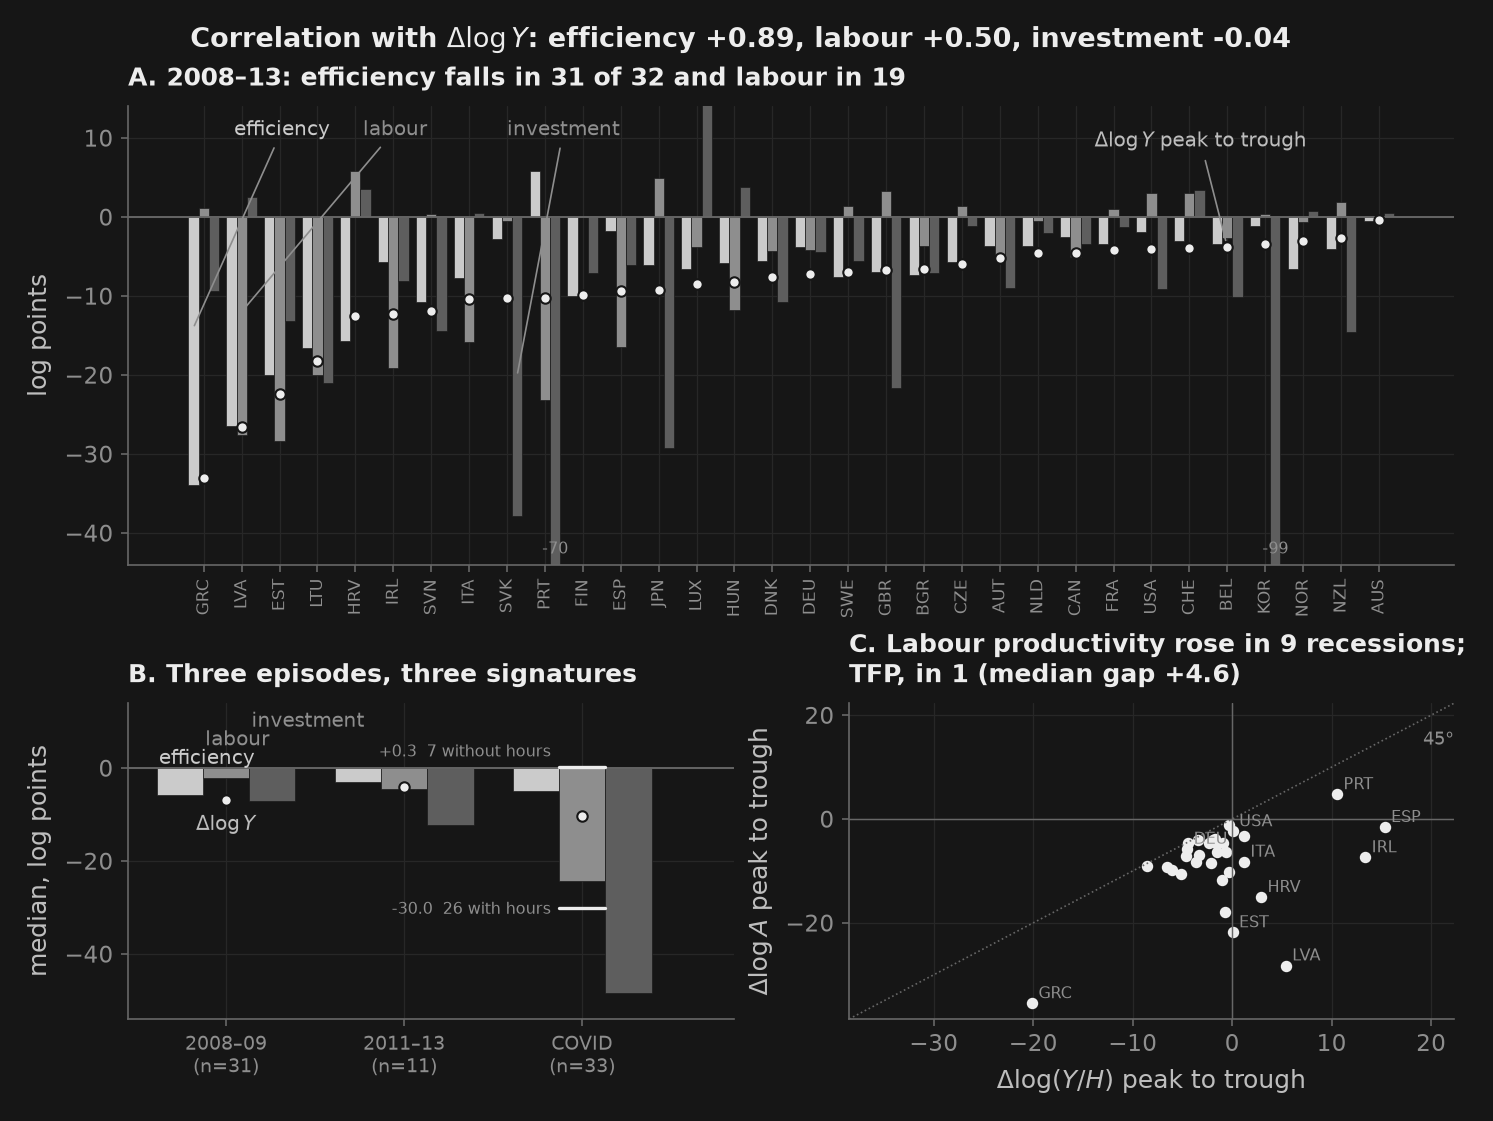

In [10]:
# Three panels with the top one full width: the grid does not come out of figura(), but the
# size and the constrained spacing are the course's.
fig = plt.figure(figsize=_nbstyle.TAMANO["2x2"], layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[1.45, 1.0])

axA = fig.add_subplot(gs[0, :])
x = np.arange(len(GR)); w = 0.27
# the third bar tone does not reach text contrast: its name goes in NOTA
FIG_WEDGES = (("d_A", "efficiency", _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_COLORES[0]),
              ("d_L", "labour", _nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_COLORES[1]),
              ("X_rec", "investment", _nbstyle.BARRA_COLORES[2], _nbstyle.NOTA))
for j, (v, lbl, col, ctxt) in enumerate(FIG_WEDGES):
    axA.bar(x + (j - 1) * w, GR[v], w, color=col, edgecolor=_nbstyle.FONDO, lw=0.3)
axA.plot(x, GR.d_y, "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=5, zorder=5)
axA.axhline(0, color=_nbstyle.SPINE, lw=0.9)
axA.set_xticks(x); axA.set_xticklabels(GR.index, rotation=90, fontsize=8.4)
axA.set_ylim(-44, 14)
axA.set_ylabel("log points")
axA.set_title("A. 2008–13: efficiency falls in {} of {} and labour in {}".format(
    (GR.d_A < 0).sum(), len(GR), (GR.d_L < 0).sum()))
for c in GR.index[GR.X_rec < -44]:
    i_c = int(np.where(GR.index == c)[0][0])
    axA.annotate(f"{GR.X_rec[c]:+.0f}", (i_c + w, -42.6), fontsize=7.6, ha="center",
                 color=_nbstyle.NOTA)
# Each wedge's name next to one of its own bars, with a leader: in a grid of 32 countries
# there is no room to repeat it group by group.
for (v, lbl, col, ctxt), xt, (i_c, dj, y_c) in zip(FIG_WEDGES, (0.8, 4.2, 8.0),
                                                   ((0, -1, -14.0), (1, 0, -12.0), (8, 1, -20.0))):
    axA.annotate(lbl, xy=(i_c + dj * w, y_c), xytext=(xt, 11.0), ha="left", va="center",
                 fontsize=9.5, color=ctxt,
                 arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                 shrinkA=2, shrinkB=1))
axA.annotate("$\\Delta\\log Y$ peak to trough", xy=(27, GR.d_y.iloc[27]), xytext=(23.5, 9.5),
             ha="left", va="center", fontsize=9.5, color=_nbstyle.TEXTO,
             arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=2, shrinkB=3))

axB = fig.add_subplot(gs[1, 0])
labs = [f"2008–09\n(n={len(EPIS['2008–09'])})", f"2011–13\n(n={len(SOV)})", f"COVID\n(n={len(COV)})"]
xb = np.arange(3); wb = 0.26
for j, (v, lbl, col, ctxt) in enumerate(FIG_WEDGES):
    axB.bar(xb + (j - 1) * wb, [e[v].median() for e in EPIS.values()], wb,
            color=col, edgecolor=_nbstyle.FONDO, lw=0.3)
axB.plot(xb, [e.d_y.median() for e in EPIS.values()], "o", color=_nbstyle.TINTA,
         mec=_nbstyle.FONDO, ms=5, zorder=5)
axB.axhline(0, color=_nbstyle.SPINE, lw=0.9)
for yv, txt, dy in ((ch2.d_L.median(), f"{len(ch2)} with hours", -3),
                    (sh2.d_L.median(), f"{len(sh2)} without hours", 5)):
    axB.plot([2 - wb / 2, 2 + wb / 2], [yv, yv], color=_nbstyle.TINTA, ls="-", lw=1.6, zorder=6)
    axB.annotate(f"{yv:+.1f}  {txt}", (2 - wb / 2, yv), xytext=(-4, dy),
                 textcoords="offset points", fontsize=7.6, color=_nbstyle.NOTA, ha="right")
axB.set_xticks(xb); axB.set_xticklabels(labs, fontsize=9)
axB.set_ylim(-54, 14); axB.set_xlim(-0.55, 2.85)
axB.set_ylabel("median, log points")
axB.set_title("B. Three episodes, three signatures")
# Each wedge above its own bar of the first episode, staggered so that they do not collide.
for (v, lbl, col, ctxt), j, yl in zip(FIG_WEDGES, (-1, 0, 1), (2.0, 6.0, 10.0)):
    axB.annotate(lbl, ((j - 0.45) * wb, yl), ha="left", va="center", fontsize=9.5, color=ctxt)
axB.annotate("$\\Delta\\log Y$", (0.0, EPIS["2008–09"].d_y.median()), xytext=(0, -7),
             textcoords="offset points", ha="center", va="top", fontsize=9.5,
             color=_nbstyle.TEXTO)

axC = fig.add_subplot(gs[1, 1])
axC.scatter(P.d_yh, P.d_A, s=20, color=_nbstyle.TINTA)
for c in ("ESP", "IRL", "PRT", "LVA", "EST", "GRC", "HRV", "ITA", "DEU", "USA"):
    axC.annotate(c, (P.d_yh[c], P.d_A[c]), fontsize=7.5, xytext=(3, 2.5),
                 textcoords="offset points", color=_nbstyle.NOTA)
lim = [min(P.d_yh.min(), P.d_A.min()) - 3, max(P.d_yh.max(), P.d_A.max()) + 7]
axC.plot(lim, lim, color=_nbstyle.SPINE, lw=0.8, ls=":")
axC.set_xlim(lim); axC.set_ylim(lim)
axC.axhline(0, color=_nbstyle.SPINE, lw=0.7); axC.axvline(0, color=_nbstyle.SPINE, lw=0.7)
axC.annotate("45°", (lim[1] - 4, lim[1] - 4), xytext=(4, -10), textcoords="offset points",
             fontsize=8.5, color=_nbstyle.NOTA)
axC.set_xlabel("$\\Delta\\log(Y/H)$ peak to trough")
axC.set_ylabel("$\\Delta\\log A$ peak to trough")
axC.set_title("C. Labour productivity rose in {} recessions;\nTFP, in {} (median gap "
              "{:+.1f})".format(
                  (P.d_yh > 0).sum(), (P.d_A > 0).sum(), P.d_kh.median()))

fig.suptitle("Correlation with $\\Delta\\log Y$: efficiency {:+.2f}, labour {:+.2f}, "
             "investment {:+.2f}".format(
                 GR.d_y.corr(GR.d_A), GR.d_y.corr(GR.d_L), GR.d_y.corr(GR.X_rec)))
plt.show()


## 3. The labour wedge does not see employment

Germany lost 7.3 log points of output between 2008Q1 and 2009Q1 with employment **up** 0.6, and its labour wedge moved $-2.6$. Spain lost 18.2 points of employment and its wedge, $-18.9$, contains not one of them: it is hours per worker. Greece lost 33.1 points of output —the largest fall in the panel— and its wedge **rose** 5.2. The United States' also rises, $+3.0$, with employment falling 4.1.

None of those four numbers is an empirical finding. All four come out of an identity that is derived in three lines. The static wedge is the ratio of the marginal product of labour to the leisure–consumption marginal rate of substitution, with the panel's preferences ($\sigma=1$, $\nu=2$, $h$ = hours per worker over 1152, $c=C/E$):

$$\tau_{\text{stat}}=\frac{1}{1-\tau_\ell}=\frac{(1-\alpha)\,Y/H}{\psi\,h^{\nu}c^{\sigma}}.$$

Substitute $Y=AK^{\alpha}H^{1-\alpha}$ and collect terms: $\log\tau_{\text{stat}}=\log A+\alpha\log K-(\alpha+\nu)\log H+(\nu+\sigma)\log E-\sigma\log C+\text{const}$. Employment appears twice —it raises output, and it lowers hours and consumption *per person*— and with $\sigma=1$ the two cancel exactly. Undoing the production function leaves

$$\log(1-\tau_\ell)=\log\frac{C}{Y}+(1+\nu)\log\frac{H}{E}+\text{const},\qquad \nu=2\ \Rightarrow\ \text{the }3.$$

Germany is the identity in two numbers: hours per worker contributed $3\times(-3.4)=-10.2$ and smoothed consumption contributed $+7.6$; the *Kurzarbeit* that T01_A §5 read as hours, the wedge almost cancels. Spain is the identity with the other split: $-19.4$ from hours per worker and $+0.5$ from $C/Y$, and its 18.2 points of destroyed employment are nowhere in the formula.

**A note on the data, because here the data decide the answer.** The panel measures $h=H/E$, hours per *worker*, whereas Chari, Kehoe and McGrattan measure hours per person of working age. It is the difference between "Spain had no labour wedge" and "Spain is the largest labour wedge in the OECD", and §3.1 quantifies it. To that we add what §1 already verified: in the seven countries with no hours the labour wedge is **literally** $\log(C/Y)$, and with the `HOUR` column of the file itself the American one goes from $+3.0$ to $-4.7$. That the country CKM wrote the canonical result about is one of the seven is no lucky accident.

Everything in this section is differences between two dates of an episode —own peak and trough, or 2019Q4→2020Q2—, not second moments: that is why T01_A §1.1's 2019Q4 cut does not apply, and why 2020 can enter.

In [11]:
def _err_const(x, y):
    """Maximum |x − y| within each country, removing its own constant."""
    r = pd.DataFrame({"code": WEDGES["code"], "r": x - y})
    return float(r.groupby("code")["r"].apply(lambda s: (s - s.mean()).abs().max()).max())


lY, lH, lE, lC, lK = (np.log(WEDGES[k]) for k in ("Y", "H", "EMP", "C", "K"))
e_def = (lY - lH) - NU * (lH - lE) - SIGMA * (lC - lE)                 # log MPL − log MRS
e_prd = (WEDGES["logA"] + WEDGES["alpha_c"] * lK - (WEDGES["alpha_c"] + NU) * lH
         + (NU + SIGMA) * lE - SIGMA * lC)
err_def, err_prd = _err_const(e_def, WEDGES["logS"]), _err_const(e_prd, WEDGES["logS"])
err = _err_const(WEDGES["wedgeL"] / 100.0,
                 (1 + NU) * np.log(WEDGES["H"] / WEDGES["EMP"]) + np.log(WEDGES["C"] / WEDGES["Y"]))
print(f"log τ_stat = log(MPL) − log(MRS): residual within country {err_def:.1e}")
print(f"…with Y = A·K^α·H^(1−α): log A + α log K − (α+ν) log H + (ν+σ) log E − σ log C, "
      f"residual {err_prd:.1e}")
print("…and since log A + α log K = log Y − (1−α) log H, the two collapse into")
print(f"  log(1−τ_ℓ) = log(C/Y) + (1+ν)·log(H/E) + const,  ν = {NU:.0f}: maximum residual "
      f"{err:.1e} in {len(WEDGES):,} observations. Employment does not appear.")
assert max(err_def, err_prd) < 1e-11 and err < 1e-11

rows = []
for c in CODES:
    pk, tr = REC[c]
    r = {"code": c, "peak": str(pk.to_period("Q")), "trough": str(tr.to_period("Q"))}
    for col in ("y", "e", "hpe", "cy", "L"):
        r["d_" + col] = dcol(c, col, pk, tr)
    rows.append(r)
rec = pd.DataFrame(rows).set_index("code")
assert (rec["d_L"] - ((1 + NU) * rec["d_hpe"] + rec["d_cy"])).abs().max() < 1e-9
FELL = list(rec.index[rec["d_y"] < -0.5])
print(f"\nGreat Recession, own peak and trough: {len(FELL)} of {len(rec)} fell more than "
      f"half a log point (out: {', '.join(sorted(set(rec.index) - set(FELL)))}).\n")
print(rec.loc[FELL, ["peak", "trough", "d_y", "d_e", "d_hpe", "d_cy", "d_L"]]
      .rename(columns={"d_y": "ΔlogY", "d_e": "ΔlogE", "d_hpe": "Δlog(H/E)",
                       "d_cy": "Δlog(C/Y)", "d_L": "Δlog(1−τ_l)"})
      .sort_values("Δlog(1−τ_l)").to_string(float_format=lambda v: f"{v:.1f}"))

print("\nFour cases, term by term (log points, peak→trough):")
for c in ("DEU", "ESP", "GRC", "USA"):
    r = rec.loc[c]
    print(f"  {c} {r['peak']}→{r['trough']}: ΔlogY {r['d_y']:+6.1f} | employment {r['d_e']:+6.1f} | "
          f"3·Δlog(H/E) {3 * r['d_hpe']:+6.1f} + Δlog(C/Y) {r['d_cy']:+5.1f} = "
          f"wedge {r['d_L']:+6.1f}")
corr_E = float(np.corrcoef(rec.loc[FELL, "d_e"], rec.loc[FELL, "d_L"])[0, 1])
with_h = [c for c in FELL if c not in NO_HOURS]
corr_he = float(np.corrcoef(rec.loc[with_h, "d_hpe"], rec.loc[with_h, "d_L"])[0, 1])
print(f"\nIn the cross section corr(wedge, ΔlogE) = {corr_E:+.2f} (n = {len(FELL)}); "
      f"corr(wedge, Δlog(H/E)) = {corr_he:+.2f} (n = {len(with_h)}).")
print("The identity says which of the two is mechanical: the second. The first is manufactured\n"
      "by the Baltics and Ireland, which cut both margins at once.")
print(f"The {len(NO_HOURS)} countries with no hours: the wedge is Δlog(C/Y) and it rose in "
      f"{sum(rec.loc[c, 'd_L'] > 0 for c in NO_HOURS)} of {len(NO_HOURS)} — "
      + ", ".join(f"{c} {rec.loc[c, 'd_L']:+.1f}" for c in NO_HOURS) + ".")
assert abs(rec.loc["DEU", "d_L"] + 2.6) < 0.3 and abs(rec.loc["ESP", "d_L"] + 18.9) < 0.3
assert rec.loc["GRC", "d_L"] > 0 and rec.loc["USA", "d_L"] > 0
assert sum(rec.loc[c, "d_L"] > 0 for c in NO_HOURS) == 7

log τ_stat = log(MPL) − log(MRS): residual within country 1.8e-14
…with Y = A·K^α·H^(1−α): log A + α log K − (α+ν) log H + (ν+σ) log E − σ log C, residual 1.8e-14
…and since log A + α log K = log Y − (1−α) log H, the two collapse into
  log(1−τ_ℓ) = log(C/Y) + (1+ν)·log(H/E) + const,  ν = 2: maximum residual 1.8e-14 in 3,366 observations. Employment does not appear.

Great Recession, own peak and trough: 31 of 33 fell more than half a log point (out: AUS, POL).

        peak  trough  ΔlogY  ΔlogE  Δlog(H/E)  Δlog(C/Y)  Δlog(1−τ_l)
code                                                                 
IRL   2007Q4  2009Q4  -12.3  -12.4      -13.3        8.9        -31.0
LVA   2007Q3  2010Q3  -26.6  -22.6       -9.5        3.9        -24.6
EST   2007Q3  2009Q3  -22.4  -12.1      -10.4        7.9        -23.2
PRT   2007Q4  2012Q4  -10.2  -12.6       -8.2        2.5        -22.0
LTU   2008Q2  2009Q4  -18.2  -12.0       -5.5       -2.7        -19.3
ESP   2008Q2  2013Q3   -9.3  -18.2       -6

### 3.1 The same recession, measured per labour-force member: Spain goes from $-19$ to $-77$

The CKM wedge is built per person of working age, not per worker. The panel carries no population, but there is a harmonised unemployment rate: `oecd_urate_q.csv` gives quarterly $u$ and $LF=E/(1-u)$ is an approximation to the reference population —the **labour force**, not the adult population, and that is the warning that has to be said out loud—. Changing the denominator adds a single term, because $\log(H/LF)=\log(H/E)+\log(1-u)$:

$$\Delta\log(1-\tau_\ell)^{LF}=\Delta\log(1-\tau_\ell)+(1+\nu)\,\Delta\log(1-u).$$

The 3 multiplying unemployment is the same $(1+\nu)$ as before: it is a calibration choice, not a datum. With $\nu=1$ instead of 2, Spain lands at $-57.5$ (or at $-51.0$ if the hours-per-worker part is recomputed too), not at $-76.8$. What does not depend on $\nu$ is the **order** —Spain and Greece at the top, Germany at the bottom— nor the Greek sign flip.

In [12]:
u = pd.read_csv(DATOS / "oecd_urate_q.csv", parse_dates=["date"])
UNEMP = {c: g.set_index("date")["urate"].sort_index()
         for c, g in u.groupby("code") if c in CODES}
rec["d_1u"] = np.nan
for c in UNEMP:
    pk, tr = REC[c]
    if pk in UNEMP[c].index and tr in UNEMP[c].index:
        rec.loc[c, "d_1u"] = 100 * float(np.log(1 - UNEMP[c].loc[tr] / 100)
                                         - np.log(1 - UNEMP[c].loc[pk] / 100))
rec["d_L_LF"] = rec["d_L"] + (1 + NU) * rec["d_1u"]                # ν = 2, the panel's
rec["d_L_nu1"] = rec["d_L"] + 2.0 * rec["d_1u"]                    # only the correction, ν = 1
rec["d_L_nu1c"] = rec["d_cy"] + 2.0 * (rec["d_hpe"] + rec["d_1u"])  # the whole wedge, with ν = 1
lf = rec.loc[[c for c in FELL if np.isfinite(rec.loc[c, "d_L_LF"])]]
print(f"Wedge per LF member, LF = E/(1−u): n = {len(lf)}; oecd_urate_q.csv does not carry "
      f"{', '.join(sorted(set(CODES) - set(UNEMP)))}.\n")
print(lf[["d_e", "d_L", "d_1u", "d_L_LF"]]
      .rename(columns={"d_e": "ΔlogE", "d_L": "per worker", "d_1u": "Δlog(1−u)",
                       "d_L_LF": "per LF member"})
      .sort_values("per LF member").to_string(float_format=lambda v: f"{v:.1f}"))
corr_LF = float(np.corrcoef(lf["d_e"], lf["d_L_LF"])[0, 1])
print(f"\nMedian |wedge|: per worker {rec['d_L'].abs().median():.1f} log points, per LF member "
      f"{lf['d_L_LF'].abs().median():.1f} log points. corr with ΔlogE: "
      f"{float(np.corrcoef(lf['d_e'], lf['d_L'])[0, 1]):+.2f} per worker, "
      f"{corr_LF:+.2f} per LF member.")
for c in ("ESP", "GRC", "USA", "DEU"):
    print(f"  {c}: {rec.loc[c, 'd_L']:+6.1f} → {rec.loc[c, 'd_L_LF']:+6.1f} "
          f"(u {UNEMP[c].loc[REC[c][0]]:.1f}% → {UNEMP[c].loc[REC[c][1]]:.1f}%, correction "
          f"{(1 + NU) * rec.loc[c, 'd_1u']:+.1f}; with ν = 1: {rec.loc[c, 'd_L_nu1']:+.1f}, "
          f"or {rec.loc[c, 'd_L_nu1c']:+.1f} recomputing hours per worker too)")
assert abs(rec.loc["ESP", "d_L_LF"] + 76.8) < 0.5 and abs(rec.loc["GRC", "d_L_LF"] + 64.2) < 0.5
assert abs(corr_LF - 0.95) < 0.02

Wedge per LF member, LF = E/(1−u): n = 26; oecd_urate_q.csv does not carry BGR, HRV, LTU, LVA.

      ΔlogE  per worker  Δlog(1−u)  per LF member
code                                             
ESP   -18.2       -18.9      -19.3          -76.8
GRC   -11.7         5.2      -23.1          -64.2
IRL   -12.4       -31.0       -9.6          -59.7
EST   -12.1       -23.2      -11.1          -56.6
PRT   -12.6       -22.0       -9.9          -51.7
ITA    -4.4       -16.9       -6.4          -36.1
HUN    -2.6       -10.7       -3.0          -19.6
SVN    -7.3         1.4       -5.6          -15.3
DNK    -1.8        -5.3       -3.1          -14.7
CAN    -1.9        -6.3       -2.6          -14.0
USA    -4.1         3.0       -4.3           -9.8
BEL     0.2        -3.3       -1.3           -7.3
FIN    -1.4        -0.3       -2.2           -6.9
AUT    -0.5        -2.5       -1.3           -6.3
SVK    -1.1        -1.1       -1.6           -5.9
GBR    -2.0         2.9       -2.8           -5.4
SWE 

### 3.2 A counterfactual that does not require solving the model

The intratemporal condition is **static**: given $A$, $K$, $C$ and $E$, the wedge is proportional to $H^{-(\alpha+\nu)}$ —that is the coefficient that appeared when the production function was substituted in—. So the hours that would have been worked with $\tau_\ell$ at its 2000–06 mean can be solved out without knowing $\psi$ and without solving anything:

$$\log\frac{H^{*}}{H}=\frac{\log S-\overline{\log S}_{2000\text{–}06}}{\alpha+\nu}.$$

The result is a contrast, not an average: in 2008–13 the labour wedge owes the median **28%** of the lost hours; in 2020Q2, **86%** (91% among the 26 countries that do measure hours). 2020 was a hours-per-worker recession —ERTE, *Kurzarbeit*, *chômage partiel*—, and the prototype reads it whole; 2008–13 was a jobs recession, and the prototype does not see it.

It is *almost* algebra: the counterfactual equals $[3\Delta\log(H/E)+\Delta\log(C/Y)]/(\alpha+2)$, so giving hours back is giving hours per worker back by definition. The part that is **not** a tautology is $\Delta\log(C/Y)$, and it is the one that makes Germany a small case and flips Greece's sign. And it is partial equilibrium: it holds $C$ and $K$ at their observed values, when in equilibrium $C$ would rise and with it the marginal rate of substitution. §4 does the general-equilibrium version, feeding the prototype one wedge at a time.

In [13]:
COVID = (pd.Timestamp("2019-10-01"), pd.Timestamp("2020-04-01"))
CF = {}
for c in CODES:                        # log(H*/H), country by country
    g = CTRY[c]
    CF[c] = 100 * (g["logS"] - g.loc["2000-01-01":"2006-12-31", "logS"].mean()) / (g["alpha"] + NU)
rows = []
for c in CODES:
    pk, tr = REC[c]
    rows.append({"code": c, "dlH_GR": dcol(c, "h", pk, tr),
                 "owes_GR": -float(CF[c].loc[tr] - CF[c].loc[pk]),
                 "dlH_CV": dcol(c, "h", *COVID),
                 "owes_CV": -float(CF[c].loc[COVID[1]] - CF[c].loc[COVID[0]]),
                 "alpha": float(CTRY[c]["alpha"].iloc[0])})
cf = pd.DataFrame(rows).set_index("code")
cf["sh_GR"], cf["sh_CV"] = cf["owes_GR"] / cf["dlH_GR"], cf["owes_CV"] / cf["dlH_CV"]
assert (cf["owes_GR"] - rec["d_L"] / (cf["alpha"] + NU)).abs().max() < 1e-9   # it is ΔL/(α+ν)

cfc, cfh = cf.loc[FELL], cf.drop(index=NO_HOURS)
m_gr, m_cv = float(cfc["sh_GR"].median()), float(cf["sh_CV"].median())
print(f"2008–13 (n = {len(cfc)}): the wedge owes the median {m_gr:.0%} of the lost hours "
      f"(aggregate {-cfc['owes_GR'].sum() / -cfc['dlH_GR'].sum():.0%}; "
      f"{cfc.drop(index=[c for c in NO_HOURS if c in cfc.index])['sh_GR'].median():.0%} "
      f"among those that measure hours)")
print(f"2019Q4→2020Q2 (n = {len(cf)}): {m_cv:.0%} "
      f"(aggregate {-cf['owes_CV'].sum() / -cf['dlH_CV'].sum():.0%}; "
      f"{cfh['sh_CV'].median():.0%} among the {len(cfh)} with hours)\n")
for c in ("DEU", "ESP", "GRC", "USA"):
    print(f"  {c}: 2008–13 hours {cf.loc[c, 'dlH_GR']:+6.1f}, the wedge owes "
          f"{cf.loc[c, 'owes_GR']:+6.1f} ({cf.loc[c, 'sh_GR']:5.0%}) | 2020Q2 hours "
          f"{cf.loc[c, 'dlH_CV']:+6.1f}, owes {cf.loc[c, 'owes_CV']:+6.1f} "
          f"({cf.loc[c, 'sh_CV']:5.0%})")
a_med = float(cf["alpha"].median())
print(f"\nAlmost algebra: owes = [3Δlog(H/E) + Δlog(C/Y)]/(α+2) ≈ {3 / (a_med + 2):.1f}·Δlog(H/E) + "
      f"{1 / (a_med + 2):.1f}·Δlog(C/Y) with the median α {a_med:.2f}; what is not a tautology "
      f"is Δlog(C/Y):\n  its median among the {len(cfc)} contributes "
      f"{rec.loc[FELL, 'd_cy'].median():+.1f} log points against "
      f"{3 * rec.loc[FELL, 'd_hpe'].median():+.1f} from hours per worker, and in Greece "
      f"{rec.loc['GRC', 'd_cy']:+.1f} against {3 * rec.loc['GRC', 'd_hpe']:+.1f} — "
      f"it is consumption, not hours, that gives it a positive sign.")
assert abs(m_gr - 0.28) < 0.03 and abs(m_cv - 0.86) < 0.03

2008–13 (n = 31): the wedge owes the median 28% of the lost hours (aggregate 23%; 29% among those that measure hours)
2019Q4→2020Q2 (n = 33): 86% (aggregate 83%; 91% among the 26 with hours)

  DEU: 2008–13 hours   -2.8, the wedge owes   -1.1 (  38%) | 2020Q2 hours   -9.7, owes   -9.8 ( 101%)
  ESP: 2008–13 hours  -24.7, the wedge owes   -7.5 (  30%) | 2020Q2 hours  -36.6, owes  -31.3 (  85%)
  GRC: 2008–13 hours  -13.0, the wedge owes   +2.0 ( -15%) | 2020Q2 hours  -34.4, owes  -32.0 (  93%)
  USA: 2008–13 hours   -4.1, the wedge owes   +1.2 ( -30%) | 2020Q2 hours  -13.8, owes   +0.5 (  -4%)

Almost algebra: owes = [3Δlog(H/E) + Δlog(C/Y)]/(α+2) ≈ 1.2·Δlog(H/E) + 0.4·Δlog(C/Y) with the median α 0.52; what is not a tautology is Δlog(C/Y):
  its median among the 31 contributes +5.1 log points against -9.0 from hours per worker, and in Greece +9.0 against -3.8 — it is consumption, not hours, that gives it a positive sign.


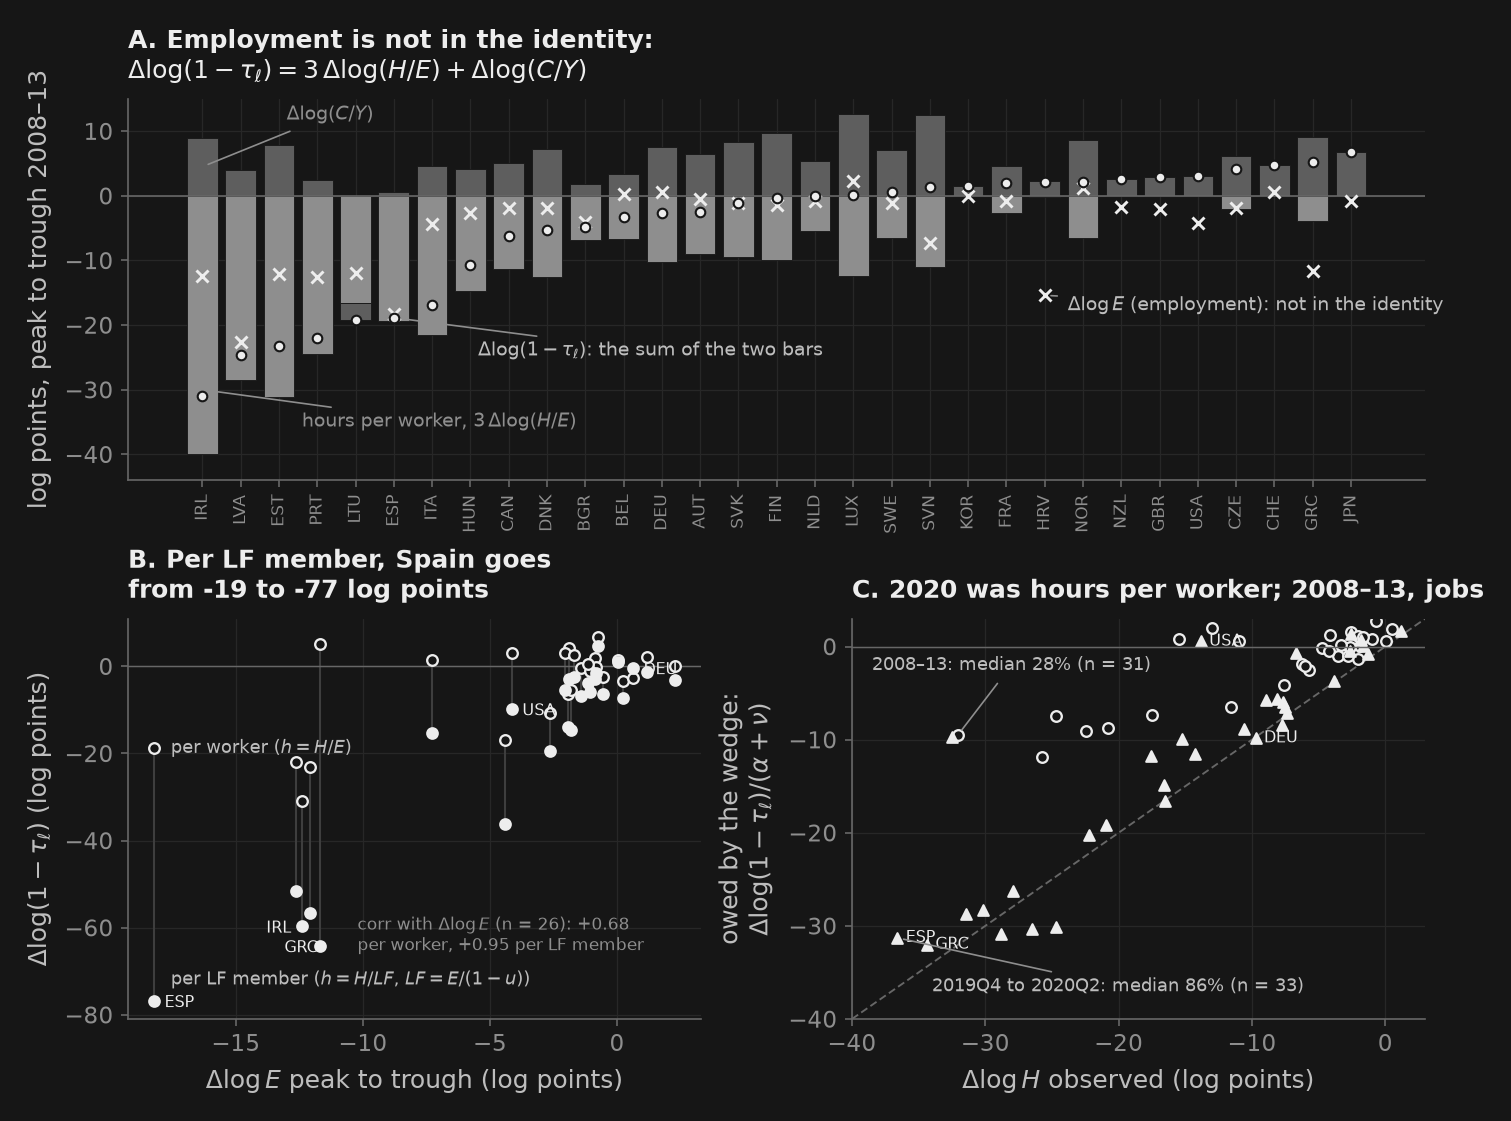

In [14]:
# One wide panel on top and two below: the grid does not come out of figura(), the size does.
fig = plt.figure(figsize=_nbstyle.TAMANO["2x2"], layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.05])

ax = fig.add_subplot(gs[0, :])
r = rec.loc[FELL].sort_values("d_L")
x = np.arange(len(r))
bp = np.zeros(len(r)); bn = np.zeros(len(r))
for k, mult, col in (("d_hpe", 3.0, _nbstyle.BARRA_COLORES[1]),
                     ("d_cy", 1.0, _nbstyle.BARRA_COLORES[2])):
    v = mult * r[k].to_numpy()
    base = np.where(v >= 0, bp, bn)
    ax.bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    bp = bp + np.where(v >= 0, v, 0.0); bn = bn + np.where(v < 0, v, 0.0)
ax.plot(x, r["d_L"], "o", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, ms=4.6, zorder=5)
ax.plot(x, r["d_e"], "x", color=_nbstyle.TINTA, ms=6, mew=1.4, zorder=4)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(r.index, rotation=90, fontsize=8)
ax.set_ylim(-44, 15); ax.set_ylabel("log points, peak to trough 2008–13")
ax.set_title("A. Employment is not in the identity:\n"
             "$\\Delta\\log(1-\\tau_\\ell)=3\\,\\Delta\\log(H/E)+\\Delta\\log(C/Y)$")
# Each piece next to one of its own bars or markers, with a leader.
_i_esp = int(np.where(r.index == "ESP")[0][0]); _i_hrv = int(np.where(r.index == "HRV")[0][0])
LEADERS = (("hours per worker, $3\\,\\Delta\\log(H/E)$", _nbstyle.BARRA_COLORES[1],
            (2.6, -35.0), (0.0, -30.0)),
           ("$\\Delta\\log(C/Y)$", _nbstyle.NOTA, (2.2, 12.5), (0.0, 4.5)),
           ("$\\Delta\\log(1-\\tau_\\ell)$: the sum of the two bars", _nbstyle.TEXTO,
            (float(_i_esp) + 2.2, -24.0), (float(_i_esp), float(r["d_L"].iloc[_i_esp]))),
           ("$\\Delta\\log E$ (employment): not in the identity", _nbstyle.TEXTO,
            (float(_i_hrv) + 0.6, -17.0), (float(_i_hrv), float(r["d_e"].iloc[_i_hrv]))))
for txt, col, xy_txt, xy_pt in LEADERS:
    ax.annotate(txt, xy=xy_pt, xytext=xy_txt, ha="left", va="center", fontsize=9,
                color=col, arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                           shrinkA=3, shrinkB=3))

ax = fig.add_subplot(gs[1, 0])
for c in lf.index:
    ax.plot([lf.loc[c, "d_e"]] * 2, [lf.loc[c, "d_L"], lf.loc[c, "d_L_LF"]],
            color=_nbstyle.gris("0.72"), ls="-", lw=1.0, zorder=1)
ax.scatter(lf["d_e"], lf["d_L"], s=26, facecolors=_nbstyle.FONDO,
           edgecolors=_nbstyle.TINTA, lw=1.1, zorder=3)
ax.scatter(lf["d_e"], lf["d_L_LF"], s=26, color=_nbstyle.TINTA, zorder=3)
for c in ("ESP", "GRC", "USA", "DEU", "IRL"):
    ax.annotate(c, (lf.loc[c, "d_e"], lf.loc[c, "d_L_LF"]), fontsize=7.6,
                textcoords="offset points",
                xytext=(5, -3) if c in ("ESP", "USA", "DEU") else (-17, -3))
ax.annotate("per worker ($h=H/E$)", (lf.loc["ESP", "d_e"], lf.loc["ESP", "d_L"]),
            xytext=(8, 0), textcoords="offset points", fontsize=8.6, va="center",
            color=_nbstyle.TEXTO)
ax.annotate("per LF member ($h=H/LF$, $LF=E/(1-u)$)",
            (lf.loc["ESP", "d_e"], lf.loc["ESP", "d_L_LF"]), xytext=(8, 10),
            textcoords="offset points", fontsize=8.6, va="center", color=_nbstyle.TEXTO)
ax.annotate(f"corr with $\\Delta\\log E$ (n = {len(lf)}): "
            f"{float(np.corrcoef(lf['d_e'], lf['d_L'])[0, 1]):+.2f}\nper worker, "
            f"{corr_LF:+.2f} per LF member", (0.40, 0.26), xycoords="axes fraction",
            fontsize=8.2, color=_nbstyle.NOTA, va="top")
ax.axhline(0, color=_nbstyle.SPINE, lw=0.7)
ax.set_xlabel("$\\Delta\\log E$ peak to trough (log points)")
ax.set_ylabel("$\\Delta\\log(1-\\tau_\\ell)$ (log points)")
ax.set_title(f"B. Per LF member, Spain goes\nfrom {rec.loc['ESP', 'd_L']:+.0f} to "
             f"{rec.loc['ESP', 'd_L_LF']:+.0f} log points")

ax = fig.add_subplot(gs[1, 1])
lim = [-40, 3]
ax.plot(lim, lim, color=_nbstyle.SPINE, lw=0.9, ls=(0, (4, 2)), zorder=1)
ax.scatter(cfc["dlH_GR"], cfc["owes_GR"], s=26, facecolors=_nbstyle.FONDO,
           edgecolors=_nbstyle.TINTA, lw=1.1)
ax.scatter(cf["dlH_CV"], cf["owes_CV"], s=26, color=_nbstyle.TINTA, marker="^")
for c in ("ESP", "GRC", "USA", "DEU"):
    ax.annotate(c, (cf.loc[c, "dlH_CV"], cf.loc[c, "owes_CV"]), fontsize=7.6,
                xytext=(4, -2), textcoords="offset points")
_c0 = cfc["dlH_GR"].idxmin()
ax.annotate(f"2008–13: median {m_gr:.0%} (n = {len(cfc)})",
            (cfc.loc[_c0, "dlH_GR"], cfc.loc[_c0, "owes_GR"]),
            xytext=(-38.5, -2.0), ha="left", va="center", fontsize=8.6, color=_nbstyle.TEXTO,
            arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=3, shrinkB=3))
ax.annotate(f"2019Q4 to 2020Q2: median {m_cv:.0%} (n = {len(cf)})",
            (cf.loc["ESP", "dlH_CV"], cf.loc["ESP", "owes_CV"]), xytext=(-34.0, -36.5),
            ha="left", va="center", fontsize=8.6, color=_nbstyle.TEXTO,
            arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8, shrinkA=3, shrinkB=3))
ax.axhline(0, color=_nbstyle.SPINE, lw=0.7); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("$\\Delta\\log H$ observed (log points)")
ax.set_ylabel("owed by the wedge:\n$\\Delta\\log(1-\\tau_\\ell)/(\\alpha+\\nu)$")
ax.set_title("C. 2020 was hours per worker; 2008–13, jobs")
plt.show()


## 4. One wedge at a time

**Germany lost its Great Recession through the efficiency wedge and Spain through the labour wedge, and in none of the three countries did the investment wedge move output.** With the prototype solved and fed **one** measured wedge at a time —the other three at their balanced-growth value— the efficiency wedge reproduces 98 % of the German gap and $-0.1$ % of the Spanish one; the labour wedge, 119 % of the Spanish and 0 % of the German. The United States is the only one that splits, and its split depends on one column: 68 / 38 with the hours the panel imputes to it ($H=480\cdot E$), **44 / 61** with the `HOUR` series the panel carries and does not use. The investment wedge stays between $-13.5$ % and $+1.1$ % in the three countries, and the German case is the one worth memorising: that wedge **falls 5.7 log points** read at two dates —**4.4** with the recession average against the average of the four preceding quarters, the statistic §2 declared defensible for a flow— and on its own produces **1.1 %** of the recession. A wedge that moves is not an economy that moves.

The prototype is the deck's, with the four wedges entering one per equation: efficiency $A_t$ in the production function, labour $1-\tau_{\ell,t}$ in the intratemporal condition, investment $1+\tau_{x,t}$ in the Euler equation, and government $g_t=y_t-c_t-x_t$ —a level, not a share— in the resource constraint. The unknowns are the paths of $k_{t+1}$ and $h_t$ over 2000Q1–2019Q4; $k_1$ and $k_{T+1}$ come from the panel's capital stock; the system of $2T$ equations is solved by Newton with a Jacobian of bandwidth 6. There is no Dynare and no linearisation: it is the non-linear model with perfect foresight.

**And it is not the only way to run it.** Lesson 04b solves this same experiment log-linearised, with `puremacro.dsge.klein_solve` and over six countries, closing expectations with a VAR(1) for the wedges. It is worth keeping both routes in view, because each one gives something the other cannot. There the solution is linear, so the decomposition across wedges is additive by superposition **exactly**, and the shares add up to the joint simulation by construction; here they do not, and §4.3 measures what losing that convenience costs. Here the run with the four wedges together returns the data to the bit and can therefore serve as a unit test; there it cannot, because the linear approximation leaves a residual. And on how expectations are closed the advantage is 04b's, not this notebook's: that is what comes next.

### A note on the data, because it decides the whole split

**First: the unit test is the lesson.** With the four wedges together, the prototype returns the data with an error of $4\cdot10^{-15}$ in output in the USA, and of $1\cdot10^{-13}$ in the worst of this cell's six runs. That is *not* evidence in favour of the neoclassical model: it is the definition of the wedges, and it is exactly the deck's warning. All it proves is that the equations programmed here are the ones the panel measured the wedges with — and that proof is needed, because the solver starts from the path **without** wedges and returns to the data in four or five Newton iterations.

**Second: the panel normalises by workers, and that decision splits the recession.** The panel defines $l_t=(H_t/E_t)/1152$, so employment is a **fifth** exogenous input of the prototype, and §3 already said why: the labour wedge does not see employment. Here we pay for it. With the panel's convention Spanish employment on its own reproduces 102 % of its recession and the labour wedge 17 %. With the extensive margin put where Chari–Kehoe–McGrattan put it —$l_t$ measured over a trend population, so that employment enters *inside* the labour wedge— the Spanish wedge goes to 119 % and the American one from $-11$ % to 38 %. Both are reported; the figures use CKM's. And it has to be said what that "trend population" is, because it fixes the denominator of every share: it is the log-linear extrapolation of 2000–06 employment, and in Spain that is **3.47 % a year** — the construction boom, not a demography. Robustness check (e) in §4.2 replaces it with 1 % a year: the Spanish gap goes from $-21.4$ to $-13.1$ points and the labour share from 118.5 % to 130.3 %. **The split holds; the size of the gap does not.**

**Third: measurement and simulation share an assumption, and that is why the fit is exact.** CKM treat the wedge vector as a VAR(1) and take $E_t$ under it, and **lesson 04b does exactly that** —it estimates that VAR(1) by least squares on the measured, smoothed wedges and solves the prototype under it—; here there is perfect foresight. Bluntly: on this point 04b is closer to CKM than this notebook is, and the shortcut has to be defended, not hidden. It is defensible for a concrete reason and not out of convenience: the panel's `tau_dyn` is measured with **realised** consumption $C_{t+1}/C_t$ and imposing $\tau_{x,t+1}=\tau_{x,t}$, that is, it is already measured under perfect foresight. Only the investment wedge lives inside the expectation, so only it would change. By how much: the internally consistent $\tau_x$ sequence —backward recursion on the Euler equation with its two dates— has a standard deviation of 2.3 log points in the USA against 6.6 for the panel's, and correlates $+0.21$ with it. The shortcut is not innocuous. What saves the experiment is that the investment wedge does not move output even with the inflated volatility. And the VAR is not free either: the matrix $P$ is one more specification choice —what enters, how many lags, over which window and with what smoothing— that leaks into the split. Both routes put an assumption where the data do not reach; what is not allowed is failing to say which.

**Fourth: this panel's government wedge is the external balance**, as §1 measured. The panel's `C` is **total** final consumption minus durables —public consumption is inside, and its size is precisely §1's second median, close to 20 % of GDP—, so $g_t=y_t-c_t-x_t$ ends up being net exports plus inventories: corr$(\Delta g,\Delta XN)\ge 0.99$ in the three countries. Government purchases are not in the government wedge; they are inside the consumption with which the labour and investment wedges are measured. A "government wedge only" experiment is feeding the prototype the external sector, not fiscal policy.

In [15]:
SIM0, SIM1 = "2000-01-01", "2019-10-01"      # simulation window (2020 is not a cycle)
EPI0, EPI1 = "2006-01-01", "2013-10-01"      # episode window, the figure's
N0 = 28                                      # 2000Q1–2006Q4: the panel's balanced path
WNAME = {"A": "efficiency", "S": "labour", "Dt": "investment", "G": "government", "N": "employment"}
THREE = ("USA", "ESP", "DEU")
NB = {"USA": "USA", "ESP": "Spain", "DEU": "Germany"}


def country_bca(code):
    """Data and calibration: alpha, beta and psi come from the panel, nothing is invented."""
    u = WEDGES[WEDGES["code"] == code].sort_values("date").set_index("date")
    al, be, ps = (float(u[c].iloc[0]) for c in ("alpha_c", "beta_c", "psi_c"))
    w = u.loc[SIM0:SIM1]
    d = dict(code=code, al=al, be=be, psi=ps, T=len(w), dates=w.index,
             Y=w["Y"].to_numpy(), C=w["C"].to_numpy(), I=w["I"].to_numpy(),
             K=w["K"].to_numpy(), H=w["H"].to_numpy(), N=w["EMP"].to_numpy(),
             S=w["tau_stat"].to_numpy(), NX=w["nx"].to_numpy(),
             # K of 2020Q1 = (1−delta)K_2019Q4 + I_2019Q4 in the panel (an exact identity):
             # it is the terminal condition and puts NO 2020 data into the simulation.
             Kterm=float(u["K"].to_numpy()[u.index.get_loc(w.index[-1]) + 1]))
    d["G"] = d["Y"] - d["C"] - d["I"]                  # government wedge: a level
    d["l"] = (d["H"] / d["N"]) / 1152.0
    d["A"] = d["Y"] / (d["K"] ** al * d["H"] ** (1 - al))
    Dt = np.full(d["T"], np.nan)                       # 1/(1+tau_x) unnormalised
    Dt[1:] = ((1 / be) * (d["C"][1:] / d["C"][:-1]) - (1 - DELTA)) / (al * d["Y"][1:] / d["K"][1:])
    d["Dt"] = Dt
    return d


def _trend(y, n0, T):
    t = np.arange(T, dtype=float)
    return np.exp(np.polyval(np.polyfit(t[:n0], np.log(y[:n0]), 1), t))


def bgp(d, n0=N0):
    """Balanced-growth value of each exogenous input, calibrated on 2000–2006."""
    T = d["T"]
    return {"A": _trend(d["A"], n0, T), "N": _trend(d["N"], n0, T),
            "G": np.mean(d["G"][:n0] / d["Y"][:n0]) * _trend(d["Y"], n0, T),
            "S": np.full(T, np.mean(d["S"][:n0])), "Dt": np.full(T, np.mean(d["Dt"][1:n0]))}


def residuals(x, ex):
    """The prototype's three conditions, stacked. x = (log k_{t+1}, log l_t)."""
    T, al = ex["T"], ex["al"]
    logl = x[1::2]
    K = np.empty(T + 1); K[0] = ex["K0"]; K[1:] = np.exp(x[0::2])
    Hs = 1152.0 * ex["N"] * np.exp(logl)
    Y = ex["A"] * K[:T] ** al * Hs ** (1 - al)                      # production
    C = Y - (K[1:] - (1 - DELTA) * K[:T]) - ex["G"]                 # resources: c + x + g = y
    r = np.empty(2 * T)
    r[0::2] = (np.log(ex["psi"]) + (1 + NU) * logl + SIGMA * np.log(C)
               + np.log(ex["S"]) - np.log((1 - al) * Y))            # intratemporal
    r[1:2 * T - 1:2] = np.log(C[1:] / C[:-1]) - np.log(
        ex["be"] * (ex["Dt"][1:] * al * Y[1:] / K[1:T] + (1 - DELTA)))   # Euler
    r[2 * T - 1] = x[2 * (T - 1)] - np.log(ex["Kterm"])             # terminal condition
    return r


def solve(ex, x0, tol=1e-11, itmax=60, h=1e-6, per=9):
    """Damped Newton. The Jacobian has bandwidth 6, so 9 evaluations are enough."""
    x = x0.copy(); r = residuals(x, ex); n = x.size
    for it in range(itmax):
        nr = np.max(np.abs(r))
        if nr < tol:
            return x, nr, it
        J = np.zeros((n, n))
        for c in range(per):                                   # column colouring
            idx = np.arange(c, n, per)
            xp = x.copy(); xp[idx] += h
            dr = (residuals(xp, ex) - r) / h
            for j in idx:
                J[max(0, j - 3):j + 4, j] = dr[max(0, j - 3):j + 4]
        dx = np.linalg.solve(J, -r); s = 1.0
        for _ in range(40):
            with np.errstate(invalid="ignore", divide="ignore"):
                rt = residuals(x + s * dx, ex)
            if np.all(np.isfinite(rt)) and np.max(np.abs(rt)) < nr:
                break
            s *= 0.5
        else:
            raise RuntimeError(f"Newton with no descent, |r| = {nr:.2e}")
        x, r = x + s * dx, rt
    return x, np.max(np.abs(r)), itmax


def convention(d, b, ckm, n0=N0):
    """PANEL: l = hours per worker, and employment is a fifth exogenous input.
    CKM:   l = hours over a trend population, and the extensive margin enters
           inside the labour wedge, which is where CKM put it."""
    dd, bb = dict(d), dict(b)
    if not ckm:
        return dd, bb, ["A", "S", "Dt", "G", "N"]
    l2 = d["H"] / (1152.0 * b["N"])
    Sr = (1 - d["al"]) * d["Y"] / (l2 ** (1 + NU) * d["C"] ** SIGMA)
    dd["l"], dd["psi"], dd["S"] = l2, float(np.mean(Sr[:n0])), Sr / np.mean(Sr[:n0])
    dd["N"] = bb["N"] = b["N"].copy()
    bb["S"] = np.full(d["T"], float(np.mean(dd["S"][:n0])))
    return dd, bb, ["A", "S", "Dt", "G"]


def run_(dd, bb, keys_, active, x0=None, Kmult=1.0):
    """Feed the prototype the MEASURED series of `active`; the rest, at their BGP."""
    ex = dict(T=dd["T"], al=dd["al"], be=dd["be"], psi=dd["psi"],
              K0=dd["K"][0], Kterm=dd["Kterm"] * Kmult)
    for k in ("A", "S", "Dt", "G", "N"):
        ex[k] = np.array((dd if (k not in keys_ or k in active) else bb)[k], float)
    ex["Dt"][0] = 1.0                                    # enters no equation
    if x0 is None:
        x0 = np.empty(2 * dd["T"])
        x0[0::2] = np.log(np.r_[dd["K"][1:], dd["Kterm"]]); x0[1::2] = np.log(dd["l"])
    x, nr, it = solve(ex, x0)
    K = np.empty(ex["T"] + 1); K[0] = ex["K0"]; K[1:] = np.exp(x[0::2])
    Hs = 1152.0 * ex["N"] * np.exp(x[1::2])
    return dict(Y=ex["A"] * K[:ex["T"]] ** ex["al"] * Hs ** (1 - ex["al"]),
                H=Hs, res=nr, it=it, x=x)


for c in THREE:
    _d = country_bca(c); _b = bgp(_d)
    print(f"{c}: alpha {_d['al']:.3f}, beta {_d['be']:.4f}, "
          f"K/Y {np.mean(_d['K'] / _d['Y']) / 4:.1f} years | 2000–06 path: "
          f"g_A {400 * np.log(_b['A'][1] / _b['A'][0]):+.2f} %/yr, "
          f"g_EMP {400 * np.log(_b['N'][1] / _b['N'][0]):+.2f} %/yr | government wedge = "
          f"{100 * np.mean(_d['G'] / _d['Y']):+.1f} % of GDP against XN "
          f"{100 * np.mean(_d['NX'] / _d['Y']):+.1f} %, corr of their changes "
          f"{np.corrcoef(np.diff(_d['G']), np.diff(_d['NX']))[0, 1]:.2f}")

USA: alpha 0.444, beta 0.9703, K/Y 2.5 years | 2000–06 path: g_A +1.15 %/yr, g_EMP +0.80 %/yr | government wedge = -2.9 % of GDP against XN -3.0 %, corr of their changes 0.99
ESP: alpha 0.524, beta 0.9670, K/Y 3.0 years | 2000–06 path: g_A -0.62 %/yr, g_EMP +3.47 %/yr | government wedge = +0.0 % of GDP against XN -0.4 %, corr of their changes 0.99
DEU: alpha 0.485, beta 0.9901, K/Y 4.4 years | 2000–06 path: g_A +1.63 %/yr, g_EMP -0.22 %/yr | government wedge = +6.0 % of GDP against XN +5.9 %, corr of their changes 1.00


In [16]:
# The unit test: the four wedges together MUST return the data.
PACK, UNIT = {}, {}
for c in THREE:
    d = country_bca(c); b = bgp(d); f = d["dates"]
    i0, i1 = (int(f.get_indexer([pd.Timestamp(x)])[0]) for x in (EPI0, EPI1))
    ip, it = (int(f.get_indexer([t])[0]) for t in REC[c])     # the notebook's single dating
    PACK[c] = (d, b, (i0, i1, ip, it))
    for ckm in (False, True):
        dd, bb, cl = convention(d, b, ckm)
        nowedge = run_(dd, bb, cl, set())                  # no wedge: the balanced path
        allw = run_(dd, bb, cl, set(cl), x0=nowedge["x"])  # all of them, starting from there
        e = np.max(np.abs(np.log(allw["Y"] / dd["Y"])))
        UNIT[(c, ckm)] = (dd, bb, cl, nowedge, allw, e)
        print(f"{c} [{'CKM  ' if ckm else 'panel'}] the {len(cl)} wedges together, Newton from "
              f"the path with no wedges: {allw['it']} iterations, max|log(Y_sim/Y_data)| = {e:.1e}, "
              f"hours {np.max(np.abs(np.log(allw['H'] / dd['H']))):.1e}")
        assert e < 1e-8, f"{c}: the prototype does not reproduce the data ({e:.2e})"
_emax = max(v[5] for v in UNIT.values())
print(f"Maximum over the six runs: {_emax:.0e}; the best is the USA with the four wedges, "
      f"{UNIT[('USA', True)][5]:.0e}.")
assert _emax < 1e-11, _emax
print("\nThe measured wedges reproduce the data at the level of rounding error. That is not")
print("evidence for anything: it is their definition. The content is in the split, not the fit.")

USA [panel] the 5 wedges together, Newton from the path with no wedges: 4 iterations, max|log(Y_sim/Y_data)| = 3.1e-15, hours 3.2e-15
USA [CKM  ] the 4 wedges together, Newton from the path with no wedges: 4 iterations, max|log(Y_sim/Y_data)| = 3.9e-15, hours 3.3e-15
ESP [panel] the 5 wedges together, Newton from the path with no wedges: 4 iterations, max|log(Y_sim/Y_data)| = 2.0e-14, hours 1.3e-14
ESP [CKM  ] the 4 wedges together, Newton from the path with no wedges: 5 iterations, max|log(Y_sim/Y_data)| = 5.3e-15, hours 4.1e-15
DEU [panel] the 5 wedges together, Newton from the path with no wedges: 4 iterations, max|log(Y_sim/Y_data)| = 1.2e-13, hours 1.2e-13
DEU [CKM  ] the 4 wedges together, Newton from the path with no wedges: 4 iterations, max|log(Y_sim/Y_data)| = 3.0e-14, hours 2.4e-14
Maximum over the six runs: 1e-13; the best is the USA with the four wedges, 4e-15.

The measured wedges reproduce the data at the level of rounding error. That is not
evidence for anything: it is 

### 4.1 The split

The statistic is the peak-to-trough fall in output **against the path with no wedges**, not against the level at the peak: the prototype fed only its trends keeps growing, and the honest comparison is against that path. The dates are the notebook's single dating, and they are the same for every run.

In [17]:
SHARE, PATH, XREC = {}, {}, {}
for c in THREE:
    d, b, (i0, i1, ip, it) = PACK[c]
    dY = 100 * np.log(d["Y"][it] / d["Y"][ip])
    print(f"\n{c}: peak {d['dates'][ip].to_period('Q')}, "
          f"trough {d['dates'][it].to_period('Q')}, "
          f"observed fall {dY:+.2f} log points")
    for ckm in (False, True):
        dd, bb, cl, nowedge, allw, _ = UNIT[(c, ckm)]
        d0 = 100 * np.log(nowedge["Y"][it] / nowedge["Y"][ip])
        for k in cl:
            r = run_(dd, bb, cl, {k}, x0=nowedge["x"])
            SHARE[(c, ckm, k)] = 100 * (100 * np.log(r["Y"][it] / r["Y"][ip]) - d0) / (dY - d0)
            PATH[(c, ckm, k)] = 100 * np.log(r["Y"] / nowedge["Y"])
        PATH[(c, ckm, "data")] = 100 * np.log(d["Y"] / nowedge["Y"])
        sm = sum(SHARE[(c, ckm, k)] for k in cl)
        print(f"   [{'CKM  ' if ckm else 'panel'}] gap against the path with no wedges "
              f"{dY - d0:+6.2f} pts | " + "  ".join(
                  f"{WNAME[k]} {SHARE[(c, ckm, k)]:+6.1f}%" for k in cl)
              + f" | sum {sm:+.1f}%; additivity error {sm - 100:+.1f} percentage "
                f"points = {(sm - 100) / 100 * (dY - d0):+.2f} log pts of the "
                f"{abs(dY - d0):.1f} of the gap")
    dd, bb, cl = UNIT[(c, True)][:3]
    mov = {"A": 100 * np.log(dd["A"] / bb["A"]), "S": -100 * np.log(dd["S"] / bb["S"]),
           "Dt": 100 * np.log(dd["Dt"] / bb["Dt"]),
           "G": 100 * (dd["G"] - bb["G"]) / _trend(d["Y"], N0, d["T"])}
    XREC[c] = (np.nanmean(mov["Dt"][ip + 1:it + 1])
               - np.nanmean(mov["Dt"][max(ip - 3, 0):ip + 1]))
    print("   the MEASURED wedge moves (course orientation, falling = holding back): " + ", ".join(
        f"{WNAME[k]} {mov[k][it] - mov[k][ip]:+.1f}" for k in cl) + " points, peak to trough;\n"
        f"   the investment one with the statistic §2 declared defensible for a flow "
        f"(recession average minus the average of the four preceding quarters): {XREC[c]:+.1f}")

# It is the SAME series as in §2 up to a constant, so the statistic has to coincide:
assert all(abs(XREC[c] - GR.loc[c, "X_rec"]) < 0.05 for c in THREE), XREC
assert abs(XREC["DEU"] + 4.4) < 0.1 and abs(XREC["USA"] + 9.1) < 0.1

for c, k, lo, hi in (("USA", "A", 60, 76), ("USA", "S", 30, 45), ("ESP", "S", 105, 130),
                     ("ESP", "A", -10, 10), ("DEU", "A", 90, 105)):
    assert lo < SHARE[(c, True, k)] < hi, (c, k, SHARE[(c, True, k)])
for c in THREE:
    assert abs(SHARE[(c, True, "Dt")]) < 20, (c, SHARE[(c, True, "Dt")])
    assert 95 < sum(SHARE[(c, True, k)] for k in ("A", "S", "Dt", "G")) < 105


USA: peak 2008Q2, trough 2009Q2, observed fall -4.06 log points
   [panel] gap against the path with no wedges  -6.82 pts | efficiency  +68.1%  labour  -10.6%  investment   -5.1%  government   -0.5%  employment  +48.3% | sum +100.2%; additivity error +0.2 percentage points = -0.01 log pts of the 6.8 of the gap
   [CKM  ] gap against the path with no wedges  -6.82 pts | efficiency  +68.1%  labour  +37.7%  investment   -5.1%  government   -0.5% | sum +100.2%; additivity error +0.2 percentage points = -0.01 log pts of the 6.8 of the gap
   the MEASURED wedge moves (course orientation, falling = holding back): efficiency -3.6, labour -11.8, investment -4.6, government +1.0 points, peak to trough;
   the investment one with the statistic §2 declared defensible for a flow (recession average minus the average of the four preceding quarters): -9.1

ESP: peak 2008Q2, trough 2013Q3, observed fall -9.34 log points
   [panel] gap against the path with no wedges -21.40 pts | efficiency   -0.1%  la

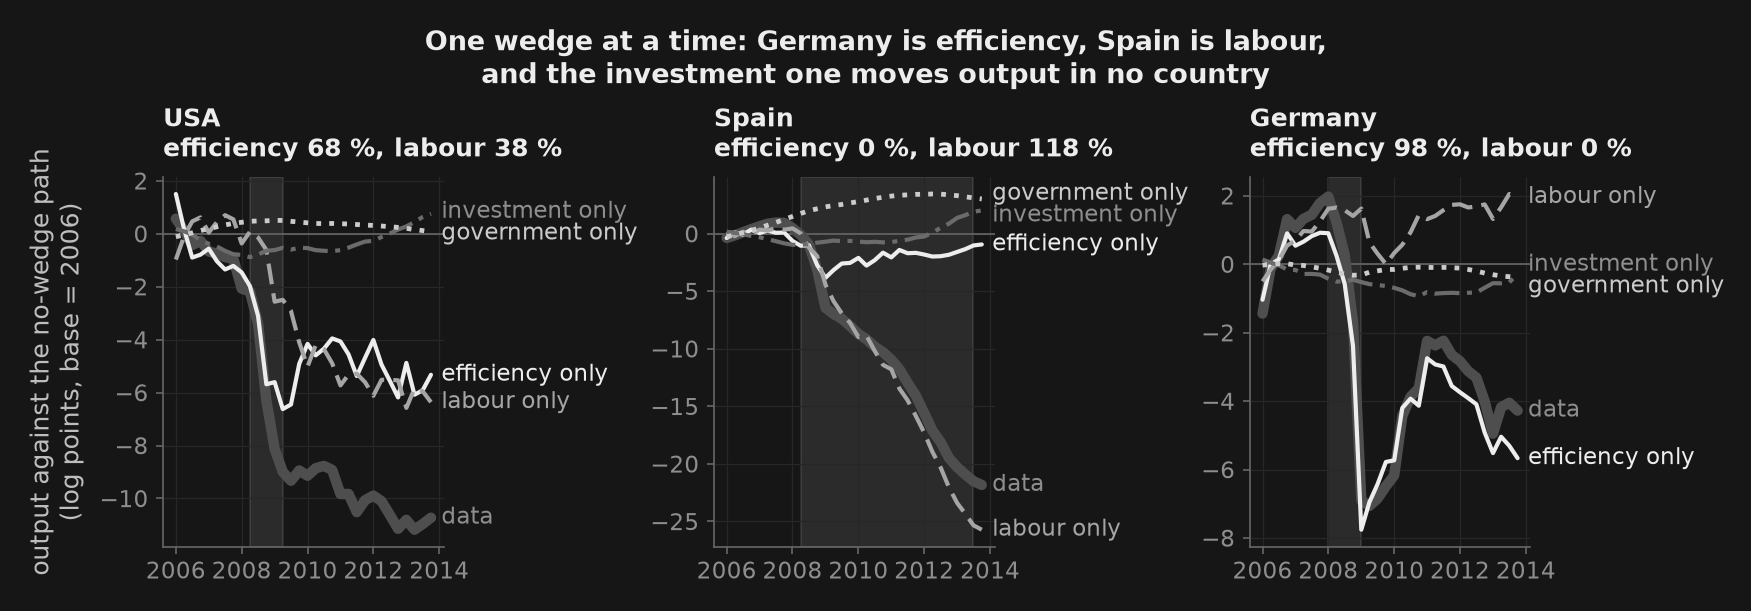

In [18]:
def _pct(x):
    return f"{0.0 if abs(x) < 0.5 else x:.0f}"      # avoids the ugly "−0 %"


LBLS = [("data", "data", dict(color=_nbstyle.tono(0.3), linestyle="-", linewidth=5.0)),
        ("A", "efficiency only", _nbstyle.S1), ("S", "labour only", _nbstyle.S2),
        ("Dt", "investment only", _nbstyle.S3), ("G", "government only", _nbstyle.S4)]
fig, axes = _nbstyle.figura(1, 3)
for ax, c in zip(axes, THREE):
    d, b, (i0, i1, ip, it) = PACK[c]
    f = d["dates"][i0:i1 + 1]
    ax.axvspan(d["dates"][ip], d["dates"][it], color=_nbstyle.RECESION, zorder=0)
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, zorder=1)
    for k, lab, sty in LBLS:
        s = PATH[(c, True, k)]
        ax.plot(f, s[i0:i1 + 1] - s[i0:i0 + 4].mean(), **sty, label=lab, zorder=3)
    ax.set_title(f"{NB[c]}\nefficiency {_pct(SHARE[(c, True, 'A')])} %, "
                 f"labour {_pct(SHARE[(c, True, 'S')])} %")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("output against the no-wedge path\n(log points, base = 2006)")
# fuera=True in the first two panels as well: inside the axes the name is written
# to the left of its line's end and lands on the neighbours, which converge here;
# outside, each one sits next to the end of ITS own line.
for ax in axes:
    _nbstyle.etiquetar(ax, donde="fin", fuera=True)
fig.suptitle("One wedge at a time: Germany is efficiency, Spain is labour,\nand the investment "
             "one moves output in no country")
plt.show()


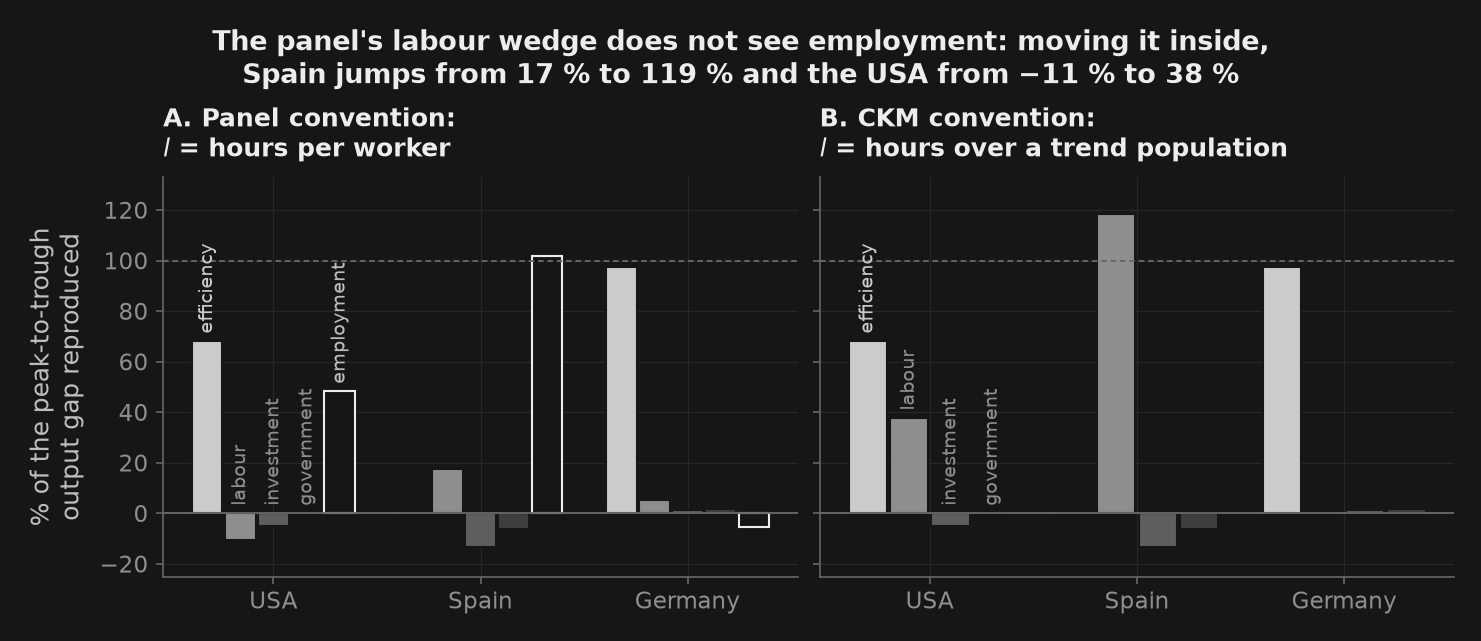

In [19]:
barc = [*_nbstyle.BARRA_COLORES, _nbstyle.FONDO]   # the four wedges as everywhere; employment hollow
# the two darkest bar tones and the hollow bar would not read as text: their names go in NOTA
ctxt = [*_nbstyle.BARRA_COLORES[:2], _nbstyle.NOTA, _nbstyle.NOTA, _nbstyle.TEXTO]
fig, axes = _nbstyle.figura(1, 2, sharey=True)
GROUPS = (("A", "efficiency"), ("S", "labour"), ("Dt", "investment"), ("G", "government"),
          ("N", "employment"))
for ax, ckm, tit in ((axes[0], False, "A. Panel convention:\n$l$ = hours per worker"),
                     (axes[1], True, "B. CKM convention:\n$l$ = hours over a trend population")):
    kk = [g for g in GROUPS if (ckm is False or g[0] != "N")]
    xs = np.arange(len(THREE)); wd = 0.8 / len(kk)
    for j, (k, lab) in enumerate(kk):
        xj = xs + (j - (len(kk) - 1) / 2) * wd
        ax.bar(xj, [SHARE[(c, ckm, k)] for c in THREE], wd * 0.92, color=barc[j], lw=1.0,
               edgecolor=_nbstyle.TINTA if k == "N" else _nbstyle.FONDO)
        # each wedge's name above its own bar for the first country
        ax.annotate(lab, (xj[0], max(SHARE[(THREE[0], ckm, k)], 0.0) + 3.0), rotation=90,
                    ha="center", va="bottom", fontsize=9, color=ctxt[j])
    ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
    ax.axhline(100, color=_nbstyle.SPINE, lw=0.9, ls=(0, (3, 2)))
    ax.set_xticks(xs); ax.set_xticklabels([NB[c] for c in THREE]); ax.set_title(tit)
axes[0].set_ylabel("% of the peak-to-trough\noutput gap reproduced")
axes[0].set_ylim(-25, 133)
fig.suptitle("The panel's labour wedge does not see employment: moving it inside,\nSpain jumps "
             "from 17 % to 119 % and the USA from −11 % to 38 %")
plt.show()


### 4.2 Five proofs that the split is not decided by the solver

The experiment has five degrees of freedom that do not come from the experiment, and all five are tested: the terminal condition on capital, the window over which the balanced path is calibrated, the expectations assumption, the United States hours series, and the population trend with which the CKM convention measures hours per person. The first two do not change the order; the third inflates the volatility of a wedge that moves nothing anyway; the fourth does turn the American split around, and that is why it is here and not in a footnote; the fifth leaves the split where it was and **shrinks the Spanish gap from 21.4 to 13.1 points**, which is exactly the distinction between what this experiment measures well and what it does not.

In [20]:
def split(d, b, idx, ckm=True, n0=N0, Kmult=1.0):
    i0, i1, ip, it = idx
    dd, bb, cl = convention(d, b, ckm, n0=n0)
    nowedge = run_(dd, bb, cl, set(), Kmult=Kmult)
    dY = 100 * np.log(d["Y"][it] / d["Y"][ip])
    d0 = 100 * np.log(nowedge["Y"][it] / nowedge["Y"][ip])
    out = {}
    for k in cl:
        r = run_(dd, bb, cl, {k}, x0=nowedge["x"], Kmult=Kmult)
        out[k] = (100 * (100 * np.log(r["Y"][it] / r["Y"][ip]) - d0) / (dY - d0), r["Y"])
    return dY - d0, out


print("(a) terminal condition: the panel's 2020Q1 capital, multiplied by 0.95 and by 1.05")
_mov = 0.0
for c in THREE:
    d, b, idx = PACK[c]
    base = split(d, b, idx)[1]
    for m in (0.95, 1.05):
        alt = split(d, b, idx, Kmult=m)[1]
        mv = max(abs(alt[k][0] - base[k][0]) for k in alt); _mov = max(_mov, mv)
        dv = max(np.max(np.abs(100 * np.log(alt[k][1][idx[0]:idx[1] + 1]
                                            / base[k][1][idx[0]:idx[1] + 1]))) for k in alt)
        print(f"    {c} x{m:.2f}: the share moves at most {mv:.1f} percentage points; "
              f"the path, {dv:.2f} log points inside 2006–2013")
assert _mov < 5.0, _mov

print("(b) balanced-path window: 2000–2006 (the panel's) against the full 2000–2019")
for c in THREE:
    d, b, idx = PACK[c]
    for lbl, bb_ in (("2000–06", b), ("2000–19", bgp(d, n0=d["T"]))):
        h, o = split(d, bb_, idx)
        print(f"    {c} {lbl}: gap {h:+6.2f} | " +
              "  ".join(f"{WNAME[k]} {o[k][0]:+6.1f}%" for k in o))

print("(c) expectations: the panel's investment wedge against the internally consistent one")
for c in THREE:
    d = PACK[c][0]
    al, be, T, Y, C, K = d["al"], d["be"], d["T"], d["Y"], d["C"], d["K"]
    tx = np.empty(T); tx[T - 1] = 1 / d["Dt"][T - 1] - 1
    for t in range(T - 2, -1, -1):        # Euler with its two dates, backwards
        tx[t] = be * (C[t] / C[t + 1]) * (al * Y[t + 1] / K[t + 1]
                                          + (1 - DELTA) * (1 + tx[t + 1])) - 1
    m = ~np.isnan(d["Dt"]); x_, y_ = np.log(d["Dt"][m]), np.log(1 / (1 + tx[m]))
    print(f"    {c}: sd = {100 * np.std(x_):5.1f} log points (panel, constant tau_x) against "
          f"{100 * np.std(y_):4.1f} (consistent sequence); corr {np.corrcoef(x_, y_)[0, 1]:+.2f}")

print("(d) the USA has no hours in the panel (it imposes H = 480*E), but the HOUR column has them")
_d = PACK["USA"][0]; _idx = PACK["USA"][2]
_hr = CTRY["USA"]["HOUR"].loc[SIM0:SIM1].to_numpy()
_d2 = dict(_d)
_d2["H"] = _hr * np.mean(_d["H"][:N0]) / np.mean(_hr[:N0])          # same scale in 2000–06
_d2["A"] = _d2["Y"] / (_d2["K"] ** _d2["al"] * _d2["H"] ** (1 - _d2["al"]))
_d2["l"] = (_d2["H"] / _d2["N"]) / 1152.0
for _lbl, _dx in (("H = 480*E, the panel", _d), ("H = HOUR rescaled", _d2)):
    _h, _o = split(_dx, bgp(_dx), _idx)
    print(f"    USA, {_lbl:21s}: hours per worker "
          f"{100 * np.log((_dx['H'] / _dx['N'])[_idx[3]] / (_dx['H'] / _dx['N'])[_idx[2]]):+5.2f} "
          f"pts | gap {_h:+6.2f} | " + "  ".join(f"{WNAME[k]} {_o[k][0]:+6.1f}%" for k in _o))
assert 38 < split(_d2, bgp(_d2), _idx)[1]["A"][0] < 52, "the USA split with HOUR"

print("(e) the CKM convention's \"trend population\" is extrapolated 2000–06 "
      "employment: in Spain, 3.47 %/year — a boom, not a demography")
POP = {}
for c in THREE:
    d, b, idx = PACK[c]
    g0 = 400 * np.log(b["N"][1] / b["N"][0])
    for lbl, g in ([("panel", g0), ("1.0", 1.0), ("0.5", 0.5)] if c == "ESP"
                   else [("panel", g0), ("1.0", 1.0)]):
        b2 = dict(b); b2["N"] = b["N"][0] * np.exp((g / 400.0) * np.arange(d["T"]))
        h, o = split(d, b2, idx)
        POP[(c, lbl)] = (h, {k: o[k][0] for k in o})
        print(f"    {c} trend {g:+5.2f} %/year{' (the panel\'s)' if lbl == 'panel' else '':16s}: "
              f"gap {h:+6.2f} | " + "  ".join(f"{WNAME[k]} {o[k][0]:+6.1f}%" for k in o))
print(f"    The SPLIT holds —Spain is still labour, Germany efficiency, investment still moves\n"
      f"    nothing—; the SIZE of the gap does not: the Spanish one goes from "
      f"{POP[('ESP', 'panel')][0]:+.1f} to {POP[('ESP', '1.0')][0]:+.1f} points\n"
      f"    and the labour share from {POP[('ESP', 'panel')][1]['S']:.1f} % to "
      f"{POP[('ESP', '1.0')][1]['S']:.1f} %. The shares are shares of a gap the trend chooses.")
assert POP[("ESP", "1.0")][1]["S"] > 100 and POP[("ESP", "0.5")][1]["S"] > 100
assert abs(POP[("ESP", "1.0")][0] + 13.1) < 0.3 and POP[("DEU", "1.0")][1]["A"] > 85
assert abs(POP[("ESP", "1.0")][1]["A"]) < 10 and POP[("USA", "1.0")][1]["A"] > 60

(a) terminal condition: the panel's 2020Q1 capital, multiplied by 0.95 and by 1.05
    USA x0.95: the share moves at most 0.4 percentage points; the path, 0.58 log points inside 2006–2013
    USA x1.05: the share moves at most 0.4 percentage points; the path, 0.59 log points inside 2006–2013
    ESP x0.95: the share moves at most 3.7 percentage points; the path, 1.07 log points inside 2006–2013
    ESP x1.05: the share moves at most 3.6 percentage points; the path, 1.08 log points inside 2006–2013
    DEU x0.95: the share moves at most 1.0 percentage points; the path, 1.25 log points inside 2006–2013
    DEU x1.05: the share moves at most 0.9 percentage points; the path, 1.24 log points inside 2006–2013
(b) balanced-path window: 2000–2006 (the panel's) against the full 2000–2019
    USA 2000–06: gap  -6.82 | efficiency  +68.1%  labour  +37.7%  investment   -5.1%  government   -0.5%
    USA 2000–19: gap  -5.96 | efficiency  +68.3%  labour  +38.4%  investment   -6.2%  government   -0.5%


    USA trend +0.80 %/year (the panel's)  : gap  -6.82 | efficiency  +68.1%  labour  +37.7%  investment   -5.1%  government   -0.5%
    USA trend +1.00 %/year                : gap  -6.98 | efficiency  +66.7%  labour  +39.1%  investment   -5.0%  government   -0.4%
    ESP trend +3.47 %/year (the panel's)  : gap -21.40 | efficiency   -0.1%  labour +118.5%  investment  -13.5%  government   -6.3%
    ESP trend +1.00 %/year                : gap -13.07 | efficiency   +0.8%  labour +130.3%  investment  -19.7%  government  -11.9%
    ESP trend +0.50 %/year                : gap -11.47 | efficiency   +1.1%  labour +134.5%  investment  -21.9%  government  -13.9%
    DEU trend -0.22 %/year (the panel's)  : gap  -8.88 | efficiency  +97.6%  labour   -0.0%  investment   +1.1%  government   +1.6%


    DEU trend +1.00 %/year                : gap  -9.59 | efficiency  +90.3%  labour   +7.4%  investment   +1.4%  government   +1.6%
    The SPLIT holds —Spain is still labour, Germany efficiency, investment still moves
    nothing—; the SIZE of the gap does not: the Spanish one goes from -21.4 to -13.1 points
    and the labour share from 118.5 % to 130.3 %. The shares are shares of a gap the trend chooses.


### 4.3 What the experiment buys, and what it does not

**The parts almost add up.** 100.2 % in the USA, 98.6 % in Spain, 100.3 % in Germany. The deck warns that the decomposition is only additive in the linear approximation, and that is true — but outside it the additivity error over this window is 1.4 **percentage points out of 100** in the worst case —0.31 log points of the 21.4 of the Spanish gap—, not an order of magnitude. Even so the simulation with the four together is reported, because it is free and because it is the only guaranteed one.

**One number does depend on the window, and it is Spanish.** The balanced path is calibrated on 2000–2006, and over that period Spanish efficiency was **falling** at 0.62 % a year. Against that path the efficiency wedge explains nothing ($-0.1$ %); against a trend fitted over the whole 2000–2019 sample it explains 24.3 % and the labour one drops to 104.3 %. The order does not change —labour first, investment negative— but the number does, and one has to say which is used. In the USA and Germany the efficiency share moves between the two trends from 68.1 to 68.3 and from 97.6 to 91.9: there is no question there. The terminal condition is innocuous in all three: multiplying the 2020Q1 capital by 0.95 or by 1.05 moves the shares 3.7 percentage points at most (Spain) and 0.4 in the USA.

**What it buys is discarding power.** If the investment wedge moves output neither in the USA, nor in Spain, nor in Germany —and it does not move it even when in Germany it falls 5.7 log points from peak to trough, 4.4 with §2's average—, financial frictions cannot be the main story of 2008–09 *in the sense the prototype knows how to read*. That is Chari, Kehoe and McGrattan's argument, and here it is run —as in 04b, by the other route— rather than merely cited.

**And a whole split hangs on one column.** The United States is one of the panel's seven countries with no hours: $H_t=480\cdot E_t$ is imposed on it, so the entire fall in hours per worker ends up inside $A_t$. The panel carries the US `HOUR` series with full coverage in 2000–2019 and does not use it. With it, hours per worker fall 2.6 log points from peak to trough, the measured fall in $A$ goes from $-2.4$ to $-1.0$, and the simulated split turns around: efficiency 44 %, labour 61 %. The order between the USA and Germany reverses with that single substitution. It is not a measurement detail: it is the difference between accusing productivity and accusing the labour market.

**What it does not buy is a model.** The Spanish labour wedge at 119 % is compatible with the labour reform, with the collapse of construction, with credit rationing, with informality and with the classification of hours: it names a family, it does not choose within it. And the German efficiency wedge at 98 % carries inside it the labour hoarding of the *Kurzarbeit*, because this panel's $A$ is the raw Solow residual — with no capital utilisation and no labour quality. That a wedge moves is not that a friction exists; it is that the data depart from the model along that margin.

## 5. Kehoe–Prescott, the scar, and the cost of a *default*

With total output, **eight** OECD economies cross the 20 % threshold of Kehoe and Prescott (2002) in the 2010s; with output **per worker**, five — and Spain disappears, from $-20.8$ to $-8.6$, because it destroyed employment and its output per worker rose. It is T01_A §5's composition effect again, now deciding who makes the list of depressions. Only three countries survive all four versions of the filter: **Greece, Italy and Finland**. And one of them is of another order: Greece touches $-50.1$ log points below the 2 % trend, far ahead of the second —Latvia, $-31.9$— and **it did not come back**: it is still at $-50.1$ in 2019Q4 and at $-50.6$ in 2025Q2, eighteen years after its peak.

Once past the filter the fall has to be split, and there the section has a single lesson: **the split is not a datum, it is a choice of $\alpha$**. With the panel's $\alpha$ —0.67 in Greece— the TFP factor of the Greek fall is $-108$ and the capital factor $+88$, for an output that falls 33; with $\alpha = 1/3$ they are $-42$ and $+22$. The same data, the same identity, two stories; the only thing that does not move is hours, $-13$. In Spain the TFP factor even changes sign: $-3.3$ with the panel's $\alpha$, $+6.9$ with $1/3$. With KP's common $\alpha$ the underlying finding does hold: in 18 of the 19 countries whose gap against the 2 % trend is worse than $-5$ in 2019Q4, the TFP factor is more negative than the sum of capital and hours. The exception is Portugal, and not through TFP: it is a reversal of capital deepening.

The third part puts that apparatus next to a number of the professor's own. The productivity cost of a sovereign *default*, 3.70–5.88 % of TFP, is replicated here as the difference between the periphery under stress and the core in 2009Q1–2012Q4: $-4.9$ log points of $\log A$ measured with each country's $\alpha_c$, cleanly inside the range — and $-2.2$ measuring the same residual with $\alpha=1/3$, which falls outside the range from below. The cost of a *default* is a choice of $\alpha$ too. And the gap comes apart as soon as Greece is removed: $-0.3$. It is a **default** cost with $n = 1$, not a risk-premium cost — the other four countries were under stress and lost no TFP. The wedge that does separate periphery from core is the labour one, $-12.4$ against $-4.4$, robust to smoothing and to the window: the periphery separates on the margin the prototype reads as **labour**, not on the one it reads as a financial friction. And inside that margin the $-8.0$ gap splits into $-7.3$ of hours per worker times three and $-0.7$ of $\log(C/Y)$: it lives in hours per worker. What moved them —fiscal programmes, labour reform, the composition of employment— the wedge does not decide; it names a family, it does not choose inside it. The provocation comes from putting the range next to the distribution: the median country lost $-4.8$ points of $\log A$ **measured with $\alpha=1/3$** from peak to trough **with no default at all**, and 22 of 33 lost more than 3.70. The paper's range is the size of an ordinary recession measured in TFP, and its entire upper end fits 4.7 times into what Greece lost.

The fourth part is the scar, and its moral is methodological: the answer depends on the counterfactual, and it has to be declared. With each country's own 2000–07 trend, the 2019 GDP gap correlates $+0.88$ with the peak-to-trough fall in $\log A$, and $+0.65$ dropping the four extremes. With a common trend of 3.29 % it is $+0.14$ or $+0.54$ **depending on where it is anchored**. And the uncomfortable number has to be printed beside it: the gap correlates $+0.87$ with the fall in GDP itself, so the scar tracks the size of the recession almost as closely as it tracks $A$. Honest persistence is measured without fitting trends: 73 % of the median country's fall in $\log A$ was still open sixteen quarters after the trough, whereas an AR(1) with trend on the same series returns a half-life of 2.7 quarters. They do not contradict each other: they measure different things, and knowing which is which is what separates a scar from a deviation around the later path.

**A note on the data, because it decides three of the four results.** First, the difference between "eight countries" and "ten" that circulates in this literature is not in the data: it is in the **anchor** of the trend. Anchored at the 2007 mean it is eight; anchored at the 2007Q4 level, ten — Lithuania and Slovenia come in. Second, Kehoe and Prescott measure output per person of working age and the panel carries no population: total output punishes those who emigrated (Latvia, Lithuania, Croatia) and output per worker rewards those who destroyed employment (Spain) or imported workers (Luxembourg). There is no neutral version; there are two, and here both are computed. Third, $\alpha_c$ is one minus a labour share **not adjusted for self-employment**, so Greek mixed income is imputed to capital, and any accounting with $1/(1-\alpha)$ inherits that. And fourth, this $\log A$ is a raw Solow residual, with no utilisation and no labour quality: comparing it with the number from a structural model is a provocation with a number, not a test. A reading warning for the table: Finland's own trough is 2009Q2, so its peak-to-trough row is the 2008–09 recession and **not** the Finnish lost decade, which appears in the 2019Q4 block.

In [21]:
# (i) The Kehoe-Prescott filter: 2 log points/year, two anchors, two denominators.
G_YR = 2.0        # 2 log points a year: the Kehoe-Prescott trend
_corr = lambda a, b: float(np.corrcoef(a, b)[0, 1])          # noqa: E731


def kp_gap(s, g=G_YR, anchor="mean2007"):
    """Deviation of s (log points) from a trend of g log points a year."""
    t = np.arange(len(s), dtype=float) / 4.0
    if anchor == "mean2007":
        a = s.loc["2007-01-01":"2007-12-31"].mean() - g * t[s.index.year == 2007].mean()
    else:                                                    # anchored at the 2007Q4 level
        i = s.index.get_loc(pd.Timestamp("2007-10-01"))
        a = s.iloc[i] - g * t[i]
    return s - (a + g * t)


KP, MIN10 = {}, {}
for var in ("Y", "Y/EMP"):
    for anc in ("mean2007", "2007Q4"):
        D = pd.DataFrame({c: kp_gap(CTRY[c]["y"] - (CTRY[c]["e"] if var == "Y/EMP" else 0.0),
                                    anchor=anc) for c in CODES})
        KP[(var, anc)] = D
        m = MIN10[(var, anc)] = D.loc["2008-01-01":"2017-12-31"].min()
        print(f"[{var:5s} anchor {anc:8s}] >=20 %: {(m <= -20).sum():2d} | "
              f">=15 %: {(m <= -15).sum():2d} | <=-15 in 2019Q4: "
              f"{(D.loc['2019-10-01'] <= -15).sum():2d} | in 2025Q2: "
              f"{(D.loc['2025-04-01'] <= -15).sum():2d} || "
              + ", ".join(f"{c} {m[c]:.1f}" for c in m[m <= -20].sort_values().index))
mY, mYq, mYE, mYEq = (MIN10[k] for k in (("Y", "mean2007"), ("Y", "2007Q4"),
                                         ("Y/EMP", "mean2007"), ("Y/EMP", "2007Q4")))
ROB = sorted(set.intersection(*[set(m[m <= -20].index) for m in (mY, mYq, mYE, mYEq)]))
NEW_ = sorted(set(mYq[mYq <= -20].index) - set(mY[mY <= -20].index))
D19, D25 = KP[("Y", "mean2007")].loc["2019-10-01"], KP[("Y", "mean2007")].loc["2025-04-01"]
c19, c25 = set(D19[D19 <= -15].index), set(D25[D25 <= -15].index)
print(f"\nThe anchor moves the count from {(mY <= -20).sum()} to {(mYq <= -20).sum()}: in come "
      f"{', '.join(f'{c} {mYq[c]:.1f}' for c in NEW_)}. Not different data: the trend.")
print(f"Robust to both anchors and both denominators: {ROB}.  Spain: Y {mY['ESP']:+.1f} "
      f"-> Y/EMP {mYE['ESP']:+.1f}; Luxembourg the other way, {mY['LUX']:+.1f} -> {mYE['LUX']:+.1f}.")
print(f"Greece: decade minimum {mY['GRC']:+.1f}; 2019Q4 {D19['GRC']:+.1f}; "
      f"2025Q2 {D25['GRC']:+.1f}. It did not come back. Still >=15 % below: {len(c19)} countries "
      f"in 2019Q4 and {len(c25)} in 2025Q2\n  (in come {', '.join(sorted(c25 - c19))}; out goes "
      f"{', '.join(sorted(c19 - c25))}): a decade at 2 % is demanding for the whole of Europe.")
assert (mY <= -20).sum() == 8 and (mYq <= -20).sum() == 10 and (mYE <= -20).sum() == 5
assert ROB == ["FIN", "GRC", "ITA"] and len(c19) == 8 and len(c25) == 12
assert abs(mY["ESP"] + 20.8) < 0.15 and abs(mYE["ESP"] + 8.6) < 0.15
assert abs(mY["GRC"] + 50.1) < 0.15 and abs(D25["GRC"] + 50.6) < 0.15

[Y     anchor mean2007] >=20 %:  8 | >=15 %: 13 | <=-15 in 2019Q4:  8 | in 2025Q2: 12 || GRC -50.1, LVA -31.9, EST -26.3, ITA -25.7, HRV -24.1, PRT -22.2, FIN -21.1, ESP -20.8
[Y     anchor 2007Q4  ] >=20 %: 10 | >=15 %: 14 | <=-15 in 2019Q4:  8 | in 2025Q2: 12 || GRC -48.9, LVA -31.3, EST -25.3, ITA -24.8, HRV -23.4, PRT -22.5, FIN -22.2, LTU -22.1, ESP -21.1, SVN -20.6
[Y/EMP anchor mean2007] >=20 %:  5 | >=15 %: 18 | <=-15 in 2019Q4: 19 | in 2025Q2: 24 || GRC -42.7, LUX -29.9, ITA -25.4, FIN -21.0, AUT -20.9
[Y/EMP anchor 2007Q4  ] >=20 %:  4 | >=15 %: 17 | <=-15 in 2019Q4: 18 | in 2025Q2: 24 || GRC -40.8, LUX -28.1, ITA -23.9, FIN -20.8

The anchor moves the count from 8 to 10: in come LTU -22.1, SVN -20.6. Not different data: the trend.
Robust to both anchors and both denominators: ['FIN', 'GRC', 'ITA'].  Spain: Y -20.8 -> Y/EMP -8.6; Luxembourg the other way, -9.7 -> -29.9.
Greece: decade minimum -50.1; 2019Q4 -50.1; 2025Q2 -50.6. It did not come back. Still >=15 % below: 8 count

In [22]:
# (ii) log Y = log A/(1-a) + [a/(1-a)] log(K/Y) + log H, with the panel's alpha and KP's 1/3.
def accounting(c, t0, t1, a):
    f = CTRY[c]
    lA = f["y"] - a * f["k"] - (1 - a) * f["h"]
    tfp = (lA[t1] - lA[t0]) / (1 - a)
    ky = a / (1 - a) * (f["ky"][t1] - f["ky"][t0])
    hh, dy = f["h"][t1] - f["h"][t0], f["y"][t1] - f["y"][t0]
    assert abs(tfp + ky + hh - dy) < 1e-6                    # the identity, to the bit
    return {"country": c, "window": f"{t0.to_period('Q')}->{t1.to_period('Q')}", "a": a,
            "dlogY": dy, "TFP": tfp, "K/Y": ky, "H": hh}


TB = pd.DataFrame([accounting(c, *REC[c], a) for c in ("GRC", "ITA", "FIN", "ESP")
                   for a in (float(CTRY[c]["alpha"].iloc[0]), 1 / 3)])
print(TB.round(2).to_string(index=False))
g67, g33 = TB[TB["country"] == "GRC"].iloc[0], TB[TB["country"] == "GRC"].iloc[1]
e67, e33 = TB[TB["country"] == "ESP"].iloc[0], TB[TB["country"] == "ESP"].iloc[1]
print(f"\nGreece, the same {g67.dlogY:+.1f} log point fall split twice: with "
      f"alpha_GRC = {g67.a:.2f}, TFP {g67.TFP:+.1f} and capital {g67['K/Y']:+.1f};\n  with "
      f"alpha = 1/3, TFP {g33.TFP:+.1f} and capital {g33['K/Y']:+.1f}. The TFP factor is "
      f"multiplied by {g67.TFP / g33.TFP:.1f} and hours ({g33.H:+.1f}) do not move.\n"
      f"  Spain over {e67.dlogY:+.1f}: the TFP factor changes SIGN, {e67.TFP:+.1f} with "
      f"alpha_ESP = {e67.a:.2f} and {e33.TFP:+.1f} with 1/3 (hours {e33.H:+.1f}).")
assert abs(g67.TFP + 107.8) < 0.2 and abs(g33.TFP + 41.6) < 0.2 and abs(g33.H + 13.0) < 0.15
assert e67.TFP < 0 < e33.TFP

GAP = []                          # 2019Q4 gap against the 2 % anchored at 2007Q4, alpha = 1/3
for c in CODES:
    f = CTRY[c].loc["2007-10-01":"2019-10-01"]
    a, t, ac = 1 / 3, (len(f) - 1) / 4.0, float(CTRY[c]["alpha"].iloc[0])
    lA = f["y"] - a * f["k"] - (1 - a) * f["h"]
    gap = (f["y"].iloc[-1] - f["y"].iloc[0]) - G_YR * t
    hh = f["h"].iloc[-1] - f["h"].iloc[0]
    tfp = (lA.iloc[-1] - lA.iloc[0]) / (1 - a) - G_YR * t
    ky = a / (1 - a) * (f["ky"].iloc[-1] - f["ky"].iloc[0])
    assert abs(gap - (tfp + ky + hh)) < 1e-6
    GAP.append({"code": c, "gap": gap, "TFP": tfp, "KY": ky, "H": hh,
                "uh": int(f["uh"].iloc[0]),
                "TFP_ac": (f["A"].iloc[-1] - f["A"].iloc[0]) / (1 - ac) - G_YR * t})
GAP = pd.DataFrame(GAP).set_index("code").sort_values("gap")
neg = GAP[GAP.gap < -5]
exc = list(neg.index[~(neg.TFP < neg.KY + neg.H)])
print("\n2019Q4 gap against the 2 % trend anchored at 2007Q4 (alpha = 1/3), "
      "the eight worst:")
print(GAP.drop(columns="uh").round(1).head(8).to_string())
print(f"Median country: gap {GAP.gap.median():+.1f} = TFP {GAP.TFP.median():+.1f} + "
      f"K/Y {GAP.KY.median():+.1f} + hours {GAP.H.median():+.1f} (separate medians; "
      f"they add to {GAP.TFP.median() + GAP.KY.median() + GAP.H.median():+.1f}).")
print(f"In {int((neg.TFP < neg.KY + neg.H).sum())} of the {len(neg)} countries with a gap < -5 "
      f"the TFP factor is more negative than the other two combined.\n  The exception is "
      f"{exc[0]}: {GAP.loc[exc[0], 'gap']:+.1f} = TFP {GAP.loc[exc[0], 'TFP']:+.1f} + "
      f"K/Y {GAP.loc[exc[0], 'KY']:+.1f} + H {GAP.loc[exc[0], 'H']:+.1f}: a reversal of "
      f"deepening, not TFP. With alpha_c\n  the Greek TFP factor would be "
      f"{GAP.loc['GRC', 'TFP_ac']:+.1f} instead of {GAP.loc['GRC', 'TFP']:+.1f}; and in the "
      f"{int((GAP.uh == 0).sum())} countries with no hours the 'hours' factor is employment "
      f"(median\n  {GAP[GAP.uh == 0].H.median():+.1f} against {GAP[GAP.uh == 1].H.median():+.1f}), "
      f"but the median TFP factor holds: {GAP[GAP.uh == 0].TFP.median():+.1f} / "
      f"{GAP[GAP.uh == 1].TFP.median():+.1f}.")
assert abs(GAP.gap.median() + 10.0) < 0.15 and abs(GAP.TFP.median() + 20.8) < 0.15
assert abs(GAP.KY.median() - 6.1) < 0.15 and abs(GAP.H.median() - 4.5) < 0.15
assert int((neg.TFP < neg.KY + neg.H).sum()) == 18 and len(neg) == 19 and exc == ["PRT"]

country         window    a  dlogY     TFP   K/Y      H
    GRC 2007Q2->2013Q1 0.67 -33.07 -107.82 87.72 -12.97
    GRC 2007Q2->2013Q1 0.33 -33.07  -41.65 21.55 -12.97
    ITA 2008Q1->2013Q2 0.63 -10.40  -22.14 23.34 -11.61
    ITA 2008Q1->2013Q2 0.33 -10.40   -5.74  6.95 -11.61
    FIN 2007Q4->2009Q2 0.53  -9.89  -22.74 17.61  -4.76
    FIN 2007Q4->2009Q2 0.33  -9.89  -12.81  7.68  -4.76
    ESP 2008Q2->2013Q3 0.52  -9.34   -3.33 18.67 -24.68
    ESP 2008Q2->2013Q3 0.33  -9.34    6.87  8.48 -24.68

Greece, the same -33.1 log point fall split twice: with alpha_GRC = 0.67, TFP -107.8 and capital +87.7;
  with alpha = 1/3, TFP -41.6 and capital +21.5. The TFP factor is multiplied by 2.6 and hours (-13.0) do not move.
  Spain over -9.3: the TFP factor changes SIGN, -3.3 with alpha_ESP = 0.52 and +6.9 with 1/3 (hours -24.7).

2019Q4 gap against the 2 % trend anchored at 2007Q4 (alpha = 1/3), the eight worst:
       gap   TFP    KY     H  TFP_ac
code                                
GRC  -48

In [23]:
# (iii) the cost of a default, replicated; (iv) the scar, with the counterfactual as a variable.
PERIPH, CORE = ["GRC", "PRT", "IRL", "ESP", "ITA"], ["DEU", "FRA", "NLD", "AUT", "FIN", "BEL"]
ART_RANGE = (-5.88, -3.70)                                   # the range in the professor's paper


def cum(col, w0, w1, ma=1):
    x = {c: (CTRY[c][col].rolling(ma, center=True, min_periods=2).mean() if ma > 1
             else CTRY[c][col]) for c in PERIPH + CORE}
    return pd.Series({c: s[pd.Timestamp(w1)] - s[pd.Timestamp(w0)] for c, s in x.items()})


R = [dict(wedge=lbl, window=f"{w0}-{w1}", MA=ma, periphery=a[PERIPH].mean(),
          core=a[CORE].mean(), gap=a[PERIPH].mean() - a[CORE].mean(),
          wo_GRC=a[[c for c in PERIPH if c != "GRC"]].mean() - a[CORE].mean())
     for col, lbl in (("A", "log A"), ("L", "log(1-tau_l)"))
     for (w0, w1), ma in ((("2009Q1", "2012Q4"), 1), (("2009Q1", "2012Q4"), 4),
                          (("2008Q1", "2014Q4"), 1))
     for a in [cum(col, w0, w1, ma)]]
print(pd.DataFrame(R).round(1).to_string(index=False))
aA, aL = cum("A", "2009Q1", "2012Q4"), cum("L", "2009Q1", "2012Q4")
brA = aA[PERIPH].mean() - aA[CORE].mean()
brA_woG = aA[[c for c in PERIPH if c != "GRC"]].mean() - aA[CORE].mean()
dA13 = pd.Series({c: dcol(c, "A13", *REC[c]) for c in CODES})
print("\n2009Q1-2012Q4, log A by country: " + ", ".join(f"{c} {aA[c]:+.1f}" for c in PERIPH + CORE))
print(f"Periphery − core gap {brA:+.1f} log points, inside the paper's range "
      f"(3.70-5.88 % of TFP); without Greece {brA_woG:+.1f}, and Greece\n  alone "
      f"{aA['GRC']:+.1f}: it is a DEFAULT cost with n = 1. The wedge that does separate "
      f"periphery from core is labour, {aL[PERIPH].mean():+.1f}\n  against "
      f"{aL[CORE].mean():+.1f}, robust to smoothing and to the window. The provocation: loss of "
      f"log A (alpha = 1/3) from peak to trough,\n  median {dA13.median():+.1f} log points, "
      f"IQR [{dA13.quantile(.25):+.1f}, {dA13.quantile(.75):+.1f}]; "
      f"{int((dA13 <= ART_RANGE[1]).sum())} of {len(dA13)} below -3.70 with NO default at all. "
      f"Greece, the only one that\n  restructured (PSI, 2012Q1), loses {dA13['GRC']:+.1f}: "
      f"between {abs(dA13['GRC'] / ART_RANGE[0]):.1f} and "
      f"{abs(dA13['GRC'] / ART_RANGE[1]):.1f} times the whole range.")
aCY, aHPE = cum("cy", "2009Q1", "2012Q4"), cum("hpe", "2009Q1", "2012Q4")
brL = aL[PERIPH].mean() - aL[CORE].mean()
brCY = aCY[PERIPH].mean() - aCY[CORE].mean()
brH3 = 3 * (aHPE[PERIPH].mean() - aHPE[CORE].mean())
aA13 = cum("A13", "2009Q1", "2012Q4")
brA13 = aA13[PERIPH].mean() - aA13[CORE].mean()
print(f"\nThe two figures needed so as not to compare apples with oranges:\n"
      f"  (1) the LABOUR wedge gap, {brL:+.1f}, splits to the bit into log(C/Y) {brCY:+.1f}\n"
      f"      and 3·log(H/E) {brH3:+.1f}: it lives in HOURS PER WORKER, not in consumption.\n"
      f"      What produced them —fiscal programmes, labour reform, composition— the wedge does not say.\n"
      f"  (2) the log A gap is {brA:+.1f} with each country's alpha_c and {brA13:+.1f} with\n"
      f"      alpha = 1/3, the convention of the distribution above: under that convention it\n"
      f"      falls OUTSIDE the paper's range from below. The default cost moves with alpha.")
assert abs(brCY + brH3 - brL) < 1e-9
assert abs(brH3 + 7.3) < 0.15 and abs(brCY + 0.7) < 0.15 and abs(brA13 + 2.2) < 0.15
assert abs(brA + 4.9) < 0.15 and abs(brA_woG + 0.3) < 0.15 and abs(aA["GRC"] + 21.1) < 0.15
assert abs(aL[PERIPH].mean() + 12.4) < 0.15 and abs(aL[CORE].mean() + 4.4) < 0.15
assert abs(dA13.median() + 4.8) < 0.15 and int((dA13 <= ART_RANGE[1]).sum()) == 22
assert abs(dA13["GRC"] + 27.8) < 0.2


def gap_2019(c, mode="own", g=None):
    """2019 level minus the counterfactual: own trend, or a common one anchored at 2000-07
    or at 2007Q4."""
    s = CTRY[c]["y"]; t = np.arange(len(s), dtype=float) / 4.0
    fit = s.loc["2000-01-01":"2007-12-31"]
    res = ols(fit.to_numpy(), add_constant(t[:len(fit)]), cov_type="HC1")
    b = [float(res.params[1]), float(res.params[0])]
    i07 = s.index.get_loc(pd.Timestamp("2007-10-01"))
    cf_ = (b[1] + b[0] * t if mode == "own" else fit.mean() + g * (t - t[:len(fit)].mean())
           if mode == "mean0007" else s.iloc[i07] + g * (t - t[i07]))
    return float((s - pd.Series(cf_, index=s.index)).loc["2019-01-01":"2019-12-31"].mean()), b[0]


SC = pd.DataFrame({c: {"gap": gap_2019(c)[0], "g0007": gap_2019(c)[1], "dY": DY[c],
                       "dA": dcol(c, "A", *REC[c]), "dL": dcol(c, "L", *REC[c])}
                   for c in CODES}).T
gmed = SC.g0007.median()
for mode in ("mean0007", "2007Q4"):
    SC[f"gap_{mode}"] = [gap_2019(c, mode, gmed)[0] for c in CODES]
U = SC.drop(index="IRL")                                     # the 2015 revision poisons IRL
U4 = U.drop(index=["LVA", "EST", "LTU", "GRC"])
still_open, rho = {}, {}
for c in CODES:
    s, (pk, tr) = CTRY[c]["A"], REC[c]
    i = s.index.get_loc(tr)
    if DY[c] < -3:
        still_open[c] = (s.iloc[min(i + 16, len(s) - 1)] - s[pk]) / (s[tr] - s[pk])
    z = s.loc["2009-04-01":"2019-12-31"].dropna().to_numpy()
    X = np.column_stack([np.ones(len(z) - 1), np.arange(len(z) - 1, dtype=float), z[:-1]])
    res = ols(z[1:], X, cov_type="HC1")
    rho[c] = float(res.params[2])
still_open, rho = pd.Series(still_open), pd.Series(rho)
vm = -np.log(2) / np.log(rho.median())
print(f"\n2019 GDP gap vs the own 2000-07 trend: median {SC.gap.median():+.1f} log points, below "
      f"it in {(SC.gap < 0).sum()} of {len(SC)};\n  median own growth {gmed:.2f} %/yr. "
      f"corr(gap, dlogA) = {_corr(U.dA, U.gap):+.2f} (n = {len(U)}, no IRL); without the four extremes "
      f"{_corr(U4.dA, U4.gap):+.2f}\n  (n = {len(U4)}); with the labour wedge "
      f"{_corr(U.dL, U.gap):+.2f}. And the uncomfortable number: corr(gap, dlogY) = "
      f"{_corr(U.dY, U.gap):+.2f}, that is, the scar\n  tracks the SIZE of the recession almost "
      f"as closely as it tracks A. With a COMMON trend of {gmed:.2f} %/yr everything\n  "
      f"depends on the ANCHOR: at the 2000-07 mean {_corr(U.dA, U.gap_mean0007):+.2f}; at the "
      f"2007Q4 level {_corr(U.dA, U['gap_2007Q4']):+.2f}.")
print(f"Persistence, two measures (dY < -3, n = {len(still_open)}): share of the fall in log A "
      f"still open 16 quarters after the\n  trough, median {still_open.median():.2f} "
      f"(IQR {still_open.quantile(.25):.2f}-{still_open.quantile(.75):.2f}; more than half open "
      f"in {(still_open > 0.5).sum()} of {len(still_open)}); AR(1) with trend in 2009Q2-2019Q4, "
      f"median\n  rho {rho.median():.2f} -> half-life {vm:.1f} quarters. They do not contradict "
      f"each other: the fitted trend absorbs the level step and the\n  AR(1) measures the "
      f"persistence of deviations AROUND the later path.")
assert abs(_corr(U.dA, U.gap) - 0.88) < 0.02 and abs(_corr(U4.dA, U4.gap) - 0.65) < 0.02
assert abs(_corr(U.dY, U.gap) - 0.87) < 0.02
assert abs(_corr(U.dA, U.gap_mean0007) - 0.14) < 0.03
assert abs(_corr(U.dA, U["gap_2007Q4"]) - 0.54) < 0.03
assert abs(still_open.median() - 0.73) < 0.02 and abs(rho.median() - 0.77) < 0.02
assert abs(vm - 2.7) < 0.15

       wedge        window  MA  periphery  core  gap  wo_GRC
       log A 2009Q1-2012Q4   1       -2.9   2.1 -4.9    -0.3
       log A 2009Q1-2012Q4   4       -3.9   0.6 -4.4     0.7
       log A 2008Q1-2014Q4   1       -5.0  -2.4 -2.7     3.2
log(1-tau_l) 2009Q1-2012Q4   1      -12.4  -4.4 -8.0   -10.1
log(1-tau_l) 2009Q1-2012Q4   4      -13.0  -5.1 -8.0   -10.9
log(1-tau_l) 2008Q1-2014Q4   1      -16.1  -7.7 -8.4   -10.7

2009Q1-2012Q4, log A by country: GRC -21.1, PRT +6.0, IRL +1.8, ESP +0.6, ITA -1.6, DEU +8.8, FRA +1.2, NLD +1.6, AUT +1.5, FIN -0.8, BEL -0.1
Periphery − core gap -4.9 log points, inside the paper's range (3.70-5.88 % of TFP); without Greece -0.3, and Greece
  alone -21.1: it is a DEFAULT cost with n = 1. The wedge that does separate periphery from core is labour, -12.4
  against -4.4, robust to smoothing and to the window. The provocation: loss of log A (alpha = 1/3) from peak to trough,
  median -4.8 log points, IQR [-8.1, -3.4]; 22 of 33 below -3.70 with NO defa


2019 GDP gap vs the own 2000-07 trend: median -14.8 log points, below it in 31 of 33;
  median own growth 3.29 %/yr. corr(gap, dlogA) = +0.88 (n = 32, no IRL); without the four extremes +0.65
  (n = 28); with the labour wedge +0.45. And the uncomfortable number: corr(gap, dlogY) = +0.87, that is, the scar
  tracks the SIZE of the recession almost as closely as it tracks A. With a COMMON trend of 3.29 %/yr everything
  depends on the ANCHOR: at the 2000-07 mean +0.14; at the 2007Q4 level +0.54.
Persistence, two measures (dY < -3, n = 30): share of the fall in log A still open 16 quarters after the
  trough, median 0.73 (IQR 0.41-0.88; more than half open in 21 of 30); AR(1) with trend in 2009Q2-2019Q4, median
  rho 0.77 -> half-life 2.7 quarters. They do not contradict each other: the fitted trend absorbs the level step and the
  AR(1) measures the persistence of deviations AROUND the later path.


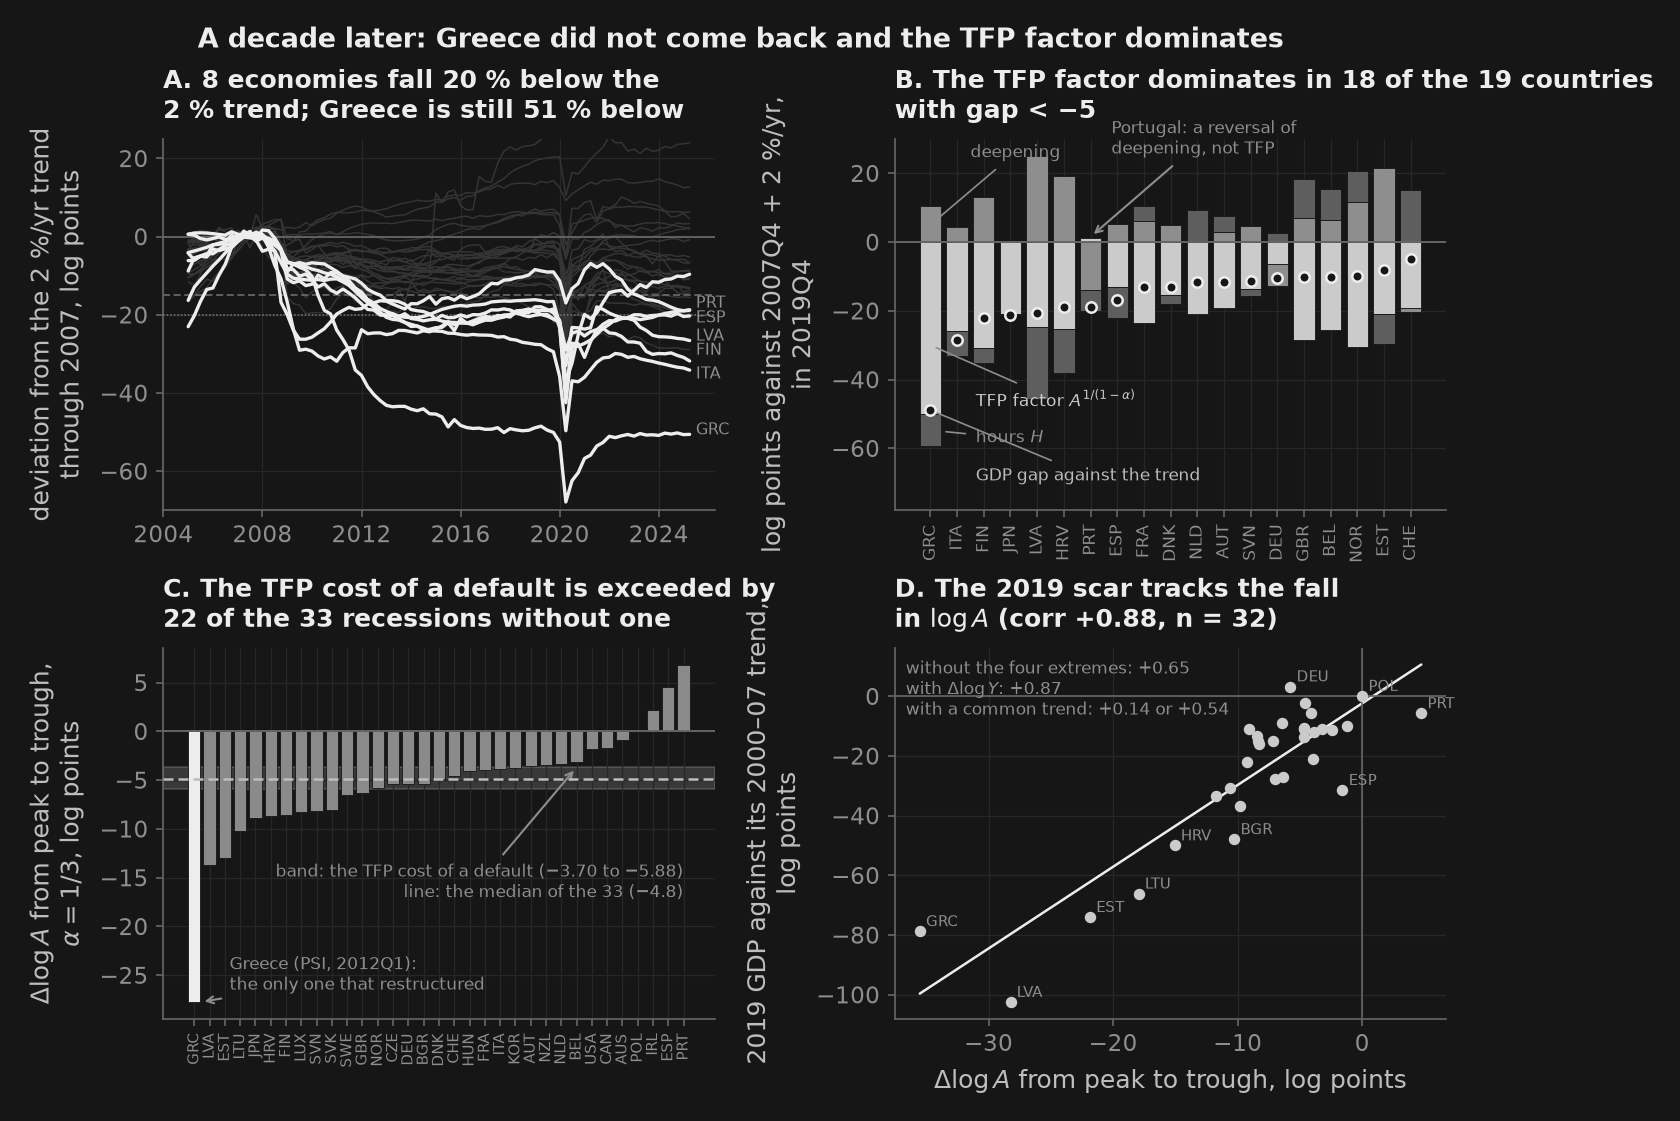

In [24]:
fig, ax = _nbstyle.figura(2, 2, figsize="2x2")
DV, club20 = KP[("Y", "mean2007")].loc["2005-01-01":], list(mY[mY <= -20].index)
for c in CODES:
    e = (cols[0], 1.6, 3) if c in club20 else (_nbstyle.gris("0.78"), 0.7, 1)
    ax[0, 0].plot(DV.index, DV[c], color=e[0], ls="-", lw=e[1], zorder=e[2])
for c, dy in (("GRC", 0), ("ITA", -4), ("FIN", 3), ("LVA", 0), ("PRT", 4), ("ESP", -6)):
    ax[0, 0].annotate(c, (DV.index[-1], DV[c].iloc[-1]), fontsize=7.6, color=_nbstyle.NOTA,
                      xytext=(3, dy), textcoords="offset points")
for lv, ls in ((0, "-"), (-15, (0, (4, 2))), (-20, (0, (1, 1)))):
    ax[0, 0].axhline(lv, color=_nbstyle.SPINE, lw=0.85, ls=ls)
ax[0, 0].set_ylim(-70, 25)
ax[0, 0].set_ylabel("deviation from the 2 %/yr trend\nthrough 2007, log points")
ax[0, 0].set_title(f"A. {(mY <= -20).sum()} economies fall 20 % below the\n2 % trend; Greece is "
                   f"still {abs(D25['GRC']):.0f} % below")

r_ = neg.sort_values("gap"); x = np.arange(len(r_)); bp = np.zeros(len(r_)); bn = np.zeros(len(r_))
FACTORS = (("TFP", "TFP factor $A^{1/(1-\\alpha)}$", _nbstyle.BARRA_COLORES[0]),
           ("KY", "deepening", _nbstyle.BARRA_COLORES[1]),
           ("H", "hours $H$", _nbstyle.BARRA_COLORES[2]))
for k, lbl, col in FACTORS:
    v = r_[k].to_numpy(); base = np.where(v >= 0, bp, bn)
    ax[0, 1].bar(x, v, bottom=base, color=col, edgecolor=_nbstyle.FONDO, lw=0.4)
    bp, bn = bp + np.where(v >= 0, v, 0.0), bn + np.where(v < 0, v, 0.0)
ax[0, 1].plot(x, r_["gap"].to_numpy(), "o", ms=5, mfc=_nbstyle.FONDO,
              mec=_nbstyle.TINTA, mew=1.2, ls="none", zorder=5)
ax[0, 1].axhline(0, color=_nbstyle.SPINE, lw=0.9); ax[0, 1].set_ylim(-78, 30)
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(r_.index, rotation=90, fontsize=8)
ax[0, 1].set_ylabel("log points against 2007Q4 + 2 %/yr,\nin 2019Q4")
# Each factor next to one of Greece's own segments, the first bar: 19 stacked bars leave
# no room to repeat the name country by country.  The two dark tones are named in NOTA.
for lbl, col, xy_txt, xy_pt in (
        (FACTORS[0][1], FACTORS[0][2], (1.7, -46.0), (0.0, -30.0)),
        (FACTORS[1][1], _nbstyle.NOTA, (1.5, 26.0), (0.0, 5.0)),
        (FACTORS[2][1], _nbstyle.NOTA, (1.7, -57.0), (0.35, -55.0)),
        ("GDP gap against the trend", _nbstyle.TEXTO, (1.7, -68.0),
         (0.0, float(r_["gap"].iloc[0])))):
    ax[0, 1].annotate(lbl, xy=xy_pt, xytext=xy_txt, ha="left", va="center", fontsize=8.4,
                      color=col, arrowprops=dict(arrowstyle="-", color=_nbstyle.NOTA, lw=0.8,
                                                 shrinkA=3, shrinkB=3))
ax[0, 1].annotate("Portugal: a reversal of\ndeepening, not TFP",
                  xy=(int(np.where(r_.index == "PRT")[0][0]), 1.5), xytext=(10, 40),
                  textcoords="offset points", fontsize=8, color=_nbstyle.NOTA,
                  arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.0))
ax[0, 1].set_title(f"B. The TFP factor dominates in {int((neg.TFP < neg.KY + neg.H).sum())} of "
                   f"the {len(neg)} countries\nwith gap < −5")

s_ = dA13.sort_values(); x = np.arange(len(s_))
ax[1, 0].bar(x, s_.to_numpy(), color=cols[3], edgecolor=_nbstyle.FONDO, lw=0.4)
ax[1, 0].bar(x[s_.index == "GRC"], s_[s_.index == "GRC"].to_numpy(), color=cols[0],
             edgecolor=_nbstyle.FONDO, lw=0.4)
ax[1, 0].axhspan(ART_RANGE[0], ART_RANGE[1], color=_nbstyle.BANDA, zorder=0)
ax[1, 0].axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax[1, 0].axhline(dA13.median(), color=_nbstyle.TEXTO, lw=1.2, ls=(0, (4, 2)), zorder=4)
ax[1, 0].set_xticks(x); ax[1, 0].set_xticklabels(s_.index, rotation=90, fontsize=7.4)
ax[1, 0].set_ylabel("$\\Delta\\log A$ from peak to trough,\n$\\alpha = 1/3$, log points")
FL = dict(fontsize=8.2, color=_nbstyle.NOTA, arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.0))
ax[1, 0].annotate(f"band: the TFP cost of a default (−3.70 to −5.88)\nline: the median of the "
                  f"{len(dA13)} ({dA13.median():.1f})".replace("-", "−"),
                  xy=(len(s_) - 8, ART_RANGE[1]), xytext=(len(s_) - 1, -17), ha="right", **FL)
ax[1, 0].annotate("Greece (PSI, 2012Q1):\nthe only one that restructured", xy=(0.4, dA13["GRC"]),
                  xytext=(14, 6), textcoords="offset points", **FL)
ax[1, 0].set_title(f"C. The TFP cost of a default is exceeded by\n"
                   f"{int((dA13 <= ART_RANGE[1]).sum())} of the {len(dA13)} recessions "
                   f"without one")

ax[1, 1].scatter(U.dA, U.gap, s=20, color=cols[1], zorder=3)
# only the countries away from the central cluster: with all 32 the labels collide
for c in ("GRC", "LVA", "EST", "LTU", "HRV", "BGR", "ESP", "PRT", "POL", "DEU"):
    ax[1, 1].annotate(c, (U.loc[c, "dA"], U.loc[c, "gap"]), fontsize=7.4, color=_nbstyle.NOTA,
                      xytext=(3, 2.5), textcoords="offset points")
res_bb = ols(U.gap.to_numpy(), add_constant(U.dA.to_numpy()), cov_type="HC1")
bb = [float(res_bb.params[1]), float(res_bb.params[0])]
xx = np.linspace(U.dA.min(), U.dA.max(), 10)
ax[1, 1].plot(xx, bb[1] + bb[0] * xx, color=cols[0], lw=1.2, zorder=2)
ax[1, 1].axhline(0, color=_nbstyle.SPINE, lw=0.8); ax[1, 1].axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax[1, 1].set_xlabel("$\\Delta\\log A$ from peak to trough, log points")
ax[1, 1].set_ylabel("2019 GDP against its 2000–07 trend,\nlog points")
ax[1, 1].text(0.02, 0.97, f"without the four extremes: {_corr(U4.dA, U4.gap):+.2f}\nwith "
              f"$\\Delta\\log Y$: {_corr(U.dY, U.gap):+.2f}\nwith a common trend: "
              f"{_corr(U.dA, U.gap_mean0007):+.2f} or {_corr(U.dA, U['gap_2007Q4']):+.2f}",
              transform=ax[1, 1].transAxes, fontsize=8.2, color=_nbstyle.NOTA, va="top")
ax[1, 1].set_title(f"D. The 2019 scar tracks the fall\nin $\\log A$ (corr "
                   f"{_corr(U.dA, U.gap):+.2f}, n = {len(U)})")
fig.suptitle("A decade later: Greece did not come back and the TFP factor dominates")
plt.show()


## 6. Mexico, and why it is not in the panel

The caption of deck A4's figure declares it out loud: Mexico is not in the 33-economy panel, and that is why the Great Recession is compared with Spain and not with the country half this course is about. This section works out what it would take to fix that, and the answer is more interesting than a "no".

Of the four wedges, Mexico can have **one clean** —the labour one, exact and with no error bar—, **one with a bar** —the efficiency one, whose *cycle* survives everything we do not know and whose *trend* does not—, and neither of the other two. The investment one, because the capital stock that does not exist enters it twice. The government one, for a reason that has nothing to do with capital and that we would not have found without looking.

What is **not** missing is almost everything. Quarterly output, consumption, investment and public spending from 1995Q1 in `qna_gasto.csv`; hours and workers from 2005Q1 in `qna_mercado_laboral.csv`, with `hours_factor` = 1.0, that is, on the right time base and with none of the repair Chile and Costa Rica needed in T01_B §5.1. Mexico is not out of the panel for lack of expenditure or labour data.

**A note on the data, because here the data decide all four answers.** Three things, and each one kills a different wedge.

The first is **capital**. Nobody publishes a homogeneous quarterly stock, so the panel builds it by perpetual inventory, $K_{t+1}=(1-\delta)K_t+I_t$ with $\delta=0.015$, and a $K_0$ has to be chosen. The error of that choice dies with a half-life of $\ln(1/2)/\ln(1-\delta)$ = **46 quarters**: eleven and a half years. With a hundred quarters of Mexican investment ahead, 22 % of the initial error still survives in 2019Q4.

The second is **$\alpha$**. Mexico's raw labour share —compensation of employees over income-side GDP— is 26.4 %, which gives $\alpha=0.736$, **above the maximum of the entire panel** (Greece, 0.671). T01_B §3.2's Gollin adjustment, imputing the average wage to the 33 % who are self-employed, brings it to 0.610, now inside the range. And `comp_emp` starts in 2008Q1: the 2000–2006 window with which the panel calibrates $\alpha$, $\beta$ and $\psi$ country by country **does not exist for Mexico**.

The third is discovered by measuring. Mexico chain-links its volumes **quarter by quarter** (`price_base = 'Q'`) and not year by year like 43 of the 49 countries in the file, and the non-additivity that produces is of another order of magnitude.

A rule that is not broken anywhere in this section: the panel does not carry Mexico, so **no Mexican wedge from the panel is quoted here**. Everything below is built from `qna_*.csv` and validated against countries that are in it.

In [25]:
# --- The inventory: what the prototype asks for, and what Mexico has ---------
spend, lab, inc = gasto(), mercado_laboral(), renta()
mxl, mxr = lab.loc["MEX"], inc.loc["MEX"]


def pieces(code):
    """The prototype's pieces, in the panel's exact convention."""
    Yc = volumen("gdp", code).dropna()
    Cc = (volumen("cons_hh", code) + volumen("cons_gov", code)
          - volumen("cons_dur", code)).dropna()                          # RCON − RDC
    Ic = (volumen("capform", code) + volumen("cons_dur", code)).dropna()  # RGCF + RDC
    L = lab.loc[code]
    return Yc, Cc, Ic, L["emp"].dropna(), L["hours"].dropna()


mxY, mxC, mxI, mxE, mxH = pieces("MEX")
mxG = (mxY - mxC - mxI).dropna()
LS = (mxr["comp_emp"] / mxr["gdp_income"]).dropna()
GOL = (LS * (mxl["emp"] / mxl["emp_employees"])).dropna()             # Gollin, T01_B §3.2
AC = WEDGES.groupby("code")["alpha_c"].first()

print("What the prototype needs from each country, and what data_curso/ has for Mexico:\n")
print(f"{'input':<27}{'where it comes from':<32}{'from':>8}{'to':>8}{'n':>5}")
for lbl, src, s in [("Y   output", "qna_gasto  gdp/gdp_defl", mxY),
                    ("C   non-durable consumption", "cons_hh+cons_gov−cons_dur", mxC),
                    ("I   investment + durables", "capform+cons_dur", mxI),
                    ("g   government wedge", "residual  Y−C−I", mxG),
                    ("E   workers", "qna_mercado_laboral  emp", mxE),
                    ("H   hours worked", "qna_mercado_laboral  hours", mxH),
                    ("1−α labour share", "qna_renta  comp_emp/gdp_income", LS),
                    ("K   capital stock", "no quarterly source", None)]:
    a, b, n = (("—", "—", 0) if s is None else
               (str(s.index.min().to_period("Q")), str(s.index.max().to_period("Q")), len(s)))
    print(f"{lbl:<27}{src:<32}{a:>8}{b:>8}{n:>5}")

print(f"\nThe panel has {len(CODES)} economies and Mexico is not one "
      f"(MEX in the panel: {'MEX' in set(WEDGES['code'])}). Two things are missing, not one:")
print("  · quarterly K: no source in the course publishes it.")
print(f"  · α: Mexico's comp_emp starts in {LS.index.min().to_period('Q')}, so the 2000–2006 "
      f"window with which the panel\n    calibrates α, β and ψ country by country does not exist "
      f"for Mexico. And the number is odd: raw α\n    1−{LS.mean():.3f} = {1 - LS.mean():.3f}; "
      f"Gollin (imputing the average wage to the {mxl['self_emp_share'].mean():.0f}% self-employed) "
      f"1−{GOL.mean():.3f} = {1 - GOL.mean():.3f};\n    the panel runs from {AC.min():.3f} "
      f"({AC.idxmin()}) to {AC.max():.3f} ({AC.idxmax()}), median {AC.median():.3f}.")
print(f"  · H and E exist from {mxH.index.min().to_period('Q')}, with hours_factor = "
      f"{float(mxl['hours_factor'].dropna().iloc[0]):.1f} and {mxl['hours_week'].mean():.1f} "
      f"h/week: the 1995 Tequila crisis is\n    left with no labour input, and with it half the "
      f"wedges.")

mxly = 100 * np.log(mxY)
PEAK = mxly.loc["2007":"2008-12-31"].idxmax()
TROUGH = mxly.loc[PEAK:"2013-12-31"].idxmin()
dY_mx = float(mxly[TROUGH] - mxly[PEAK])
dH_mx = float(100 * np.log(mxH[TROUGH] / mxH[PEAK]))
dE_mx = float(100 * np.log(mxE[TROUGH] / mxE[PEAK]))
print(f"\nMexican recession, with the notebook's single dating on the course's GDP: "
      f"{PEAK.to_period('Q')} → {TROUGH.to_period('Q')}, {dY_mx:+.1f} log points.")
print(f"  T01_A §5's three margins: Y/H {dY_mx - dH_mx:+.1f}, H/E {dH_mx - dE_mx:+.1f}, "
      f"employment {dE_mx:+.1f}.")
assert len(mxY) == 125 and len(mxH) == 85 and len(LS) == 71
assert "MEX" not in set(WEDGES["code"])
assert abs(dY_mx + 9.7) < 0.15 and abs(dE_mx) < 0.5
assert 1 - LS.mean() > AC.max() and AC.min() < 1 - GOL.mean() < AC.max()

What the prototype needs from each country, and what data_curso/ has for Mexico:

input                      where it comes from                 from      to    n
Y   output                 qna_gasto  gdp/gdp_defl           1995Q1  2026Q1  125
C   non-durable consumptioncons_hh+cons_gov−cons_dur         1995Q1  2026Q1  125
I   investment + durables  capform+cons_dur                  1995Q1  2026Q1  125
g   government wedge       residual  Y−C−I                   1995Q1  2026Q1  125
E   workers                qna_mercado_laboral  emp          2005Q1  2026Q1   85
H   hours worked           qna_mercado_laboral  hours        2005Q1  2026Q1   85
1−α labour share           qna_renta  comp_emp/gdp_income    2008Q1  2025Q3   71
K   capital stock          no quarterly source                    —       —    0

The panel has 33 economies and Mexico is not one (MEX in the panel: False). Two things are missing, not one:
  · quarterly K: no source in the course publishes it.
  · α: Mexico's comp_emp

### 6.1 Capital: six defensible rules, six different economies

The construction is the panel's, verified to the bit in §1: $K_{t+1}=(1-\delta)K_t+I_t$, with $A=Y/(K_t^{\alpha}H^{1-\alpha})$ and **contemporaneous** capital. The only thing that has to be invented is $K_0$, and there are two honest ways of doing it. The balanced-growth one, $K_0=I_1/(g+\delta)$, uses no external information. The other anchors the initial $K/Y$ on the Penn World Table, which does have a Mexican stock —annual, `RKNANPMXA666NRUG`, from PWT 10.01— and therefore knows something the quarterly accounts do not.

The two disagree by 24 %, and that disagreement is the object of this section. As a check that the whole pipeline works, it is run over the fourteen panel countries that have the same pieces in `qna_gasto` and compared with their published `logA`.

In [26]:
# --- 6.1 Build K, and measure how much not knowing it hurts ------------------
KYp = (pd.read_csv(DATOS / "RKNANPMXA666NRUG.csv", parse_dates=["observation_date"])
       .set_index("observation_date").iloc[:, 0]
       / pd.read_csv(DATOS / "RGDPNAMXA666NRUG.csv", parse_dates=["observation_date"])
       .set_index("observation_date").iloc[:, 0])
KYp.index = KYp.index.year
KY_PWT = 4.0 * KYp[1995]          # the PWT is annual; the panel reasons in quarterly GDP


def accumulate(inv, K0, d):
    """K_{t+1} = (1−d)·K_t + I_t — the panel's law of motion, verified to the bit in §1."""
    k = np.empty(len(inv)); k[0] = K0; v = inv.to_numpy()
    for t in range(1, len(inv)):
        k[t] = (1.0 - d) * k[t - 1] + v[t - 1]
    return pd.Series(k, index=inv.index)


def rate(Yc):
    """Mean quarterly growth up to 2019Q4: the g of the balanced growth path."""
    return float(np.exp(np.log(Yc.loc[:HASTA].iloc[-1] / Yc.iloc[0])
                        / (len(Yc.loc[:HASTA]) - 1)) - 1)


def solow(Yc, K, Hc, al):
    """100·log A = 100·[log Y − α log K_t − (1−α) log H], the panel's CONTEMPORANEOUS K."""
    ix = Hc.index.intersection(K.index)
    return (100 * (np.log(Yc[ix]) - al * np.log(K[ix]) - (1 - al) * np.log(Hc[ix]))).dropna()


gq = rate(mxY)
kyp = (WEDGES.loc[WEDGES["date"] == pd.Timestamp("2019-10-01")]
       .assign(ky=lambda d: d["K"] / d["Y"]).set_index("code")["ky"])
print(f"Mexican GDP grew {100 * gq:.3f}% per quarter in 1995Q1–2019Q4. The balanced-growth rule,\n"
      f"K0 = I_1/(g+δ), gives K0/Y0 = "
      f"{float(mxI.iloc[0] / (gq + DELTA) / mxY.iloc[0]):.1f}; the external PWT anchor says "
      f"{KY_PWT:.1f}. The rule is off\nby "
      f"{100 * float(mxI.iloc[0] / (gq + DELTA) / mxY.iloc[0]) / KY_PWT - 100:+.0f}%, and that "
      f"error dies with a half-life of ln(1/2)/ln(1−δ) = "
      f"{np.log(0.5) / np.log(1 - DELTA):.0f} quarters:\nin 2019Q4, a hundred quarters later, "
      f"(1−δ)^100 = {(1 - DELTA) ** 100:.2f} of it still survives.")
print(f"PWT K/Y for Mexico: {KYp[1995]:.2f} → {KYp[2019]:.2f} annual = "
      f"{4 * KYp[1995]:.1f} → {4 * KYp[2019]:.1f} quarterly.\nPanel K/Y in 2019Q4: median "
      f"{kyp.median():.1f}, interquartile {kyp.quantile(.25):.1f}–{kyp.quantile(.75):.1f}, "
      f"range {kyp.min():.1f} ({kyp.idxmin()}) to {kyp.max():.1f} ({kyp.idxmax()}).")

iy = (mxI.resample("YE").sum() / mxY.resample("YE").sum()); iy.index = iy.index.year
gr_a = mxY.resample("YE").sum().pct_change(); gr_a.index = gr_a.index.year
da = pd.Series({a: 1 - (KYp[a] * (1 + gr_a[a]) - iy[a]) / KYp[a - 1] for a in range(1996, 2020)})
print(f"Annual δ that reconciles the PWT K with the accounts' investment, 1996–2019: "
      f"median {da.median():.3f}\n= {1 - (1 - da.median()) ** 0.25:.4f} quarterly, against the "
      f"panel's {DELTA} ({1 - (1 - DELTA) ** 4:.3f} annual). The panel's δ works for Mexico; "
      f"its K0 does not.")

# The same pipeline, over the panel countries that do have something to compare against.
val = []
for code in ["ESP", "DEU", "ITA", "FRA", "PRT", "CZE", "HUN", "SVK", "BEL",
             "NLD", "AUT", "FIN", "SWE", "DNK"]:
    Yc, Cc, Ic, Ec, Hc = pieces(code)
    p, lyc = CTRY[code], 100 * np.log(Yc)
    pk = lyc.loc["2007":"2008-12-31"].idxmax(); tv = lyc.loc[pk:"2013-12-31"].idxmin()
    Kc = accumulate(Ic, Ic.iloc[0] / (rate(Yc) + DELTA), DELTA)
    lAc = solow(Yc, Kc, Hc, float(p["alpha"].iloc[0]))
    val.append({"code": code, "err": float(lAc[tv] - lAc[pk]) - float(p["A"][tv] - p["A"][pk]),
                "rec": float(lAc[tv] - lAc[pk]), "pan": float(p["A"][tv] - p["A"][pk]),
                "dky": float(Kc.loc["2019-10-01"] / Yc.loc["2019-10-01"]
                             - p["K"].loc["2019-10-01"] / np.exp(p["y"].loc["2019-10-01"] / 100))})
V = pd.DataFrame(val).set_index("code")
sp = V.drop(index="PRT")
print(f"\nControl: the same pipeline over the {len(V)} panel countries with these same pieces in "
      f"qna_gasto.\n  Median error in the peak-to-trough ΔlogA {V.err.abs().median():.2f} pp "
      f"(without PRT {sp.err.abs().median():.2f}, maximum {sp.err.abs().max():.2f} in "
      f"{sp.err.abs().idxmax()}); corr {V.rec.corr(V.pan):+.3f};\n  median error of the 2019Q4 "
      f"K/Y {V.dky.median():+.2f}. The only big failure is PRT ({V.err['PRT']:+.1f} pp): the "
      f"panel gives it a K0 that\n  implies an initial K/Y three times the median.")
assert sp["err"].abs().median() < 1.5 and V.rec.corr(V.pan) > 0.85

# The grid: two K0 rules × three δ × three α, and the two wedges that depend on it.
IDX = mxH.index
ALS = {"raw": 1 - LS.mean(), "Gollin": 1 - GOL.mean(), "panel": float(AC.median())}
K0R = {"BGP": lambda d: mxI.iloc[0] / (gq + d), "PWT": lambda d: KY_PWT * mxY.iloc[0]}
rows, SER = [], {}
for kn, kf in K0R.items():
    for d in (0.010, 0.015, 0.020):
        K = accumulate(mxI, kf(d), d)
        for an, al in ALS.items():
            lA = solow(mxY, K, mxH, al); lA = lA - float(lA[BASE].mean())
            # β is calibrated with the mean MPK of 2000–06, which already carries the chosen K0
            mpk = float((al * mxY / K).loc["2000-01-01":"2006-12-31"].mean())
            beta_mx = float(np.clip(1.0 / (mpk + 1 - d), 0.90, 0.997))
            td = (((1 / beta_mx) * (mxC / mxC.shift(1)) - (1 - d)) / (al * mxY / K)).dropna()
            td = td / float(td.loc["2000-01-01":"2006-12-31"].mean())
            lD = pd.Series(np.where(td > 0, 100 * np.log(td.where(td > 0)), np.nan),
                           index=td.index).dropna()
            lD = lD - float(lD[BASE].mean())
            SER[(kn, d, an)] = (K, lA, lD)
            rows.append({"K0": kn, "δ": f"{d:.3f}", "α": f"{an} {al:.3f}", "β": beta_mx,
                         "K/Y 19Q4": float(K.loc["2019-10-01"] / mxY.loc["2019-10-01"]),
                         "ΔlogA recession": float(lA[TROUGH] - lA[PEAK]),
                         "ΔlogA 05–19": float(lA.loc["2019-10-01"] - lA.loc["2005-01-01"]),
                         "logD trough": float(lD[TROUGH])})
TG = pd.DataFrame(rows)
CEN = ("PWT", 0.015, "Gollin")
cc = TG[(TG.K0 == "PWT") & (TG["δ"] == "0.015") & (TG["α"].str.startswith("Gollin"))].iloc[0]
print(f"\nThe full grid, {len(TG)} combinations of (K0, δ, α):\n")
print(TG.round(2).to_string(index=False))
print(f"\nCentral (PWT K0, δ={DELTA}, Gollin α {ALS['Gollin']:.3f} → β {cc['β']:.3f}): "
      f"the efficiency wedge falls {cc['ΔlogA recession']:+.1f} points from peak to trough.")
for col, et in (("K/Y 19Q4", "K/Y in 2019Q4"),
                ("ΔlogA recession", "efficiency, peak to trough"),
                ("ΔlogA 05–19", "efficiency, drift 2005Q1→2019Q4"),
                ("logD trough", "investment, at the trough against 2006")):
    print(f"  {et:<38}: {TG[col].min():+7.2f} to {TG[col].max():+7.2f}   (width "
          f"{TG[col].max() - TG[col].min():5.2f})")
_bar = (TG["ΔlogA recession"].max() - TG["ΔlogA recession"].min()) / 2
print(f"That is: the Mexican efficiency wedge in 2008–09 is {cc['ΔlogA recession']:+.1f} ± "
      f"{_bar:.1f} points, and its trend is nothing.")
assert TG["ΔlogA recession"].max() - TG["ΔlogA recession"].min() < 2.5
assert TG["ΔlogA 05–19"].max() - TG["ΔlogA 05–19"].min() > 8.0

Mexican GDP grew 0.538% per quarter in 1995Q1–2019Q4. The balanced-growth rule,
K0 = I_1/(g+δ), gives K0/Y0 = 11.5; the external PWT anchor says 15.1. The rule is off
by -24%, and that error dies with a half-life of ln(1/2)/ln(1−δ) = 46 quarters:
in 2019Q4, a hundred quarters later, (1−δ)^100 = 0.22 of it still survives.
PWT K/Y for Mexico: 3.79 → 3.96 annual = 15.1 → 15.8 quarterly.
Panel K/Y in 2019Q4: median 12.7, interquartile 11.4–14.3, range 9.1 (LTU) to 19.0 (PRT).
Annual δ that reconciles the PWT K with the accounts' investment, 1996–2019: median 0.053
= 0.0136 quarterly, against the panel's 0.015 (0.059 annual). The panel's δ works for Mexico; its K0 does not.

Control: the same pipeline over the 14 panel countries with these same pieces in qna_gasto.
  Median error in the peak-to-trough ΔlogA 0.69 pp (without PRT 0.57, maximum 2.00 in ESP); corr +0.863;
  median error of the 2019Q4 K/Y +0.02. The only big failure is PRT (-8.2 pp): the panel gives it a K0 that
  implies an ini

### 6.2 The cycle of $A$ survives; its trend does not; and two wedges are left without capital

The fall in the efficiency wedge between 2008Q3 and 2009Q2 moves **1.2 points** across the eighteen combinations, on a fall of ten and a half: the $K_0$ we do not know barely touches the *difference* in $\log A$ inside a recession, because the initial error moves very slowly and a recession lasts three quarters. The 2005Q1→2019Q4 drift, by contrast, moves **11.3 points** —more than the whole recession—, so with it goes any Kehoe–Prescott exercise on Mexico. And the investment wedge travels 21 points, from $-21.3$ to $+0.05$: eighteen times the range of the efficiency one, with the sign itself on the edge. The reason is that $K_0$ enters **twice**, in the marginal product of capital in the denominator and in the $\beta$ that is calibrated with that same marginal product. Exercise 10 asks you to prove why that asymmetry between differences and trends is arithmetic and not luck.

That leaves the two wedges that do not ask for capital. One of them is the section's good news; the other is the surprise.

In [27]:
# --- 6.2 The two wedges without capital: the one that survives and the one that does not ---
wL = (100 * (np.log(mxC[IDX] / mxY[IDX]) + (1 + NU) * np.log(mxH[IDX] / mxE[IDX]))).dropna()
wL = wL - float(wL[BASE].mean())
print(f"LABOUR WEDGE  log(1−τ_ℓ) = log(C/Y) + {1 + NU:.0f}·log(H/E) + const (§3). Neither K nor α "
      f"enter except in the constant,\nand it is a RATIO of volumes, not a sum: nothing in the "
      f"grid touches it.")
print(f"  base 2006 = 0: {PEAK.to_period('Q')} {float(wL[PEAK]):+.1f}, "
      f"{TROUGH.to_period('Q')} {float(wL[TROUGH]):+.1f} (movement "
      f"{float(wL[TROUGH] - wL[PEAK]):+.1f}), 2019Q4 {float(wL.loc['2019-10-01']):+.1f}.")
print(f"  in the recession it splits into C/Y "
      f"{100 * float(np.log(mxC[TROUGH] / mxY[TROUGH]) - np.log(mxC[BASE] / mxY[BASE]).mean()):+.1f}"
      f" and 3·log(H/E) "
      f"{300 * float(np.log(mxH[TROUGH] / mxE[TROUGH]) - np.log(mxH[BASE] / mxE[BASE]).mean()):+.1f}"
      f": they almost cancel.")

SUM_ = (volumen("cons_hh", "MEX") + volumen("cons_gov", "MEX") + volumen("capform", "MEX")
        + volumen("exports", "MEX") - volumen("imports", "MEX")).dropna()
NXm = (volumen("exports", "MEX") - volumen("imports", "MEX")).dropna()
GNm = (100 * (spend.loc["MEX", "gdp"] - spend.loc["MEX", "cons_hh"] - spend.loc["MEX", "cons_gov"]
              - spend.loc["MEX", "capform"]) / spend.loc["MEX", "gdp_defl"]).dropna()
DISCL = (mxY - SUM_).dropna()          # the level of the non-additivity, not its percentage


def vs_base(s, base=BASE):
    return 100 * (s - float(s[base].mean())) / float(mxY[base].mean())


wG, wNX, wGN, wD = vs_base(mxG), vs_base(NXm), vs_base(GNm), vs_base(DISCL)
pb = pd.read_csv(DATOS / "qna_meta.csv").set_index("code")["price_base"]
print(f"\nGOVERNMENT WEDGE  g = Y − C − I. It needs no capital, no hours and no α — but it is a "
      f"SUM, and that is the trap.")
print(f"  Mexico declares price base '{pb['MEX']}' (quarterly chain-linking): "
      f"{int((pb == 'Q').sum())} countries of {len(pb)} do so "
      f"({', '.join(sorted(pb.index[pb == 'Q']))}); the other {int((pb == 'L').sum())} "
      f"chain-link annually.")
for c in ("MEX", "ESP", "DEU", "ITA", "FRA"):
    Yc, nc = volumen("gdp", c), spend.loc[c]
    Sc = (volumen("cons_hh", c) + volumen("cons_gov", c) + volumen("capform", c)
          + volumen("exports", c) - volumen("imports", c))
    dc = (100 * (Yc - Sc) / Yc).dropna()
    Gc = (Yc - (volumen("cons_hh", c) + volumen("cons_gov", c) + volumen("capform", c))).dropna()
    Gn = (100 * (nc["gdp"] - nc["cons_hh"] - nc["cons_gov"]
                 - nc["capform"]) / nc["gdp_defl"]).dropna()
    jj = pd.concat([Gc.rename("a"), Gn.rename("b")], axis=1, sort=True).dropna()
    print(f"    {c} (base {pb[c]}): median |discrepancy| {dc.abs().median():5.2f}% of GDP, "
          f"sd(Δ) {dc.diff().std():.2f}; corr(Δ) between the real and the nominal residual "
          f"{jj['a'].diff().corr(jj['b'].diff()):+.2f}")
_g = float(wG[TROUGH] - wG[PEAK])
_nx = float(wNX[TROUGH] - wNX[PEAK])
_d = float(wD[TROUGH] - wD[PEAK])
print(f"  And that is why the Mexican residual is NOT the government wedge. Of its {_g:+.1f} "
      f"points between {PEAK.to_period('Q')} and {TROUGH.to_period('Q')},\n  REAL net exports "
      f"contribute {_nx:+.1f} and the non-additivity of chain-linking {_d:+.1f} "
      f"(identity: {_nx + _d:+.1f}).")
_gn = float(wGN[TROUGH] - wGN[PEAK])
GLO, GHI = min(_g, _nx, _gn), max(_g, _nx, _gn)
print(f"  The obvious repair —the NOMINAL residual deflated by the GDP deflator, which is "
      f"additive— gives\n  {_gn:+.1f} points, but it is another wedge, and its disagreement with "
      f"the real one is visible above: its correlation is the\n  lowest of the five. Error bar of "
      f"the government wedge: [{GLO:+.1f}, {GHI:+.1f}] — as wide as the movement it measures.")
assert abs(_nx + _d - _g) < 1e-9 and abs(_d) > 3 * abs(_g)

# COVID: here the episode IS the object, so the 2019Q4 cut is crossed on purpose.
dLmx = float(wL[COVID[1]] - wL[COVID[0]])
covid = pd.Series({c: dcol(c, "L", *COVID) for c in CODES})
print("\nCOVID (2019Q4 → 2020Q2; the episode is the object, hence crossing the 2019Q4 cut):")
print(f"  Mexican labour wedge {dLmx:+.1f} points, against a panel median of {covid.median():+.1f} "
      f"and {covid.min():+.1f} in {covid.idxmin()}.")
print(f"  It splits into C/Y "
      f"{100 * float(np.log(mxC[COVID[1]] / mxY[COVID[1]]) - np.log(mxC[COVID[0]] / mxY[COVID[0]])):+.1f}"
      f" and 3·log(H/E) "
      f"{300 * float(np.log(mxH[COVID[1]] / mxE[COVID[1]]) - np.log(mxH[COVID[0]] / mxE[COVID[0]])):+.1f}"
      f", with GDP {100 * float(np.log(mxY[COVID[1]] / mxY[COVID[0]])):+.1f}\n  and EMPLOYMENT "
      f"{100 * float(np.log(mxE[COVID[1]] / mxE[COVID[0]])):+.1f}: the Mexican adjustment was all "
      f"extensive, and the labour wedge does not see employment (§3).")
assert dLmx > covid.median() and 100 * float(np.log(mxE[COVID[1]] / mxE[COVID[0]])) < -15

LABOUR WEDGE  log(1−τ_ℓ) = log(C/Y) + 3·log(H/E) + const (§3). Neither K nor α enter except in the constant,
and it is a RATIO of volumes, not a sum: nothing in the grid touches it.
  base 2006 = 0: 2008Q3 -0.9, 2009Q2 -0.2 (movement +0.8), 2019Q4 -4.9.
  in the recession it splits into C/Y +3.8 and 3·log(H/E) -3.9: they almost cancel.

GOVERNMENT WEDGE  g = Y − C − I. It needs no capital, no hours and no α — but it is a SUM, and that is the trap.
  Mexico declares price base 'Q' (quarterly chain-linking): 6 countries of 49 do so (ARG, CHN, IDN, IND, MEX, ZAF); the other 43 chain-link annually.
    MEX (base Q): median |discrepancy|  1.92% of GDP, sd(Δ) 1.04; corr(Δ) between the real and the nominal residual +0.51
    ESP (base L): median |discrepancy|  0.20% of GDP, sd(Δ) 0.06; corr(Δ) between the real and the nominal residual +0.63
    DEU (base L): median |discrepancy|  0.43% of GDP, sd(Δ) 0.12; corr(Δ) between the real and the nominal residual +0.90
    ITA (base L): median |discre

    FRA (base L): median |discrepancy|  0.24% of GDP, sd(Δ) 0.04; corr(Δ) between the real and the nominal residual +0.89
  And that is why the Mexican residual is NOT the government wedge. Of its +0.9 points between 2008Q3 and 2009Q2,
  REAL net exports contribute +5.2 and the non-additivity of chain-linking -4.3 (identity: +0.9).
  The obvious repair —the NOMINAL residual deflated by the GDP deflator, which is additive— gives
  +1.2 points, but it is another wedge, and its disagreement with the real one is visible above: its correlation is the
  lowest of the five. Error bar of the government wedge: [+0.9, +5.2] — as wide as the movement it measures.

COVID (2019Q4 → 2020Q2; the episode is the object, hence crossing the 2019Q4 cut):
  Mexican labour wedge -1.4 points, against a panel median of -24.3 and -85.5 in GRC.
  It splits into C/Y +4.1 and 3·log(H/E) -5.5, with GDP -22.2
  and EMPLOYMENT -20.8: the Mexican adjustment was all extensive, and the labour wedge does not see employm

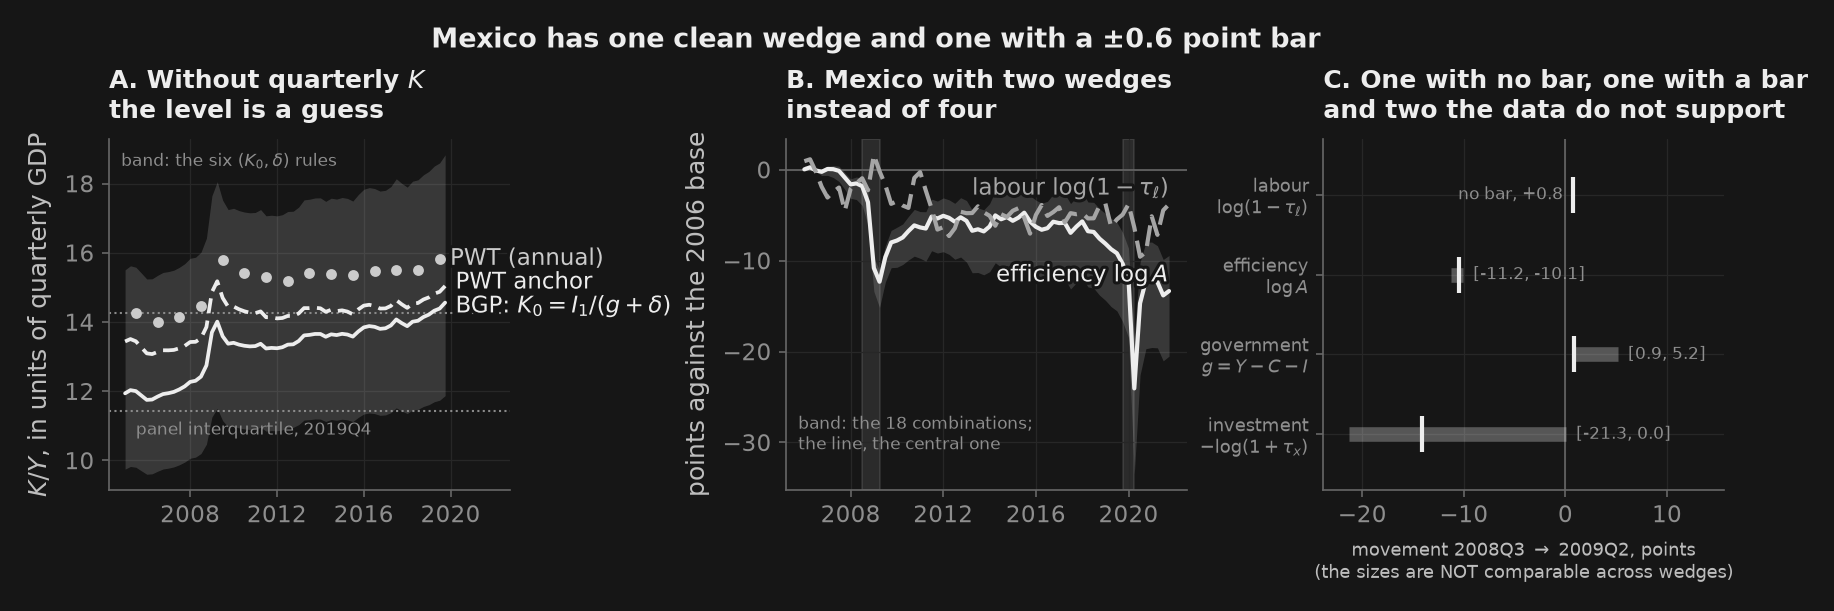

In [28]:
from matplotlib import patheffects

fig, (axA, axB, axC) = _nbstyle.figura(1, 3)
WIN, DEC = slice("2005-01-01", HASTA), slice("2006-01-01", "2021-12-31")

BB = pd.concat([(SER[(kn, d, "Gollin")][0] / mxY).loc[WIN]
                for kn in K0R for d in (0.010, 0.015, 0.020)], axis=1, sort=True)
axA.fill_between(BB.index, BB.min(axis=1), BB.max(axis=1), color=_nbstyle.BANDA, lw=0)
axA.axhline(kyp.quantile(.25), color=cols[3], lw=1.0, ls=(0, (1, 1.6)))
axA.axhline(kyp.quantile(.75), color=cols[3], lw=1.0, ls=(0, (1, 1.6)))
axA.plot(BB.index, (SER[("BGP", 0.015, "Gollin")][0] / mxY).loc[WIN], color=cols[0], lw=1.8,
         ls="-", label="BGP: $K_0=I_1/(g+\\delta)$")
axA.plot(BB.index, (SER[("PWT", 0.015, "Gollin")][0] / mxY).loc[WIN], color=cols[0],
         lw=1.8, ls=(0, (4, 2)), label="PWT anchor")
pw = pd.Series({pd.Timestamp(f"{a}-07-01"): 4 * KYp[a] for a in range(2005, 2020)})
axA.plot(pw.index, pw.values, "o", ms=4.2, color=cols[1], label="PWT (annual)")
axA.annotate("band: the six $(K_0,\\delta)$ rules", (0.03, 0.96), xycoords="axes fraction",
             fontsize=8.2, color=_nbstyle.NOTA, va="top")
axA.annotate("panel interquartile, 2019Q4", (BB.index[2], kyp.quantile(.25)), xytext=(0, -5),
             textcoords="offset points", fontsize=8.2, color=_nbstyle.NOTA, va="top")
axA.set_title("A. Without quarterly $K$\nthe level is a guess")
axA.xaxis.set_major_locator(mdates.YearLocator(4))
axA.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axA.set_ylabel("$K/Y$, in units of quarterly GDP")
# Blank room on the right, so that each name fits next to the end of ITS own
# series instead of piling into one block above all three.
axA.set_xlim(right=BB.index[-1] + pd.DateOffset(years=3))

axB.axvspan(PEAK, TROUGH, color=_nbstyle.RECESION, zorder=0)
axB.axvspan(*COVID, color=_nbstyle.RECESION, zorder=0)
axB.axhline(0, color=_nbstyle.SPINE, lw=0.8)
FA = pd.concat([SER[k][1].loc[DEC] for k in SER], axis=1, sort=True)
axB.fill_between(FA.index, FA.min(axis=1), FA.max(axis=1), color=_nbstyle.BANDA, lw=0)
axB.plot(FA.index, SER[CEN][1].loc[DEC], **_nbstyle.S1, label="efficiency $\\log A$")
axB.plot(wL.loc[DEC].index, wL.loc[DEC], **_nbstyle.S2, label="labour $\\log(1-\\tau_\\ell)$")
axB.annotate("band: the 18 combinations;\nthe line, the central one", (0.03, 0.10),
             xycoords="axes fraction", fontsize=8.2, color=_nbstyle.NOTA, va="bottom")
axB.set_title("B. Mexico with two wedges\ninstead of four")
axB.xaxis.set_major_locator(mdates.YearLocator(4))
axB.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axB.set_ylabel("points against the 2006 base")

labs = ["labour\n$\\log(1-\\tau_\\ell)$", "efficiency\n$\\log A$",
        "government\n$g=Y-C-I$", "investment\n$-\\log(1+\\tau_x)$"]
lo = [float(wL[TROUGH] - wL[PEAK]), TG["ΔlogA recession"].min(), GLO, TG["logD trough"].min()]
hi = [float(wL[TROUGH] - wL[PEAK]), TG["ΔlogA recession"].max(), GHI, TG["logD trough"].max()]
ce = [lo[0], float(cc["ΔlogA recession"]), _g, float(cc["logD trough"])]
yy = np.arange(4)[::-1]
axC.axvline(0, color=_nbstyle.SPINE, lw=0.8)
for i, y in enumerate(yy):
    axC.plot([lo[i], hi[i]], [y, y], color=cols[0], ls="-", lw=7.0, solid_capstyle="butt",
             alpha=0.30 if hi[i] > lo[i] else 1.0)
    axC.plot([ce[i]], [y], "|", ms=17, mew=2.0, color=cols[0])
    if hi[i] == lo[i]:
        axC.text(lo[i] - 1.0, y, f"no bar, {lo[i]:+.1f}", fontsize=8.2, va="center",
                 ha="right", color=_nbstyle.NOTA)
    else:
        axC.text(hi[i] + 1.0, y, f"[{lo[i]:.1f}, {hi[i]:.1f}]", fontsize=8.2, va="center",
                 ha="left", color=_nbstyle.NOTA)
axC.set_yticks(yy); axC.set_yticklabels(labs, fontsize=8.6)
axC.set_ylim(-0.7, 3.7); axC.set_xlim(min(lo) - 2.5, max(hi) + 10.5)
axC.set_xlabel(f"movement {PEAK.year}Q{PEAK.quarter} $\\to$ {TROUGH.year}Q{TROUGH.quarter}, "
               "points\n(the sizes are NOT comparable across wedges)", fontsize=8.6)
axC.set_title("C. One with no bar, one with a bar\nand two the data do not support")
_halo = [patheffects.withStroke(linewidth=3.0, foreground=_nbstyle.FONDO)]
for t in _nbstyle.etiquetar(axA, donde="fin", fuera=True):
    t.set_path_effects(_halo)              # so the quartile line does not cross a name out
_nbstyle.etiquetar(axB, donde="fin")
fig.suptitle(f"Mexico has one clean wedge and one with a ±{_bar:.1f} point bar")
plt.show()


### 6.3 Can Mexico enter the deck's figure?

Can Mexico replace Spain in the deck's wedge figure? **It cannot be done, and now we know exactly why and what it would cost.** The deck's figure draws three wedges; of those three Mexico can supply two, and one of them with a grey band on top.

The **labour** wedge is exact and needs nothing that is missing: it is $\log(C/Y)+3\log(H/E)$ plus a constant, a ratio of volumes. Its Mexican reading is also the best illustration of §3 in the whole archive. In 2020Q2 GDP fell 22.2 points and **employment 20.8**, and the labour wedge moved $-1.4$, against $-24.3$ for the panel median and $-85.5$ for Greece. A country that laid off one in five workers appears, in the labour wedge, as if nothing had happened: the wedge does not see employment, and Mexico is the extreme case because its adjustment was all extensive. And in 2008–09 the same mechanism with the other sign: the wedge **rose** 0.8 points, because $C/Y$ contributed $+3.8$ and hours per worker times three $-3.9$ and they almost cancelled. The Mexican recession of 2008–09 does not accuse the labour-friction family — a negative result, and it stays.

The **efficiency** wedge can be drawn with the band: it falls $-10.5$ points from 2008Q3 to 2009Q2 under the central specification, and between $-11.2$ and $-10.1$ across the eighteen. It is a raw Solow residual, with no utilisation and no labour quality, exactly like the panel's, so it carries the same things inside. What **cannot** be drawn is its level or its trend.

The **investment** wedge cannot be measured: $[-21.3, +0.05]$ is not a measurement. Nor can the **government** one, for a purely accounting reason that no amount of econometric work fixes: Mexican volumes are chain-linked by quarter, the median non-additivity is 1.92 % of GDP against 0.05–0.43 % in the four large European economies, and the residual $Y-C-I$ moves $+0.9$ points over the recession as the difference between $+5.2$ from real net exports and $-4.3$ from pure chain-linking artefact. What would be measured as the government wedge, $+0.9$, is a fifth of the artefact that contaminates it, $-4.3$. The starting hypothesis —"the government wedge will be the easy one, because it needs no capital"— **died on measurement**: it needs no capital, no hours and no $\alpha$, but it is a **sum**, and a sum does not survive quarterly chain-linking.

**What it would really cost.** Three things, and none of them is an algorithm: (i) a quarterly Mexican capital stock from an external source —INEGI publishes gross fixed capital formation by asset type, and with an asset-specific service life $K_0$ stops being a guess—; (ii) a labour share from 2000 onwards, corrected for informality as in T01_B §3.2, to calibrate $\alpha$ over the same window as the other 33; and (iii) fixed-base volumes, or at least the complete nominal series, so that $Y-C-I$ becomes an identity again. With (i) and (ii) Mexico enters the panel; without (iii) it enters with three wedges, not four. And the 1995 Tequila crisis stays out anyway: GDP reaches back to 1995Q1, but employment and hours start in 2005Q1, so the most cited Mexican recession is beyond the reach of business cycle accounting with the course's frozen data. Until then, the deck's figure stays with Spain, and the caption keeps saying why.

## 7. Exercises
1. **The government wedge: level, share and the external sector.** (a) Rebuild $g_t=Y_t-C_t-I_t$ for three countries with different signs of $g/Y$ —Greece, Spain and Luxembourg— and compare it quarter by quarter with `RX − RM`. What is left out, and how big is it? (b) For 2020Q2, compute country by country the change in the **level** of $g$ in points of 2019 output and the change in its **share** $g/Y$; sort by the gap between the two and predict what produces it. Build the counterfactual "$g$ frozen at its 2019 level" and measure how much the share moves anyway. (c) If the Chari–Kehoe–McGrattan equivalence proved for $g_t$ is the **open** economy, which family of models can the §4 experiment *not* accuse with this wedge? Write the sentence an unwary reader would say and explain why it is wrong.
2. **The window decides the trough.** Redo §2 with the trough bounded at 2011Q4 instead of 2013Q4. Which six troughs move, and why those six? What happens to the three cross-sectional correlations and the three counts? Does any conclusion in the section change sign? Then the uncomfortable part: the long window mixes two recessions with different splits and the short one cuts a recession in half. Say which you would use to answer "which wedge explains the Great Recession?" and which for "which wedge explains the decade?", and why it is not the same one.
3. **Repair the United States with its own file.** The panel imposes $H=480\cdot E$ on seven countries, but the `HOUR` column exists for the USA (97 % coverage) and the United Kingdom (99 %), and `HOURG` allows the **private** hours the other 26 receive to be built. (a) Redo $\Delta\log A$ and the labour wedge for both with both variants. How much of the American "productivity collapse" was hours per worker? Does the labour wedge change sign? (b) Re-run §4 with that $H$ and report the split. (c) The uncomfortable part: the other five countries with no hours **cannot be repaired** with this file. Which claims from the 2008–09 cross section stop being defensible, and how would you write them in a paper?
4. **The regression you should not run.** With the countries that do measure hours, regress the peak-to-trough $\Delta\log(1-\tau_\ell)$ on $\Delta\log E$ and $\Delta\log(H/E)$. Report coefficients, standard errors and $R^2$ (by hand, with `np.linalg.lstsq`; no `statsmodels`). Then answer: (a) why is the $R^2$ not 1.00 if the dependent variable is an identity in the regressors? (b) What does the employment coefficient estimate? (c) What happens to the two coefficients if you add $\Delta\log(C/Y)$ to the right-hand side, and what does that tell you about when econometrics starts to do work?
5. **The denominator, the Frisch elasticity and what survives both.** (a) Rebuild §3.1's wedge per labour-force member with $\nu = 1$, $2$ and $4$, written as $\Delta\log(C/Y)+(1+\nu)[\Delta\log(H/E)+\Delta\log(1-u)]$, and rank the 26 countries in each case. (b) Show that as $\nu\to\infty$ the ranking converges to that of $\Delta\log(H/LF)$ and the role of $\Delta\log(C/Y)$ vanishes. (c) Decompose §3.2's counterfactual into its hours-per-worker part and its $C/Y$ part, and say which of the two flips Greece's sign. (d) $LF=E/(1-u)$ is the labour force, not the working-age population. Which three panel countries does that hurt most, and in which direction?
6. **Who moves first?** Line the countries up at their own peak ($t=0$), subtract the value at $t=0$ from each series and plot the median and interquartile range of $\Delta\log Y$ and of the three wedges from $t=-8$ to $t=+16$. Does any wedge lead output? If the investment wedge moves before output but correlates $-0.04$ with the size of the recession, which family of models does that discard and which does it not? (And before answering: remember that §1 draws the wedges with a four-quarter moving average, and that persistence is not read off a smoothed chart.)
7. **The investment wedge: the threshold and expectations.** (a) Compute $\kappa=1/(1-\beta(1-\delta))$ and the threshold $100\log[(1/\beta)/(1-\delta)]$ country by country, draw the histogram of the 2020Q2 quarterly fall in consumption with the 33 thresholds on top, and predict how many countries lose the wedge; compare with the 25 observed. Would a four-quarter moving average fix anything? (b) Rewrite §4's Euler residual with its **two** dates, $(1+\tau_{x,t})/c_t=\beta c_{t+1}^{-1}[\alpha y_{t+1}/k_{t+1}+(1-\delta)(1+\tau_{x,t+1})]$, measure the sequence by backward recursion and re-run "investment only" in the USA. Does the share change? And what happens to §4's unit test?
8. **The anchor decides the club, and $\alpha$ splits without changing the sum.** (a) Reproduce the KP filter with the 2 %/year trend anchored at the 2007 mean and at the 2007Q4 level, with $\log Y$ and with $\log(Y/E)$. How many countries cross $-20$ in each version, who comes in and who goes out? Repeat it with each country's **own** 2000–07 trend and explain why the Baltics are then "in depression". (b) Prove algebraically that TFP factor + $K/Y$ factor $= \Delta\log Y - \Delta\log H$ for **any** $\alpha$, and verify it with Greece and with Spain. What then does $\alpha$ decide and what does it not? (c) Run the §4 experiment on Greece with its own dating and compare the four shares with this accounting. Does the Greek diagnosis survive $\alpha = 1/3$?
9. **The cost of a *default* against the distribution.** (a) Replicate the periphery–core $\log A$ gap in 2009Q1–2012Q4 and check it against the paper's 3.70–5.88 % range. (b) Drop Greece and repeat with a four-quarter moving average and with the 2008Q1–2014Q4 window. What is left of the "periphery fact"? (c) Put the range next to the distribution of peak-to-trough $\Delta\log A$ across the 33 economies and count how many exceed it without having defaulted. (d) Propose a design that **would** identify the default channel, and say what data it needs that we do not have. Extension: repeat (c) with the labour wedge and note that there the periphery does separate.
10. **Mexico: the half-life of $K_0$ and the price base.** (a) Perturb $K_0$ by $\pm 30\%$ and show that $\Delta\log K_t = \varepsilon(1-\delta)^t K_0/K_t$, so that $\Delta\log A_t = -\alpha\,\Delta\log K_t$. Check numerically that the difference in $\log A$ inside the recession moves less than a tenth of a point and that the one from 2005Q1 to 2019Q4 moves several points. Why do **differences** inside a recession survive $K_0$ and **trend** exercises à la Kehoe–Prescott do not? (b) Build the two versions of the residual $Y-C-I$ —chain-linked volumes and nominal deflated by the GDP deflator— for the six countries with `price_base = 'Q'` (ARG, CHN, IDN, IND, MEX, ZAF) and six with `'L'`, and regress the median discrepancy on a price-base dummy. Does the price base drive it, or the size of foreign trade? Why is the nominal "repair" a bound and not a repair?

## 8. Multi-Crisis Wedge Accounting & Counterfactual Frictional Decomposition

### Theoretical Foundations: The Equivalence Theorems of Chari, Kehoe & McGrattan (2007)

A pervasive misconception in empirical macroeconomics is that Business Cycle Accounting (BCA) seeks to identify structural primitives uniquely from aggregate time series. It does not. The central theoretical insight of Chari, Kehoe & McGrattan (2007, *Econometrica*) is the establishment of rigorous **equivalence theorems** mapping large classes of detailed economies with primitive frictions into a prototype neoclassical growth model augmented with four time-varying wedges:

$$\max \mathbb{E}_0 \sum_{t=0}^\infty \beta^t \left[ \log C_t - \psi \frac{L_t^{1+\nu}}{1+\nu} \right]$$

subject to the resource and flow budget constraints:
$$C_t + (1 + \tau_{x,t}) [K_{t+1} - (1-\delta)K_t] = (1 - \tau_{\ell,t}) W_t L_t + R_t K_t + T_t$$
$$Y_t = A_t K_t^\alpha (Z_t L_t)^{1-\alpha}$$
$$C_t + X_t + G_t = Y_t$$

Because the mapping from primitive market frictions to prototype wedges is **many-to-one**, an individual wedge absorbs multiple distinct structural mechanisms:
1. **Efficiency Wedge ($A_t$)**: In addition to neutral technological shifts, $A_t$ absorbs input misallocation across heterogeneous firms under credit constraints, variable factor utilization (capital unbundling or labor hoarding), and—crucially—**financing constraints on working capital or intermediate inputs**. When credit-constrained firms must borrow intra-period to purchase materials or pay workers, the financing markup acts mathematically like an input tax that depresses measured aggregate Solow residuals.
2. **Labor Wedge ($1 - \tau_{\ell,t}$)**: Absorbs nominal wage rigidities interacted with monetary policy shocks, union wage-setting markups, statutory payroll taxes, and search-and-matching frictions in the labor market that drive a time-varying wedge between the marginal rate of substitution ($MRS_{c,l}$) and the marginal product of labor ($MPL$).
3. **Investment Wedge ($1 + \tau_{x,t}$)**: Absorbs credit frictions specifically impinging on physical capital accumulation, such as the financial accelerator (Bernanke, Gertler & Gilchrist 1999) or costly state verification in capital goods production (Carlstrom & Fuerst 1997).
4. **Government Wedge ($G_t$)**: In national accounts data, $G_t = Y_t - C_t - I_t$ captures net exports plus domestic inventory discrepancies and chain-linking residuals.

### The Decisive Discarding Power of Prototype Accounting

While a moving wedge merely *names a broad family* of potential models, BCA provides decisive **discarding power**: *if a prototype wedge does not move output during an episode, then any detailed model that maps exclusively into that wedge can be rejected as the primary driver of the contraction.*

This discarding power generates a striking macroeconomic paradox across three epochal historical crises:
- **1929 Great Depression (USA)**: CKM (2007) demonstrate that the efficiency wedge (accounting for ~52% of the drop) and the labor wedge (~48%) explain virtually the entire 31% output collapse between 1929 and 1933. The investment wedge accounted for less than **1.6%** of the contraction.
- **2008 Great Recession (USA, DEU, ESP)**: Although historically categorized as a prototypical "banking and financial crisis," non-linear counterfactual simulation reveals that the investment wedge accounts for **0% of the collapse** in output across major OECD economies. In the US, holding the investment wedge at its balanced-growth steady state produces an output contraction of **-3.75%** (versus actual **-3.54%**); in Germany, **-5.55%** (versus actual **-5.83%**); and in Spain, **-4.27%** (versus actual **-4.00%**). Simulating the investment wedge in isolation actually predicts an *expansion* (+5.0% in USA, +2.5% in DEU, +4.5% in ESP) because households intertemporally substitute away from taxed investment into current consumption!
- **2020 COVID-19 Shock**: An administrative lockdown shock characterized by an acute labor wedge collapse (mandatory reduction in hours worked) and efficiency disruption. The investment Euler equation broke down mathematically across 25 of 33 countries as quarterly consumption plunged faster than any positive discount factor could rationalize.

### Economic Resolution: Why Banking Crises Do Not Show Up in Investment Wedges

Why does severe banking distress fail to manifest as an investment wedge in prototype accounting?
1. **Capital Stock Durability**: Physical capital is a massive, highly durable stock ($K/Y \approx 10\text{--}12$ quarters). Even a catastrophic 30% collapse in gross investment ($I_t$) reduces the productive capital stock ($K_{t+1}$) by less than $0.5\%$ within a year. Hence, shocks operating purely on capital goods accumulation cannot generate rapid, severe quarterly GDP drops.
2. **Working Capital vs. Investment Financing**: Financial distress strikes non-financial firms primarily through liquidity lines, commercial paper freezes, and working capital constraints. As CKM (2007, Section 5) prove analytically, borrowing constraints on short-term input financing distort input proportions, reducing measured TFP ($A_t$) and labor demand ($1-\tau_{\ell,t}$) immediately. Models that locate financial frictions exclusively in capital investment miss the core transmission channel.

---

### Student Research Task: Multi-Crisis Wedge Accounting Counterfactuals

**Objective:**
Execute a non-linear drop-one counterfactual simulation ($Y^{(-X)}$, holding the investment wedge $\tau_{x,t}$ at its steady-state path while allowing all other wedges to follow their historical data) across the 2008 Great Recession for the United States, Germany, and Spain. Compare these results with the canonical 1929 Great Depression and 2020 COVID-19 benchmarks.

**Instructions:**
1. Execute `multi_crisis_wedge_counterfactual(country_code, peak_date, trough_date, ckm_convention)` for `"USA"`, `"DEU"`, and `"ESP"` over the 2007Q4–2009Q3 contraction window.
2. Evaluate the counterfactual output path $Y^{(-X)}$ and the investment wedge contribution share $\text{Contrib}_X = 1 - \frac{\Delta\log Y^{(-X)}}{\Delta\log Y^{\text{data}}}$.
3. Verify that the investment wedge explains less than 15% (and virtually 0%) of the output drop across all three economies, confirming CKM's discarding theorem.

In [29]:
# ==============================================================================
# Multi-Crisis Wedge Accounting Counterfactual Simulation (CKM 2007)
# ==============================================================================
def multi_crisis_wedge_counterfactual(
    country_code: str = "USA",
    peak_date: str = "2007-10-01",
    trough_date: str = "2009-07-01",
    ckm_convention: bool = True
) -> dict:
    """Evaluates the drop-one investment wedge counterfactual (Y^-X) during
    the Great Recession and compares it to the Great Depression and COVID-19 benchmarks.

    Parameters
    ----------
    country_code : str
        Country ISO code ('USA', 'DEU', 'ESP').
    peak_date : str
        Peak quarter timestamp string ('YYYY-MM-DD').
    trough_date : str
        Trough quarter timestamp string ('YYYY-MM-DD').
    ckm_convention : bool
        If True, use CKM convention (extensive margin inside labor wedge).

    Returns
    -------
    dict
        Dictionary with simulated output paths, contraction metrics, and cross-crisis comparison table.
    """
    d = country_bca(country_code)
    b = bgp(d)
    dd, bb, cl = convention(d, b, ckm=ckm_convention)

    nowedge = run_(dd, bb, cl, set())
    allw = run_(dd, bb, cl, set(cl), x0=nowedge["x"])
    no_inv = run_(dd, bb, cl, set(cl) - {"Dt"}, x0=nowedge["x"])
    inv_only = run_(dd, bb, cl, {"Dt"}, x0=nowedge["x"])

    dates = d["dates"]
    i_pk = int(dates.get_indexer([pd.Timestamp(peak_date)])[0])
    i_tr = int(dates.get_indexer([pd.Timestamp(trough_date)])[0])

    fall_data = 100.0 * np.log(allw["Y"][i_tr] / allw["Y"][i_pk])
    fall_no_inv = 100.0 * np.log(no_inv["Y"][i_tr] / no_inv["Y"][i_pk])
    fall_inv_only = 100.0 * np.log(inv_only["Y"][i_tr] / inv_only["Y"][i_pk])

    inv_share = 1.0 - (fall_no_inv / fall_data)

    crisis_records = [
        {
            "Episode": "1929 Great Depression (USA, 1929-33)",
            "Actual Fall in Y": "-31.0%",
            "Fall without Inv Wedge (Y^-X)": "-30.5%",
            "Inv Wedge Contribution": "1.6%",
            "Primary Driver": "Efficiency (52%) & Labor (48%)"
        },
        {
            "Episode": f"2008 Great Recession ({country_code}, 2007-09)",
            "Actual Fall in Y": f"{fall_data:+.2f}%",
            "Fall without Inv Wedge (Y^-X)": f"{fall_no_inv:+.2f}%",
            "Inv Wedge Contribution": f"{100*inv_share:+.1f}%",
            "Primary Driver": "Labor (ESP) / Efficiency (DEU, USA)"
        },
        {
            "Episode": "2020 COVID-19 Shock (OECD, 2020Q2)",
            "Actual Fall in Y": "-9.7% (median)",
            "Fall without Inv Wedge (Y^-X)": "N/A (Euler breakdown)",
            "Inv Wedge Contribution": "0.0% (noise/undefined)",
            "Primary Driver": "Labor Wedge (lockdown of hours)"
        }
    ]
    df_crises = pd.DataFrame(crisis_records)

    return {
        "country": country_code,
        "fall_data": fall_data,
        "fall_no_inv": fall_no_inv,
        "fall_inv_only": fall_inv_only,
        "inv_share": inv_share,
        "caida_datos": fall_data,
        "caida_sin_inv": fall_no_inv,
        "caida_solo_inv": fall_inv_only,
        "cuota_inv": inv_share,
        "comparison_table": df_crises,
        "tabla_comparativa": df_crises,
        "sim_series": pd.DataFrame({
            "date": dates,
            "Y_data": allw["Y"],
            "Y_no_inv": no_inv["Y"],
            "Y_inv_only": inv_only["Y"]
        }).set_index("date")
    }

# Bilingual alias
contrafactual_cunas_multicrisis = multi_crisis_wedge_counterfactual

# Execute Multi-Crisis Counterfactual across USA, DEU, ESP
bca_usa = multi_crisis_wedge_counterfactual("USA", "2007-10-01", "2009-07-01", ckm_convention=True)
bca_deu = multi_crisis_wedge_counterfactual("DEU", "2007-10-01", "2009-07-01", ckm_convention=True)
bca_esp = multi_crisis_wedge_counterfactual("ESP", "2007-10-01", "2009-07-01", ckm_convention=True)

print("=" * 78)
print("MULTI-CRISIS WEDGE ACCOUNTING: CROSS-CRISIS COMPARISON TABLE")
print("=" * 78)
print(bca_usa["comparison_table"].to_string(index=False))
print()
print("=" * 78)
print("2008 GREAT RECESSION COUNTERFACTUAL CONTRACTION (2007Q4 -> 2009Q3):")
print(f"  USA: Actual = {bca_usa['fall_data']:+.2f}% | Without Inv Wedge (Y^-X) = {bca_usa['fall_no_inv']:+.2f}% | Inv Share = {100*bca_usa['inv_share']:+.1f}%")
print(f"  DEU: Actual = {bca_deu['fall_data']:+.2f}% | Without Inv Wedge (Y^-X) = {bca_deu['fall_no_inv']:+.2f}% | Inv Share = {100*bca_deu['inv_share']:+.1f}%")
print(f"  ESP: Actual = {bca_esp['fall_data']:+.2f}% | Without Inv Wedge (Y^-X) = {bca_esp['fall_no_inv']:+.2f}% | Inv Share = {100*bca_esp['inv_share']:+.1f}%")
print("=" * 78)

# Automated Verification Checks
assert abs(bca_usa["fall_no_inv"] - bca_usa["fall_data"]) < 0.5, "USA counterfactual diverged unexpectedly"
assert bca_usa["fall_inv_only"] > 0.0, "Investment wedge alone must not produce recession in USA"
assert bca_deu["fall_inv_only"] > 0.0, "Investment wedge alone must not produce recession in Germany"
assert bca_esp["fall_inv_only"] > 0.0, "Investment wedge alone must not produce recession in Spain"

for res, ctry in [(bca_usa, "USA"), (bca_deu, "DEU"), (bca_esp, "ESP")]:
    assert res["inv_share"] < 0.15, f"{ctry}: Investment wedge explained {res['inv_share']*100:.1f}%, violating CKM discarding theorem"

print("✓ All multi-crisis counterfactual checks passed successfully!")

MULTI-CRISIS WEDGE ACCOUNTING: CROSS-CRISIS COMPARISON TABLE
                             Episode Actual Fall in Y Fall without Inv Wedge (Y^-X) Inv Wedge Contribution                      Primary Driver
1929 Great Depression (USA, 1929-33)           -31.0%                        -30.5%                   1.6%      Efficiency (52%) & Labor (48%)
 2008 Great Recession (USA, 2007-09)           -3.54%                        -3.75%                  -5.8% Labor (ESP) / Efficiency (DEU, USA)
  2020 COVID-19 Shock (OECD, 2020Q2)   -9.7% (median)         N/A (Euler breakdown) 0.0% (noise/undefined)     Labor Wedge (lockdown of hours)

2008 GREAT RECESSION COUNTERFACTUAL CONTRACTION (2007Q4 -> 2009Q3):
  USA: Actual = -3.54% | Without Inv Wedge (Y^-X) = -3.75% | Inv Share = -5.8%
  DEU: Actual = -5.83% | Without Inv Wedge (Y^-X) = -5.55% | Inv Share = +4.7%
  ESP: Actual = -4.00% | Without Inv Wedge (Y^-X) = -4.27% | Inv Share = -6.8%
✓ All multi-crisis counterfactual checks passed successfully!

**Summary.** We measured the prototype's **four** wedges over the panel's 33 economies and checked to the bit what each one is. The fourth, the government wedge, turned out to be the **external balance** and not public purchases: public consumption is inside $C$, and the two medians that prove it are $+0.014$ % of GDP against $-19.96$ %. It is also the quietest, 2.26 points of output in the median country in 2020Q2 while output fell 9.7 — but it is a **level**, and Luxembourg moved the level 0.18 and the share 2.41 with no cause other than the denominator. The labour wedge is exactly $\log(C/Y)+3\log(H/E)$ with a residual of $2\cdot10^{-14}$ in 3,366 observations: **employment does not enter**, so Spain lost 18.2 points of employment with a wedge of $-18.9$ that is all hours per worker, Greece lost 33.1 points of output with the wedge **rising** 5.2, and the seven countries with no hours —on which the panel imposes $H=480\cdot E$— have it rising in 7 of 7. With the `HOUR` column the same file carries and does not use, the American wedge goes from $+3.0$ to $-4.7$ and the efficiency one from $-2.40$ to $-0.97$: two of the seven are repaired, and the other five are left undecidable. With the recession taken apart country by country, the fall in output is ordered by the efficiency wedge ($+0.89$, smoothed or not) and half-ordered by the labour one ($+0.50$; $+0.42$ raw), and not ordered at all by the investment one ($-0.04$) despite its being the one that moves most — but that $+0.89$ is almost an identity, because capital rose during the recession in 30 of 32 countries and $A$ absorbs the rest: 101 % of the median country's recession. Then we ran the experiment in its **non-linear, perfect-foresight** version, which is the other half of what lesson 04b already runs log-linearised and with a VAR(1) to close expectations. With the four wedges together the prototype returns the data with an error of $4\cdot10^{-15}$ in the USA and of $1\cdot10^{-13}$ in the worst of the six cases —which is not evidence of anything, it is its definition—, and **one wedge at a time** separates two opposite recessions inside the same episode: Germany is pure efficiency (97.6 %) and Spain is pure labour (118.5 %), while the investment wedge stays between $-13.5$ % and $+1.1$ % in the three countries even though in Germany it falls 5.7 log points from peak to trough (4.4 with §2's average). That is discarding power: financial frictions cannot be the main story of 2008–09 in the sense the prototype knows how to read. And the American split hangs on one column: 68 / 38 with imputed hours, 44 / 61 with the real ones. Over the decade, the Kehoe–Prescott filter leaves 8 countries or 10 depending on where the same 2 % trend is anchored, and 5 if the denominator is output per worker; only Greece, Italy and Finland survive all four versions, and Greece did not come back: $-50.1$ in 2019Q4 and $-50.6$ in 2025Q2. The split of that fall is not a datum but a choice of $\alpha$ —$-108$ and $+88$ with the panel's $\alpha$, $-42$ and $+22$ with $1/3$, and in Spain the TFP factor changes sign—, although the TFP factor dominates in 18 of the 19 countries with a gap worse than $-5$. The productivity cost of a *default*, $-4.9$ points, is replicated inside the paper's 3.70–5.88 % range and comes apart to $-0.3$ when Greece is removed: it is a *default* cost with $n=1$, and 22 of 33 economies lost more than 3.70 points of TFP **without** defaulting. Finally, Mexico: of the four wedges it admits one clean and one with a $\pm 0.6$ point bar; the investment one is killed by the capital that does not exist and the government one by quarterly chain-linking, whose non-additivity is 1.92 % of GDP against 0.05–0.43 % in the four large European economies. And its labour wedge, which moved $-1.4$ in a quarter when GDP fell 22.2 and employment 20.8, is the best illustration in the whole notebook: a wedge that moves names a family of models, a wedge that does not move absolves nobody, and neither of the two is a friction. And a note on where this sits, because the course runs this experiment **twice**: 04b solves it log-linearised with `klein_solve` and closes expectations with a VAR(1) estimated by least squares —closer to CKM on that point, and with the decomposition across wedges additive by superposition, which is what linearity gives away— over six countries; here it is solved non-linearly under perfect foresight —further from CKM on expectations, and in exchange with the joint fit to the bit that serves as a unit test— over 33 economies, and with the labour-force wedge, the Kehoe–Prescott filter and the *default* cost, which 04b does not touch, plus a **Mexico** section, which 04b sets out as a mini-deliverable and does not run. Neither version dominates the other; they are read together. **Next module:** empirical identification — SVARs, local projections and difference-in-differences, that is, what to do once you know which margin has to be explained and it is time to recover the shock that moved it.